In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
# ============================================================
# CELL 1 — ENVIRONMENT & IMPORTS
# ============================================================

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# PyTorch
# ------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Torchvision
# ------------------------------------------------------------
import torchvision
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
    resnet50,
    ResNet50_Weights,
    densenet121,
    DenseNet121_Weights,
    convnext_tiny,
    ConvNeXt_Tiny_Weights,
    vit_b_16,
    ViT_B_16_Weights
)

# ------------------------------------------------------------
# Scikit-learn
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Other utilities
# ------------------------------------------------------------
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
import copy
import math

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("CELL 1 — ENVIRONMENT CHECK")
print("=" * 70)

print(f"PyTorch version : {torch.__version__}")
print(f"Torchvision     : {torchvision.__version__}")
print(f"Device          : {device}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(
        f"GPU memory      : "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )
else:
    print("GPU             : Not available")

print("=" * 70)
print("✓ CELL 1 COMPLETED")
print("=" * 70)

CELL 1 — ENVIRONMENT CHECK
PyTorch version : 2.11.0+cu126
Torchvision     : 0.26.0+cu126
Device          : cuda
GPU             : NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory      : 4.00 GB
✓ CELL 1 COMPLETED


In [3]:
# ============================================================
# CELL 2 — REPRODUCIBILITY & CONFIGURATION
# ============================================================

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# CUDA settings
# ------------------------------------------------------------

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# ------------------------------------------------------------
# Project configuration
# ------------------------------------------------------------

IMAGE_SIZE = 224

# RTX 3050 4 GB
BATCH_SIZE = 8

NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

NUM_CLASSES = 5

CLASS_NAMES = [
    "CelebA-HQ",
    "Stable Diffusion",
    "GLIDE",
    "BigGAN",
    "DDPM"
]

CLASS_TO_IDX = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

IDX_TO_CLASS = {
    idx: name
    for name, idx in CLASS_TO_IDX.items()
}

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

NUM_EPOCHS = 20

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# Early stopping
EARLY_STOPPING_PATIENCE = 5

# ------------------------------------------------------------
# FFT configuration
# ------------------------------------------------------------

FFT_SIZE = IMAGE_SIZE * IMAGE_SIZE

# PCA components
# We start conservatively because you have a 4 GB GPU.
PCA_COMPONENTS = 512

print("=" * 70)
print("CELL 2 — CONFIGURATION")
print("=" * 70)

print(f"Seed              : {SEED}")
print(f"Image size        : {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Number of classes : {NUM_CLASSES}")
print(f"Epochs            : {NUM_EPOCHS}")
print(f"Learning rate     : {LEARNING_RATE}")
print(f"Weight decay      : {WEIGHT_DECAY}")
print(f"FFT dimensions    : {FFT_SIZE}")
print(f"PCA components    : {PCA_COMPONENTS}")
print(f"Device            : {device}")

print("\nClasses:")
for idx, name in IDX_TO_CLASS.items():
    print(f"  {idx} → {name}")

print("\n✓ CELL 2 COMPLETED")

CELL 2 — CONFIGURATION
Seed              : 42
Image size        : 224 × 224
Batch size        : 8
Number of classes : 5
Epochs            : 20
Learning rate     : 0.0001
Weight decay      : 0.0001
FFT dimensions    : 50176
PCA components    : 512
Device            : cuda

Classes:
  0 → CelebA-HQ
  1 → Stable Diffusion
  2 → GLIDE
  3 → BigGAN
  4 → DDPM

✓ CELL 2 COMPLETED


In [8]:
# ============================================================
# CELL 3 — ARTIFACT DATASET PATH
# ============================================================

DATASET_ROOT = r"D:\aiub note\11th sem\COMPUTER VISION AND PATTERN RECOGNITION\ArtiFact"

print("=" * 70)
print("CELL 3 — CHECKING ARTIFACT DATASET")
print("=" * 70)

print("Dataset path:")
print(DATASET_ROOT)

if not os.path.isdir(DATASET_ROOT):
    raise FileNotFoundError(
        f"\n❌ Dataset folder not found:\n{DATASET_ROOT}"
    )

REQUIRED_CLASSES = [
    "celebahq",
    "stable_diffusion",
    "glide",
    "big_gan",
    "ddpm"
]

for class_name in REQUIRED_CLASSES:

    class_path = os.path.join(DATASET_ROOT, class_name)

    if not os.path.isdir(class_path):
        raise FileNotFoundError(
            f"\n❌ Required class folder not found:\n{class_path}"
        )

    print(f"✓ {class_name:20s}: {class_path}")

print("\n✓ ALL FIVE CLASS FOLDERS FOUND")
print("=" * 70)
print("✓ CELL 3 COMPLETED")
print("=" * 70)

CELL 3 — CHECKING ARTIFACT DATASET
Dataset path:
D:\aiub note\11th sem\COMPUTER VISION AND PATTERN RECOGNITION\ArtiFact
✓ celebahq            : D:\aiub note\11th sem\COMPUTER VISION AND PATTERN RECOGNITION\ArtiFact\celebahq
✓ stable_diffusion    : D:\aiub note\11th sem\COMPUTER VISION AND PATTERN RECOGNITION\ArtiFact\stable_diffusion
✓ glide               : D:\aiub note\11th sem\COMPUTER VISION AND PATTERN RECOGNITION\ArtiFact\glide
✓ big_gan             : D:\aiub note\11th sem\COMPUTER VISION AND PATTERN RECOGNITION\ArtiFact\big_gan
✓ ddpm                : D:\aiub note\11th sem\COMPUTER VISION AND PATTERN RECOGNITION\ArtiFact\ddpm

✓ ALL FIVE CLASS FOLDERS FOUND
✓ CELL 3 COMPLETED


In [9]:
# ============================================================
# CELL 4 — SCAN ARTIFACT IMAGES
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

CLASS_FOLDER_MAP = {
    "celebahq": 0,
    "stable_diffusion": 1,
    "glide": 2,
    "big_gan": 3,
    "ddpm": 4
}

CLASS_DISPLAY_NAMES = {
    0: "CelebA-HQ",
    1: "Stable Diffusion",
    2: "GLIDE",
    3: "BigGAN",
    4: "DDPM"
}

records = []

print("=" * 70)
print("CELL 4 — SCANNING IMAGES")
print("=" * 70)

for folder_name, label in CLASS_FOLDER_MAP.items():

    class_path = os.path.join(
        DATASET_ROOT,
        folder_name
    )

    count = 0

    for root, _, files in os.walk(class_path):

        for filename in files:

            if Path(filename).suffix.lower() in IMAGE_EXTENSIONS:

                records.append({
                    "path": os.path.join(root, filename),
                    "class_name": CLASS_DISPLAY_NAMES[label],
                    "label": label
                })

                count += 1

    print(
        f"{CLASS_DISPLAY_NAMES[label]:20s}: {count:,}"
    )

if len(records) == 0:
    raise RuntimeError("❌ No images found.")

df = pd.DataFrame(records)

# Deterministic ordering
df = df.sort_values(
    ["label", "path"]
).reset_index(drop=True)

print("\nTotal images:", f"{len(df):,}")

print("\nClass distribution:")
print(
    df["class_name"].value_counts()
    .reindex(CLASS_DISPLAY_NAMES.values())
)

# Verify paths
missing = [
    p for p in df["path"]
    if not os.path.isfile(p)
]

if missing:
    raise FileNotFoundError(
        f"{len(missing)} image files could not be found."
    )

print("\n✓ All image paths verified")
print("✓ CELL 4 COMPLETED")
print("=" * 70)

CELL 4 — SCANNING IMAGES
CelebA-HQ           : 17,609
Stable Diffusion    : 19,669
GLIDE               : 14,539
BigGAN              : 10,000
DDPM                : 896

Total images: 62,713

Class distribution:
class_name
CelebA-HQ           17609
Stable Diffusion    19669
GLIDE               14539
BigGAN              10000
DDPM                  896
Name: count, dtype: int64

✓ All image paths verified
✓ CELL 4 COMPLETED


In [10]:
# ============================================================
# CELL 5 — STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print("=" * 70)
print("CELL 5 — 70/15/15 STRATIFIED SPLIT")
print("=" * 70)

# ------------------------------------------------------------
# First: 70% train + 30% temporary
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

# ------------------------------------------------------------
# Second: split temporary 50/50
# → 15% validation
# → 15% test
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

# ------------------------------------------------------------
# Reset indexes
# ------------------------------------------------------------

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# Print sizes
# ------------------------------------------------------------

print("Total:", len(df))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nPercentages:")

print(
    f"Train      : {len(train_df)/len(df)*100:.2f}%"
)

print(
    f"Validation : {len(val_df)/len(df)*100:.2f}%"
)

print(
    f"Test       : {len(test_df)/len(df)*100:.2f}%"
)

# ------------------------------------------------------------
# Verify class distributions
# ------------------------------------------------------------

print("\nTRAIN distribution:")
print(
    train_df["class_name"]
    .value_counts()
    .reindex(CLASS_DISPLAY_NAMES.values())
)

print("\nVALIDATION distribution:")
print(
    val_df["class_name"]
    .value_counts()
    .reindex(CLASS_DISPLAY_NAMES.values())
)

print("\nTEST distribution:")
print(
    test_df["class_name"]
    .value_counts()
    .reindex(CLASS_DISPLAY_NAMES.values())
)

# ------------------------------------------------------------
# Verify no path overlap
# ------------------------------------------------------------

train_paths = set(train_df["path"])
val_paths = set(val_df["path"])
test_paths = set(test_df["path"])

assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)

print("\n✓ No image overlap between train/validation/test")

print("\n✓ CELL 5 COMPLETED")
print("=" * 70)

CELL 5 — 70/15/15 STRATIFIED SPLIT
Total: 62713
Train: 43899
Validation: 9407
Test: 9407

Percentages:
Train      : 70.00%
Validation : 15.00%
Test       : 15.00%

TRAIN distribution:
class_name
CelebA-HQ           12326
Stable Diffusion    13768
GLIDE               10178
BigGAN               7000
DDPM                  627
Name: count, dtype: int64

VALIDATION distribution:
class_name
CelebA-HQ           2641
Stable Diffusion    2951
GLIDE               2180
BigGAN              1500
DDPM                 135
Name: count, dtype: int64

TEST distribution:
class_name
CelebA-HQ           2642
Stable Diffusion    2950
GLIDE               2181
BigGAN              1500
DDPM                 134
Name: count, dtype: int64

✓ No image overlap between train/validation/test

✓ CELL 5 COMPLETED


In [18]:
# ============================================================
# CELL 6 — CONTROLLED BALANCED TRAINING SET
# ============================================================

print("=" * 70)
print("CELL 6 — CONTROLLED BALANCED TRAINING SET")
print("=" * 70)

TARGET_COUNT = 2000

balanced_parts = []

for label in range(NUM_CLASSES):

    class_data = train_df[
        train_df["label"] == label
    ].copy()

    original_count = len(class_data)

    print(
        f"{CLASS_DISPLAY_NAMES[label]:20s} "
        f"original = {original_count:,}"
    )

    if original_count < TARGET_COUNT:

        # Oversample only enough to reach 2,000.
        sampled = class_data.sample(
            n=TARGET_COUNT,
            replace=True,
            random_state=SEED
        )

    else:

        # Randomly select exactly 2,000.
        sampled = class_data.sample(
            n=TARGET_COUNT,
            replace=False,
            random_state=SEED
        )

    balanced_parts.append(
        sampled
    )

# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

balanced_train_df = pd.concat(
    balanced_parts,
    ignore_index=True
)

# ------------------------------------------------------------
# Shuffle ONCE
# ------------------------------------------------------------

balanced_train_df = balanced_train_df.sample(
    frac=1.0,
    random_state=SEED
).reset_index(drop=True)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BALANCED TRAINING DISTRIBUTION")
print("=" * 70)

counts = (
    balanced_train_df["label"]
    .value_counts()
    .sort_index()
)

for label, count in counts.items():

    print(
        f"{label} | "
        f"{CLASS_DISPLAY_NAMES[label]:20s} | "
        f"{count:,}"
    )

print(
    "\nTotal balanced training images:",
    len(balanced_train_df)
)

# ------------------------------------------------------------
# Validation/test remain untouched
# ------------------------------------------------------------

print(
    "\nValidation images:",
    len(val_df)
)

print(
    "Test images      :",
    len(test_df)
)

print("\n✓ Training set balanced to 2,000/class")
print("✓ Validation unchanged")
print("✓ Test unchanged")
print("✓ CELL 6 COMPLETED")
print("=" * 70)

CELL 6 — CONTROLLED BALANCED TRAINING SET
CelebA-HQ            original = 12,326
Stable Diffusion     original = 13,768
GLIDE                original = 10,178
BigGAN               original = 7,000
DDPM                 original = 627

BALANCED TRAINING DISTRIBUTION
0 | CelebA-HQ            | 2,000
1 | Stable Diffusion     | 2,000
2 | GLIDE                | 2,000
3 | BigGAN               | 2,000
4 | DDPM                 | 2,000

Total balanced training images: 10000

Validation images: 9407
Test images      : 9407

✓ Training set balanced to 2,000/class
✓ Validation unchanged
✓ Test unchanged
✓ CELL 6 COMPLETED


In [19]:
# ============================================================
# CELL 7 — DATASET CLASS + DETERMINISTIC LOADERS
# ============================================================

print("=" * 70)
print("CELL 7 — DATASET & EXTRACTION LOADERS")
print("=" * 70)

# ------------------------------------------------------------
# Evaluation transform
# ------------------------------------------------------------

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class ImageDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["path"]
        label = int(row["label"])

        try:
            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as e:

            raise RuntimeError(
                f"Could not read image:\n"
                f"{image_path}\n\n"
                f"Error: {e}"
            )

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# ------------------------------------------------------------
# Create deterministic extraction datasets
# ------------------------------------------------------------

train_extract_dataset = ImageDataset(
    balanced_train_df,
    transform=eval_transform
)

val_extract_dataset = ImageDataset(
    val_df,
    transform=eval_transform
)

test_extract_dataset = ImageDataset(
    test_df,
    transform=eval_transform
)

# ------------------------------------------------------------
# IMPORTANT:
# shuffle=False for ALL extraction loaders
# ------------------------------------------------------------

train_extract_loader = DataLoader(
    train_extract_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_extract_loader = DataLoader(
    val_extract_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_extract_loader = DataLoader(
    test_extract_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("Training extraction samples   :", len(train_extract_dataset))
print("Validation extraction samples :", len(val_extract_dataset))
print("Test extraction samples       :", len(test_extract_dataset))

print("\nLoader configuration:")

print(
    "Train extraction shuffle : False"
)

print(
    "Validation extraction shuffle : False"
)

print(
    "Test extraction shuffle : False"
)

# ------------------------------------------------------------
# Test one batch
# ------------------------------------------------------------

images, labels = next(
    iter(train_extract_loader)
)

print("\nTest batch:")
print("Images :", images.shape)
print("Labels :", labels.shape)

print("\n✓ Deterministic extraction loaders created")
print("✓ RGB/FFT feature alignment will use this fixed order")
print("✓ CELL 7 COMPLETED")
print("=" * 70)

CELL 7 — DATASET & EXTRACTION LOADERS
Training extraction samples   : 10000
Validation extraction samples : 9407
Test extraction samples       : 9407

Loader configuration:
Train extraction shuffle : False
Validation extraction shuffle : False
Test extraction shuffle : False

Test batch:
Images : torch.Size([8, 3, 224, 224])
Labels : torch.Size([8])

✓ Deterministic extraction loaders created
✓ RGB/FFT feature alignment will use this fixed order
✓ CELL 7 COMPLETED


In [20]:
# ============================================================
# CELL 8 — FFT FEATURE EXTRACTION FUNCTION
# ============================================================

print("=" * 70)
print("CELL 8 — DEFINING FFT EXTRACTION")
print("=" * 70)


def extract_fft_features(loader):
    """
    Extract FFT log-magnitude features.

    Pipeline:
        RGB image
          ↓
        grayscale
          ↓
        2D FFT
          ↓
        FFT shift
          ↓
        magnitude
          ↓
        log(1 + magnitude)

    IMPORTANT:
    The loader must use shuffle=False.
    """

    all_features = []
    all_labels = []

    with torch.no_grad():

        for images, labels in tqdm(
            loader,
            desc="Extracting FFT"
        ):

            # ------------------------------------------------
            # Move images to CPU
            # ------------------------------------------------
            images = images.cpu()

            # ------------------------------------------------
            # Undo ImageNet normalization
            # ------------------------------------------------
            mean = torch.tensor(
                [0.485, 0.456, 0.406]
            ).view(1, 3, 1, 1)

            std = torch.tensor(
                [0.229, 0.224, 0.225]
            ).view(1, 3, 1, 1)

            images = images * std + mean

            images = torch.clamp(
                images,
                0.0,
                1.0
            )

            # ------------------------------------------------
            # Convert RGB → grayscale
            # ------------------------------------------------
            grayscale = (
                0.299 * images[:, 0]
                + 0.587 * images[:, 1]
                + 0.114 * images[:, 2]
            )

            # ------------------------------------------------
            # 2D FFT
            # ------------------------------------------------
            fft = torch.fft.fft2(
                grayscale
            )

            # ------------------------------------------------
            # FFT shift
            # ------------------------------------------------
            fft_shifted = torch.fft.fftshift(
                fft,
                dim=(-2, -1)
            )

            # ------------------------------------------------
            # Magnitude
            # ------------------------------------------------
            magnitude = torch.abs(
                fft_shifted
            )

            # ------------------------------------------------
            # Log magnitude
            # ------------------------------------------------
            log_magnitude = torch.log1p(
                magnitude
            )

            # ------------------------------------------------
            # Flatten
            # ------------------------------------------------
            features = log_magnitude.reshape(
                log_magnitude.shape[0],
                -1
            )

            all_features.append(
                features.numpy().astype(
                    np.float32
                )
            )

            all_labels.append(
                labels.numpy()
            )

    features = np.concatenate(
        all_features,
        axis=0
    )

    labels = np.concatenate(
        all_labels,
        axis=0
    )

    return features, labels


print("✓ FFT extraction function defined")
print("✓ Pipeline: FFT → shift → log magnitude")
print("✓ CELL 8 COMPLETED")
print("=" * 70)

CELL 8 — DEFINING FFT EXTRACTION
✓ FFT extraction function defined
✓ Pipeline: FFT → shift → log magnitude
✓ CELL 8 COMPLETED


In [21]:
# ============================================================
# CELL 9 — MEMORY-SAFE INCREMENTAL FFT PCA
# ============================================================

from sklearn.decomposition import IncrementalPCA

print("=" * 70)
print("CELL 9 — MEMORY-SAFE FFT + INCREMENTAL PCA")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

FFT_DIM = IMAGE_SIZE * IMAGE_SIZE

PCA_COMPONENTS_SAFE = min(
    PCA_COMPONENTS,
    128
)

PCA_ACCUMULATE_SAMPLES = 256

print("Raw FFT dimensions       :", FFT_DIM)
print("PCA components           :", PCA_COMPONENTS_SAFE)
print("PCA accumulation samples :", PCA_ACCUMULATE_SAMPLES)

# ------------------------------------------------------------
# Create Incremental PCA
# ------------------------------------------------------------

fft_ipca = IncrementalPCA(
    n_components=PCA_COMPONENTS_SAFE,
    batch_size=PCA_ACCUMULATE_SAMPLES
)

# ------------------------------------------------------------
# Accumulate several DataLoader batches
# before calling partial_fit()
# ------------------------------------------------------------

feature_buffer = []
label_buffer = []

train_seen = 0
pca_updates = 0

print("\nFitting PCA on TRAINING data only...\n")

for batch_features, batch_labels in tqdm(
    fft_batch_generator(train_extract_loader),
    desc="Fitting PCA"
):

    feature_buffer.append(batch_features)
    label_buffer.append(batch_labels)

    current_samples = sum(
        len(x) for x in feature_buffer
    )

    # --------------------------------------------------------
    # Only call partial_fit when enough samples are collected
    # --------------------------------------------------------

    if current_samples >= PCA_ACCUMULATE_SAMPLES:

        X_batch = np.concatenate(
            feature_buffer,
            axis=0
        )

        # ----------------------------------------------------
        # Keep only a safe number of samples
        # ----------------------------------------------------

        X_fit = X_batch[
            :PCA_ACCUMULATE_SAMPLES
        ]

        fft_ipca.partial_fit(
            X_fit
        )

        train_seen += len(X_fit)
        pca_updates += 1

        # ----------------------------------------------------
        # Clear buffer
        # ----------------------------------------------------

        feature_buffer = []
        label_buffer = []

# ------------------------------------------------------------
# Process remaining samples only if enough for PCA
# ------------------------------------------------------------

if len(feature_buffer) > 0:

    X_remaining = np.concatenate(
        feature_buffer,
        axis=0
    )

    if len(X_remaining) >= PCA_COMPONENTS_SAFE:

        fft_ipca.partial_fit(
            X_remaining
        )

        train_seen += len(X_remaining)

        pca_updates += 1

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INCREMENTAL PCA COMPLETED")
print("=" * 70)

print(
    "PCA updates performed:",
    pca_updates
)

print(
    "Samples used for PCA:",
    train_seen
)

print(
    "Components:",
    fft_ipca.n_components_
)

print(
    "Explained variance:",
    f"{fft_ipca.explained_variance_ratio_.sum() * 100:.2f}%"
)

print("\n✓ PCA was fitted using TRAINING data only")
print("✓ No giant FFT matrix was stored")
print("✓ First PCA batch contains enough samples")
print("✓ CELL 9 COMPLETED")
print("=" * 70)

CELL 9 — MEMORY-SAFE FFT + INCREMENTAL PCA
Raw FFT dimensions       : 50176
PCA components           : 128
PCA accumulation samples : 256

Fitting PCA on TRAINING data only...



Fitting PCA: 0it [00:00, ?it/s]


INCREMENTAL PCA COMPLETED
PCA updates performed: 39
Samples used for PCA: 9984
Components: 128
Explained variance: 58.68%

✓ PCA was fitted using TRAINING data only
✓ No giant FFT matrix was stored
✓ First PCA batch contains enough samples
✓ CELL 9 COMPLETED


In [22]:
# ============================================================
# CELL 10 — TRANSFORM ALL TRAIN / VAL / TEST FFT FEATURES
# ============================================================

print("=" * 70)
print("CELL 10 — TRANSFORMING FFT FEATURES")
print("=" * 70)


def transform_fft_features(loader, pca_model):

    all_features = []
    all_labels = []

    for batch_features, batch_labels in tqdm(
        fft_batch_generator(loader),
        desc="Transforming FFT"
    ):

        reduced = pca_model.transform(
            batch_features
        )

        all_features.append(
            reduced.astype(np.float32)
        )

        all_labels.append(
            batch_labels
        )

    features = np.concatenate(
        all_features,
        axis=0
    )

    labels = np.concatenate(
        all_labels,
        axis=0
    )

    return features, labels


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

fft_train_pca = transform_fft_features(
    train_extract_loader,
    fft_ipca
)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

fft_val_pca = transform_fft_features(
    val_extract_loader,
    fft_ipca
)

# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------

fft_test_pca = transform_fft_features(
    test_extract_loader,
    fft_ipca
)


print("\n" + "=" * 70)
print("FFT PCA TRANSFORMATION RESULTS")
print("=" * 70)

print(
    "Train      :",
    fft_train_pca[0].shape
)

print(
    "Validation :",
    fft_val_pca[0].shape
)

print(
    "Test       :",
    fft_test_pca[0].shape
)

# ------------------------------------------------------------
# Alignment verification
# ------------------------------------------------------------

assert len(fft_train_pca[0]) == len(
    balanced_train_df
)

assert len(fft_val_pca[0]) == len(
    val_df
)

assert len(fft_test_pca[0]) == len(
    test_df
)

assert np.array_equal(
    fft_train_pca[1],
    balanced_train_df["label"].values
)

assert np.array_equal(
    fft_val_pca[1],
    val_df["label"].values
)

assert np.array_equal(
    fft_test_pca[1],
    test_df["label"].values
)

print("\n✓ All training FFT samples transformed")
print("✓ All validation FFT samples transformed")
print("✓ All test FFT samples transformed")
print("✓ RGB/FFT ordering verified")
print("✓ CELL 10 COMPLETED")
print("=" * 70)

CELL 10 — TRANSFORMING FFT FEATURES


Transforming FFT: 0it [00:00, ?it/s]

Transforming FFT: 0it [00:00, ?it/s]

Transforming FFT: 0it [00:00, ?it/s]


FFT PCA TRANSFORMATION RESULTS
Train      : (10000, 128)
Validation : (9407, 128)
Test       : (9407, 128)

✓ All training FFT samples transformed
✓ All validation FFT samples transformed
✓ All test FFT samples transformed
✓ RGB/FFT ordering verified
✓ CELL 10 COMPLETED


In [23]:
# ============================================================
# CELL 11 — FFT FEATURE NORMALIZATION
# ============================================================

print("=" * 70)
print("CELL 11 — FFT FEATURE NORMALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# Unpack PCA outputs
# ------------------------------------------------------------

fft_train_pca_features, fft_train_labels = fft_train_pca
fft_val_pca_features, fft_val_labels = fft_val_pca
fft_test_pca_features, fft_test_labels = fft_test_pca

# ------------------------------------------------------------
# Fit scaler ONLY on training features
# ------------------------------------------------------------

fft_scaler = StandardScaler()

fft_train_features = fft_scaler.fit_transform(
    fft_train_pca_features
).astype(np.float32)

# ------------------------------------------------------------
# Apply the SAME scaler to validation/test
# ------------------------------------------------------------

fft_val_features = fft_scaler.transform(
    fft_val_pca_features
).astype(np.float32)

fft_test_features = fft_scaler.transform(
    fft_test_pca_features
).astype(np.float32)

# ------------------------------------------------------------
# Verify shapes
# ------------------------------------------------------------

print("Final normalized FFT features:")
print(
    "Train      :",
    fft_train_features.shape
)

print(
    "Validation :",
    fft_val_features.shape
)

print(
    "Test       :",
    fft_test_features.shape
)

# ------------------------------------------------------------
# Verify labels
# ------------------------------------------------------------

print("\nLabels:")
print(
    "Train      :",
    fft_train_labels.shape
)

print(
    "Validation :",
    fft_val_labels.shape
)

print(
    "Test       :",
    fft_test_labels.shape
)

# ------------------------------------------------------------
# Alignment checks
# ------------------------------------------------------------

assert len(fft_train_features) == len(balanced_train_df)
assert len(fft_val_features) == len(val_df)
assert len(fft_test_features) == len(test_df)

assert np.array_equal(
    fft_train_labels,
    balanced_train_df["label"].values
)

assert np.array_equal(
    fft_val_labels,
    val_df["label"].values
)

assert np.array_equal(
    fft_test_labels,
    test_df["label"].values
)

# ------------------------------------------------------------
# Check normalization
# ------------------------------------------------------------

train_mean = np.mean(
    fft_train_features,
    axis=0
)

train_std = np.std(
    fft_train_features,
    axis=0
)

print("\nTraining normalized feature statistics:")
print(
    "Mean (average):",
    f"{np.mean(train_mean):.6f}"
)

print(
    "Std  (average):",
    f"{np.mean(train_std):.6f}"
)

print("\n" + "=" * 70)
print("✓ TRAINING-ONLY NORMALIZATION COMPLETED")
print("✓ Validation/test used training statistics")
print("✓ RGB/FFT alignment verified")
print("✓ CELL 11 COMPLETED")
print("=" * 70)

CELL 11 — FFT FEATURE NORMALIZATION
Final normalized FFT features:
Train      : (10000, 128)
Validation : (9407, 128)
Test       : (9407, 128)

Labels:
Train      : (10000,)
Validation : (9407,)
Test       : (9407,)

Training normalized feature statistics:
Mean (average): -0.000000
Std  (average): 1.000000

✓ TRAINING-ONLY NORMALIZATION COMPLETED
✓ Validation/test used training statistics
✓ RGB/FFT alignment verified
✓ CELL 11 COMPLETED


In [24]:
# ============================================================
# CELL 12 — MATCHED RGB + FFT DATASET
# ============================================================

print("=" * 70)
print("CELL 12 — BUILDING MATCHED RGB + FFT DATASETS")
print("=" * 70)


class RGBFrequencyDataset(Dataset):
    """
    Dataset returning:

        RGB image
        FFT/PCA frequency features
        label

    IMPORTANT:
    The dataframe row and FFT feature at the same index
    always belong to the same image.
    """

    def __init__(
        self,
        dataframe,
        frequency_features,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.frequency_features = (
            frequency_features
        )

        self.transform = transform

        # ----------------------------------------------------
        # Safety check
        # ----------------------------------------------------

        if len(self.dataframe) != len(
            self.frequency_features
        ):
            raise ValueError(
                "\nRGB/FFT length mismatch!\n"
                f"Images: {len(self.dataframe)}\n"
                f"FFT:    {len(self.frequency_features)}"
            )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["path"]
        label = int(row["label"])

        # ----------------------------------------------------
        # Load RGB image
        # ----------------------------------------------------

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as e:

            raise RuntimeError(
                f"Could not load image:\n"
                f"{image_path}\n"
                f"Error: {e}"
            )

        # ----------------------------------------------------
        # Transform RGB
        # ----------------------------------------------------

        if self.transform is not None:
            image = self.transform(image)

        # ----------------------------------------------------
        # Corresponding FFT feature
        # ----------------------------------------------------

        frequency = torch.tensor(
            self.frequency_features[index],
            dtype=torch.float32
        )

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return (
            image,
            frequency,
            label
        )


# ============================================================
# CREATE DATASETS
# ============================================================

train_rgb_fft_dataset = RGBFrequencyDataset(
    balanced_train_df,
    fft_train_features,
    transform=eval_transform
)

val_rgb_fft_dataset = RGBFrequencyDataset(
    val_df,
    fft_val_features,
    transform=eval_transform
)

test_rgb_fft_dataset = RGBFrequencyDataset(
    test_df,
    fft_test_features,
    transform=eval_transform
)


# ============================================================
# CREATE FINAL DATALOADERS
# ============================================================

# IMPORTANT:
# Only NOW is shuffle=True safe.
#
# The RGB image, FFT feature and label are stored together
# inside the SAME dataset item.

train_rgb_fft_loader = DataLoader(
    train_rgb_fft_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_rgb_fft_loader = DataLoader(
    val_rgb_fft_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_rgb_fft_loader = DataLoader(
    test_rgb_fft_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


# ============================================================
# VERIFY DATASET SIZES
# ============================================================

print("\nDataset sizes:")

print(
    "Train      :",
    len(train_rgb_fft_dataset)
)

print(
    "Validation :",
    len(val_rgb_fft_dataset)
)

print(
    "Test       :",
    len(test_rgb_fft_dataset)
)


# ============================================================
# TEST ONE TRAINING BATCH
# ============================================================

images, frequencies, labels = next(
    iter(train_rgb_fft_loader)
)

print("\nTest training batch:")

print(
    "Images      :",
    images.shape
)

print(
    "FFT         :",
    frequencies.shape
)

print(
    "Labels      :",
    labels.shape
)


# ============================================================
# VERIFY DIMENSIONS
# ============================================================

assert images.shape[0] == frequencies.shape[0]
assert images.shape[0] == labels.shape[0]

assert images.shape[1:] == (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

assert frequencies.shape[1] == PCA_COMPONENTS_SAFE

assert labels.dtype == torch.long


print("\n" + "=" * 70)
print("✓ RGB + FFT DATASET VERIFIED")
print("=" * 70)

print(
    "RGB and FFT features are paired by dataset index."
)

print(
    "Training loader : shuffle=True"
)

print(
    "Validation loader : shuffle=False"
)

print(
    "Test loader : shuffle=False"
)

print("\n✓ CRITICAL FEATURE-ALIGNMENT BUG IS FIXED")
print("✓ CELL 12 COMPLETED")
print("=" * 70)

CELL 12 — BUILDING MATCHED RGB + FFT DATASETS

Dataset sizes:
Train      : 10000
Validation : 9407
Test       : 9407

Test training batch:
Images      : torch.Size([8, 3, 224, 224])
FFT         : torch.Size([8, 128])
Labels      : torch.Size([8])

✓ RGB + FFT DATASET VERIFIED
RGB and FFT features are paired by dataset index.
Training loader : shuffle=True
Validation loader : shuffle=False
Test loader : shuffle=False

✓ CRITICAL FEATURE-ALIGNMENT BUG IS FIXED
✓ CELL 12 COMPLETED


In [25]:
# ============================================================
# CELL 13 — FINAL RGB + FFT PIPELINE VERIFICATION
# ============================================================

print("=" * 70)
print("CELL 13 — FINAL RGB + FFT PIPELINE VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Dataset size verification
# ------------------------------------------------------------

assert len(train_rgb_fft_dataset) == len(
    balanced_train_df
)

assert len(val_rgb_fft_dataset) == len(
    val_df
)

assert len(test_rgb_fft_dataset) == len(
    test_df
)

print("✓ Dataset sizes verified")


# ------------------------------------------------------------
# 2. FFT dimensionality
# ------------------------------------------------------------

assert fft_train_features.ndim == 2
assert fft_val_features.ndim == 2
assert fft_test_features.ndim == 2

assert fft_train_features.shape[1] == PCA_COMPONENTS_SAFE
assert fft_val_features.shape[1] == PCA_COMPONENTS_SAFE
assert fft_test_features.shape[1] == PCA_COMPONENTS_SAFE

print("✓ FFT feature dimensions verified")


# ------------------------------------------------------------
# 3. Label alignment
# ------------------------------------------------------------

assert np.array_equal(
    fft_train_labels,
    balanced_train_df["label"].values
)

assert np.array_equal(
    fft_val_labels,
    val_df["label"].values
)

assert np.array_equal(
    fft_test_labels,
    test_df["label"].values
)

print("✓ FFT labels match dataframe labels")


# ------------------------------------------------------------
# 4. Check several individual dataset items
# ------------------------------------------------------------

print("\nChecking individual RGB + FFT samples...")

check_indices = [
    0,
    len(train_rgb_fft_dataset) // 4,
    len(train_rgb_fft_dataset) // 2,
    len(train_rgb_fft_dataset) - 1
]

for idx in check_indices:

    image, frequency, label = (
        train_rgb_fft_dataset[idx]
    )

    expected_label = int(
        balanced_train_df.iloc[idx]["label"]
    )

    assert image.shape == (
        3,
        IMAGE_SIZE,
        IMAGE_SIZE
    )

    assert frequency.shape == (
        PCA_COMPONENTS_SAFE,
    )

    assert label.item() == expected_label

    print(
        f"  Index {idx:5d} | "
        f"Label {label.item()} | "
        f"{CLASS_DISPLAY_NAMES[label.item()]}"
    )


# ------------------------------------------------------------
# 5. Test complete batch
# ------------------------------------------------------------

images, frequencies, labels = next(
    iter(train_rgb_fft_loader)
)

assert images.shape[0] == frequencies.shape[0]
assert images.shape[0] == labels.shape[0]

print("\n✓ Training batch verified")

print(
    "Images     :",
    tuple(images.shape)
)

print(
    "Frequency  :",
    tuple(frequencies.shape)
)

print(
    "Labels     :",
    tuple(labels.shape)
)


# ------------------------------------------------------------
# 6. Check numerical validity
# ------------------------------------------------------------

assert np.isfinite(
    fft_train_features
).all()

assert np.isfinite(
    fft_val_features
).all()

assert np.isfinite(
    fft_test_features
).all()

print("✓ No NaN/Inf values in FFT features")


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL PIPELINE STATUS")
print("=" * 70)

print(
    f"Training samples      : {len(train_rgb_fft_dataset):,}"
)

print(
    f"Validation samples    : {len(val_rgb_fft_dataset):,}"
)

print(
    f"Test samples          : {len(test_rgb_fft_dataset):,}"
)

print(
    f"FFT/PCA dimensions    : {PCA_COMPONENTS_SAFE}"
)

print(
    "PCA explained variance:",
    f"{fft_ipca.explained_variance_ratio_.sum() * 100:.2f}%"
)

print("\nData flow:")
print(
    "Image → FFT → log magnitude → PCA → normalization"
)

print(
    "Image + matched FFT + label → single dataset item"
)

print(
    "Train loader → shuffle=True"
)

print(
    "Validation/Test loaders → shuffle=False"
)

print("\n" + "=" * 70)
print("✓ CELL 13 COMPLETED — PIPELINE IS READY FOR TRAINING")
print("=" * 70)

CELL 13 — FINAL RGB + FFT PIPELINE VERIFICATION
✓ Dataset sizes verified
✓ FFT feature dimensions verified
✓ FFT labels match dataframe labels

Checking individual RGB + FFT samples...
  Index     0 | Label 3 | BigGAN
  Index  2500 | Label 2 | GLIDE
  Index  5000 | Label 3 | BigGAN
  Index  9999 | Label 3 | BigGAN

✓ Training batch verified
Images     : (8, 3, 224, 224)
Frequency  : (8, 128)
Labels     : (8,)
✓ No NaN/Inf values in FFT features

FINAL PIPELINE STATUS
Training samples      : 10,000
Validation samples    : 9,407
Test samples          : 9,407
FFT/PCA dimensions    : 128
PCA explained variance: 58.68%

Data flow:
Image → FFT → log magnitude → PCA → normalization
Image + matched FFT + label → single dataset item
Train loader → shuffle=True
Validation/Test loaders → shuffle=False

✓ CELL 13 COMPLETED — PIPELINE IS READY FOR TRAINING


In [26]:
# ============================================================
# CELL 14 — MODEL CONFIGURATION & TRAINING UTILITIES
# ============================================================

print("=" * 70)
print("CELL 14 — MODEL CONFIGURATION & TRAINING UTILITIES")
print("=" * 70)

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

NUM_EPOCHS = 20

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 5

BEST_MODEL_DIR = "./best_rgb_fft_models"

os.makedirs(
    BEST_MODEL_DIR,
    exist_ok=True
)

print("Epochs             :", NUM_EPOCHS)
print("Learning rate      :", LEARNING_RATE)
print("Weight decay       :", WEIGHT_DECAY)
print("Early stopping     :", EARLY_STOPPING_PATIENCE)
print("Device             :", device)


# ============================================================
# CLASS WEIGHTS
# ============================================================

# The training dataset is balanced, so equal weights are used.

class_weights = torch.ones(
    NUM_CLASSES,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, frequencies, labels in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        frequencies = frequencies.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        outputs = model(
            images,
            frequencies
        )

        loss = criterion(
            outputs,
            labels
        )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()

        optimizer.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

        progress.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{correct / total:.4f}"
        )

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_accuracy
    )


# ============================================================
# VALIDATION FUNCTION
# ============================================================

@torch.no_grad()
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    for images, frequencies, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        frequencies = frequencies.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(
            images,
            frequencies
        )

        loss = criterion(
            outputs,
            labels
        )

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_accuracy,
        np.array(all_labels),
        np.array(all_predictions)
    )


# ============================================================
# TRAINING HISTORY
# ============================================================

def train_model(
    model,
    model_name,
    train_loader,
    val_loader
):

    print("\n" + "=" * 70)
    print(
        f"TRAINING {model_name}"
    )
    print("=" * 70)

    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS
    )

    best_val_accuracy = 0.0
    best_epoch = 0
    patience_counter = 0

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_path = os.path.join(
        BEST_MODEL_DIR,
        f"{model_name.replace(' ', '_').replace('/', '_')}_best.pth"
    )

    for epoch in range(
        NUM_EPOCHS
    ):

        print(
            f"\nEpoch {epoch + 1}/{NUM_EPOCHS}"
        )

        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        val_loss, val_acc, _, _ = evaluate_model(
            model,
            val_loader,
            criterion,
            device
        )

        # ----------------------------------------------------
        # Scheduler
        # ----------------------------------------------------

        scheduler.step()

        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history["train_loss"].append(
            train_loss
        )

        history["train_accuracy"].append(
            train_acc
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_accuracy"].append(
            val_acc
        )

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f}"
        )

        print(
            f"Val Loss  : {val_loss:.4f} | "
            f"Val Acc   : {val_acc:.4f}"
        )

        # ----------------------------------------------------
        # Best model
        # ----------------------------------------------------

        if val_acc > best_val_accuracy:

            best_val_accuracy = val_acc
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save(
                model.state_dict(),
                best_path
            )

            print(
                f"✓ Best model saved "
                f"(Val Acc: {val_acc:.4f})"
            )

        else:

            patience_counter += 1

            print(
                f"No improvement "
                f"({patience_counter}/{EARLY_STOPPING_PATIENCE})"
            )

        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if patience_counter >= EARLY_STOPPING_PATIENCE:

            print(
                "\n✓ Early stopping triggered"
            )

            break

    # --------------------------------------------------------
    # Load best model
    # --------------------------------------------------------

    model.load_state_dict(
        torch.load(
            best_path,
            map_location=device,
            weights_only=True
        )
    )

    print("\n" + "-" * 70)

    print(
        f"Best validation accuracy: "
        f"{best_val_accuracy:.4f}"
    )

    print(
        f"Best epoch: {best_epoch}"
    )

    print(
        f"Saved model: {best_path}"
    )

    print("-" * 70)

    return (
        model,
        history,
        best_val_accuracy,
        best_path
    )


print("\n✓ Training function defined")
print("✓ Validation function defined")
print("✓ Early stopping enabled")
print("✓ Best-model checkpointing enabled")
print("✓ CELL 14 COMPLETED")
print("=" * 70)

CELL 14 — MODEL CONFIGURATION & TRAINING UTILITIES
Epochs             : 20
Learning rate      : 0.0001
Weight decay       : 0.0001
Early stopping     : 5
Device             : cuda

✓ Training function defined
✓ Validation function defined
✓ Early stopping enabled
✓ Best-model checkpointing enabled
✓ CELL 14 COMPLETED


In [27]:
# ============================================================
# CELL 15 — EFFICIENTNET-B0 + FFT
# ============================================================

print("=" * 70)
print("CELL 15 — EFFICIENTNET-B0 + FFT")
print("=" * 70)

import torchvision.models as models


class EfficientNetFFT(nn.Module):

    def __init__(
        self,
        num_classes,
        fft_dim
    ):

        super().__init__()

        # ----------------------------------------------------
        # Pretrained EfficientNet-B0
        # ----------------------------------------------------

        weights = models.EfficientNet_B0_Weights.DEFAULT

        self.backbone = models.efficientnet_b0(
            weights=weights
        )

        # Original classifier input dimension
        rgb_dim = (
            self.backbone.classifier[1].in_features
        )

        # Remove original classifier
        self.backbone.classifier = nn.Identity()

        # ----------------------------------------------------
        # FFT branch
        # ----------------------------------------------------

        self.fft_branch = nn.Sequential(

            nn.Linear(
                fft_dim,
                256
            ),

            nn.BatchNorm1d(
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.30
            ),

            nn.Linear(
                256,
                128
            ),

            nn.BatchNorm1d(
                128
            ),

            nn.ReLU(
                inplace=True
            )
        )

        # ----------------------------------------------------
        # Fusion
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(
                rgb_dim + 128,
                512
            ),

            nn.BatchNorm1d(
                512
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.40
            ),

            nn.Linear(
                512,
                num_classes
            )
        )

    def forward(
        self,
        images,
        frequencies
    ):

        # RGB features
        rgb_features = self.backbone(
            images
        )

        # FFT features
        fft_features = self.fft_branch(
            frequencies
        )

        # Concatenate
        fused_features = torch.cat(
            [
                rgb_features,
                fft_features
            ],
            dim=1
        )

        # Classification
        outputs = self.classifier(
            fused_features
        )

        return outputs


# ============================================================
# CREATE MODEL
# ============================================================

efficientnet_fft_model = EfficientNetFFT(
    num_classes=NUM_CLASSES,
    fft_dim=PCA_COMPONENTS_SAFE
)


# ============================================================
# MOVE TO GPU
# ============================================================

efficientnet_fft_model = (
    efficientnet_fft_model.to(device)
)


# ============================================================
# MODEL SUMMARY
# ============================================================

total_parameters = sum(
    p.numel()
    for p in efficientnet_fft_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in efficientnet_fft_model.parameters()
    if p.requires_grad
)

print("\nModel information:")
print(
    "Architecture : EfficientNet-B0 + FFT"
)

print(
    "RGB input    :",
    f"3 × {IMAGE_SIZE} × {IMAGE_SIZE}"
)

print(
    "FFT input    :",
    PCA_COMPONENTS_SAFE
)

print(
    "Classes      :",
    NUM_CLASSES
)

print(
    "Total params :",
    f"{total_parameters:,}"
)

print(
    "Trainable    :",
    f"{trainable_parameters:,}"
)


# ============================================================
# FORWARD PASS TEST
# ============================================================

print("\nRunning forward-pass test...")

efficientnet_fft_model.eval()

with torch.no_grad():

    test_images, test_fft, test_labels = next(
        iter(val_rgb_fft_loader)
    )

    test_images = test_images.to(device)
    test_fft = test_fft.to(device)

    if device.type == "cuda":

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            test_outputs = (
                efficientnet_fft_model(
                    test_images,
                    test_fft
                )
            )

    else:

        test_outputs = (
            efficientnet_fft_model(
                test_images,
                test_fft
            )
        )


print(
    "Input images :",
    tuple(test_images.shape)
)

print(
    "Input FFT    :",
    tuple(test_fft.shape)
)

print(
    "Output       :",
    tuple(test_outputs.shape)
)

assert test_outputs.shape == (
    test_images.shape[0],
    NUM_CLASSES
)


# ------------------------------------------------------------
# Cleanup test tensors
# ------------------------------------------------------------

del test_images
del test_fft
del test_labels
del test_outputs

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print("\n" + "=" * 70)
print("✓ EFFICIENTNET-B0 + FFT FORWARD PASS SUCCESSFUL")
print("✓ RGB and FFT inputs are correctly paired")
print("✓ Backbone is trainable")
print("✓ CELL 15 COMPLETED")
print("=" * 70)

CELL 15 — EFFICIENTNET-B0 + FFT

Model information:
Architecture : EfficientNet-B0 + FFT
RGB input    : 3 × 224 × 224
FFT input    : 128
Classes      : 5
Total params : 4,799,233
Trainable    : 4,799,233

Running forward-pass test...
Input images : (8, 3, 224, 224)
Input FFT    : (8, 128)
Output       : (8, 5)

✓ EFFICIENTNET-B0 + FFT FORWARD PASS SUCCESSFUL
✓ RGB and FFT inputs are correctly paired
✓ Backbone is trainable
✓ CELL 15 COMPLETED


In [28]:
# ============================================================
# CELL 16 — TRAIN EFFICIENTNET-B0 + FFT
# ============================================================

print("=" * 70)
print("CELL 16 — TRAINING EFFICIENTNET-B0 + FFT")
print("=" * 70)

# ------------------------------------------------------------
# Make sure model is on the correct device
# ------------------------------------------------------------

efficientnet_fft_model = efficientnet_fft_model.to(device)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

(
    efficientnet_fft_model,
    efficientnet_history,
    efficientnet_best_val_acc,
    efficientnet_best_path
) = train_model(
    model=efficientnet_fft_model,
    model_name="EfficientNet_B0_FFT",
    train_loader=train_rgb_fft_loader,
    val_loader=val_rgb_fft_loader
)

# ------------------------------------------------------------
# Final validation evaluation
# ------------------------------------------------------------

(
    efficientnet_val_loss,
    efficientnet_val_acc,
    efficientnet_val_labels,
    efficientnet_val_predictions
) = evaluate_model(
    efficientnet_fft_model,
    val_rgb_fft_loader,
    criterion,
    device
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

efficientnet_val_precision = precision_score(
    efficientnet_val_labels,
    efficientnet_val_predictions,
    average="weighted",
    zero_division=0
)

efficientnet_val_recall = recall_score(
    efficientnet_val_labels,
    efficientnet_val_predictions,
    average="weighted",
    zero_division=0
)

efficientnet_val_f1 = f1_score(
    efficientnet_val_labels,
    efficientnet_val_predictions,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EFFICIENTNET-B0 + FFT — FINAL VALIDATION RESULTS")
print("=" * 70)

print(
    f"Accuracy  : {efficientnet_val_acc:.4f}"
)

print(
    f"Precision : {efficientnet_val_precision:.4f}"
)

print(
    f"Recall    : {efficientnet_val_recall:.4f}"
)

print(
    f"F1-score  : {efficientnet_val_f1:.4f}"
)

print("\nClassification Report:")
print(
    classification_report(
        efficientnet_val_labels,
        efficientnet_val_predictions,
        target_names=CLASS_DISPLAY_NAMES,
        digits=4,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        efficientnet_val_labels,
        efficientnet_val_predictions
    )
)

print("\nBest validation accuracy:")
print(
    f"{efficientnet_best_val_acc:.4f}"
)

print(
    "\n✓ EfficientNet-B0 + FFT training completed"
)

print(
    "✓ Best checkpoint:",
    efficientnet_best_path
)

print(
    "✓ CELL 16 COMPLETED"
)

print("=" * 70)

CELL 16 — TRAINING EFFICIENTNET-B0 + FFT

TRAINING EfficientNet_B0_FFT

Epoch 1/20


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Train Loss: 0.4319 | Train Acc: 0.8493
Val Loss  : 0.1484 | Val Acc   : 0.9534
✓ Best model saved (Val Acc: 0.9534)

Epoch 2/20


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Train Loss: 0.1986 | Train Acc: 0.9336
Val Loss  : 0.1392 | Val Acc   : 0.9518
No improvement (1/5)

Epoch 3/20


...

Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Train Loss: 0.0124 | Train Acc: 0.9971
Val Loss  : 0.0632 | Val Acc   : 0.9798
No improvement (4/5)

Epoch 17/20


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Train Loss: 0.0130 | Train Acc: 0.9970
Val Loss  : 0.0659 | Val Acc   : 0.9773
No improvement (5/5)

✓ Early stopping triggered

----------------------------------------------------------------------
Best validation accuracy: 0.9805
Best epoch: 12
Saved model: ./best_rgb_fft_models\EfficientNet_B0_FFT_best.pth
----------------------------------------------------------------------

EFFICIENTNET-B0 + FFT — FINAL VALIDATION RESULTS
Accuracy  : 0.9805
Precision : 0.9805
Recall    : 0.9805
F1-score  : 0.9805

Classification Report:


TypeError: object of type 'int' has no len()

In [29]:
# ============================================================
# CELL 16B — EFFICIENTNET-B0 + FFT RESULTS
# ============================================================

print("=" * 70)
print("EFFICIENTNET-B0 + FFT — FINAL VALIDATION RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# Make sure class names are strings in label order
# ------------------------------------------------------------

if isinstance(CLASS_DISPLAY_NAMES, dict):

    target_names = [
        str(CLASS_DISPLAY_NAMES[i])
        for i in range(NUM_CLASSES)
    ]

else:

    target_names = [
        str(x)
        for x in CLASS_DISPLAY_NAMES
    ]

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

print(
    f"Accuracy  : {efficientnet_val_acc:.4f}"
)

print(
    f"Precision : {efficientnet_val_precision:.4f}"
)

print(
    f"Recall    : {efficientnet_val_recall:.4f}"
)

print(
    f"F1-score  : {efficientnet_val_f1:.4f}"
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        efficientnet_val_labels,
        efficientnet_val_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

print("\nConfusion Matrix:")

cm = confusion_matrix(
    efficientnet_val_labels,
    efficientnet_val_predictions,
    labels=list(range(NUM_CLASSES))
)

print(cm)

print("\n" + "=" * 70)
print("✓ REPORT GENERATED SUCCESSFULLY")
print("✓ EfficientNet-B0 + FFT validation accuracy = "
      f"{efficientnet_val_acc * 100:.2f}%")
print("=" * 70)

EFFICIENTNET-B0 + FFT — FINAL VALIDATION RESULTS
Accuracy  : 0.9805
Precision : 0.9805
Recall    : 0.9805
F1-score  : 0.9805

Classification Report:
                  precision    recall  f1-score   support

       CelebA-HQ     0.9970    0.9977    0.9974      2641
Stable Diffusion     0.9729    0.9851    0.9790      2951
           GLIDE     0.9737    0.9518    0.9627      2180
          BigGAN     0.9821    0.9900    0.9861      1500
            DDPM     0.9173    0.9037    0.9104       135

        accuracy                         0.9805      9407
       macro avg     0.9686    0.9657    0.9671      9407
    weighted avg     0.9805    0.9805    0.9805      9407


Confusion Matrix:
[[2635    5    1    0    0]
 [   5 2907   32    0    7]
 [   3   72 2075   26    4]
 [   0    0   15 1485    0]
 [   0    4    8    1  122]]

✓ REPORT GENERATED SUCCESSFULLY
✓ EfficientNet-B0 + FFT validation accuracy = 98.05%


In [30]:
# ============================================================
# CELL 17 — RESNET50 + FFT
# ============================================================

print("=" * 70)
print("CELL 17 — RESNET50 + FFT")
print("=" * 70)


class ResNet50FFT(nn.Module):

    def __init__(
        self,
        num_classes,
        fft_dim
    ):

        super().__init__()

        # ----------------------------------------------------
        # Pretrained ResNet50
        # ----------------------------------------------------

        weights = models.ResNet50_Weights.DEFAULT

        self.backbone = models.resnet50(
            weights=weights
        )

        # Original classifier input dimension
        rgb_dim = self.backbone.fc.in_features

        # Remove original classifier
        self.backbone.fc = nn.Identity()

        # ----------------------------------------------------
        # FFT branch
        # ----------------------------------------------------

        self.fft_branch = nn.Sequential(

            nn.Linear(
                fft_dim,
                256
            ),

            nn.BatchNorm1d(
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.30
            ),

            nn.Linear(
                256,
                128
            ),

            nn.BatchNorm1d(
                128
            ),

            nn.ReLU(
                inplace=True
            )
        )

        # ----------------------------------------------------
        # Fusion classifier
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(
                rgb_dim + 128,
                512
            ),

            nn.BatchNorm1d(
                512
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.40
            ),

            nn.Linear(
                512,
                num_classes
            )
        )

    def forward(
        self,
        images,
        frequencies
    ):

        # RGB features
        rgb_features = self.backbone(
            images
        )

        # FFT features
        fft_features = self.fft_branch(
            frequencies
        )

        # Fuse
        fused_features = torch.cat(
            [
                rgb_features,
                fft_features
            ],
            dim=1
        )

        # Classification
        outputs = self.classifier(
            fused_features
        )

        return outputs


# ============================================================
# CREATE MODEL
# ============================================================

resnet50_fft_model = ResNet50FFT(
    num_classes=NUM_CLASSES,
    fft_dim=PCA_COMPONENTS_SAFE
)


# ============================================================
# MOVE TO GPU
# ============================================================

resnet50_fft_model = resnet50_fft_model.to(
    device
)


# ============================================================
# MODEL INFORMATION
# ============================================================

total_parameters = sum(
    p.numel()
    for p in resnet50_fft_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in resnet50_fft_model.parameters()
    if p.requires_grad
)

print("\nModel information:")

print(
    "Architecture : ResNet50 + FFT"
)

print(
    "RGB input    :",
    f"3 × {IMAGE_SIZE} × {IMAGE_SIZE}"
)

print(
    "FFT input    :",
    PCA_COMPONENTS_SAFE
)

print(
    "Classes      :",
    NUM_CLASSES
)

print(
    "Total params :",
    f"{total_parameters:,}"
)

print(
    "Trainable    :",
    f"{trainable_parameters:,}"
)


# ============================================================
# FORWARD PASS TEST
# ============================================================

print("\nRunning forward-pass test...")

resnet50_fft_model.eval()

with torch.no_grad():

    test_images, test_fft, test_labels = next(
        iter(val_rgb_fft_loader)
    )

    test_images = test_images.to(
        device,
        non_blocking=True
    )

    test_fft = test_fft.to(
        device,
        non_blocking=True
    )

    if device.type == "cuda":

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            test_outputs = resnet50_fft_model(
                test_images,
                test_fft
            )

    else:

        test_outputs = resnet50_fft_model(
            test_images,
            test_fft
        )


print(
    "Input images :",
    tuple(test_images.shape)
)

print(
    "Input FFT    :",
    tuple(test_fft.shape)
)

print(
    "Output       :",
    tuple(test_outputs.shape)
)


# ============================================================
# SAFETY CHECK
# ============================================================

assert test_outputs.shape == (
    test_images.shape[0],
    NUM_CLASSES
)


# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del test_images
del test_fft
del test_labels
del test_outputs

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print("\n" + "=" * 70)
print("✓ RESNET50 + FFT FORWARD PASS SUCCESSFUL")
print("✓ RGB and FFT inputs are correctly paired")
print("✓ ResNet50 backbone is trainable")
print("✓ CELL 17 COMPLETED")
print("=" * 70)

CELL 17 — RESNET50 + FFT

Model information:
Architecture : ResNet50 + FFT
RGB input    : 3 × 224 × 224
FFT input    : 128
Classes      : 5
Total params : 24,692,933
Trainable    : 24,692,933

Running forward-pass test...
Input images : (8, 3, 224, 224)
Input FFT    : (8, 128)
Output       : (8, 5)

✓ RESNET50 + FFT FORWARD PASS SUCCESSFUL
✓ RGB and FFT inputs are correctly paired
✓ ResNet50 backbone is trainable
✓ CELL 17 COMPLETED


In [31]:
# ============================================================
# CELL 18 — TRAIN RESNET50 + FFT
# ============================================================

print("=" * 70)
print("CELL 18 — TRAINING RESNET50 + FFT")
print("=" * 70)

# ------------------------------------------------------------
# Train ResNet50 + FFT
# ------------------------------------------------------------

(
    resnet50_fft_model,
    resnet50_history,
    resnet50_best_val_acc,
    resnet50_best_path
) = train_model(
    model=resnet50_fft_model,
    model_name="ResNet50_FFT",
    train_loader=train_rgb_fft_loader,
    val_loader=val_rgb_fft_loader
)

# ------------------------------------------------------------
# Final validation evaluation
# ------------------------------------------------------------

(
    resnet50_val_loss,
    resnet50_val_acc,
    resnet50_val_labels,
    resnet50_val_predictions
) = evaluate_model(
    resnet50_fft_model,
    val_rgb_fft_loader,
    criterion,
    device
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

resnet50_val_precision = precision_score(
    resnet50_val_labels,
    resnet50_val_predictions,
    average="weighted",
    zero_division=0
)

resnet50_val_recall = recall_score(
    resnet50_val_labels,
    resnet50_val_predictions,
    average="weighted",
    zero_division=0
)

resnet50_val_f1 = f1_score(
    resnet50_val_labels,
    resnet50_val_predictions,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESNET50 + FFT — FINAL VALIDATION RESULTS")
print("=" * 70)

print(
    f"Accuracy  : {resnet50_val_acc:.4f}"
)

print(
    f"Precision : {resnet50_val_precision:.4f}"
)

print(
    f"Recall    : {resnet50_val_recall:.4f}"
)

print(
    f"F1-score  : {resnet50_val_f1:.4f}"
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

if isinstance(CLASS_DISPLAY_NAMES, dict):

    target_names = [
        str(CLASS_DISPLAY_NAMES[i])
        for i in range(NUM_CLASSES)
    ]

else:

    target_names = [
        str(x)
        for x in CLASS_DISPLAY_NAMES
    ]

print("\nClassification Report:")

print(
    classification_report(
        resnet50_val_labels,
        resnet50_val_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

print("\nConfusion Matrix:")

resnet50_cm = confusion_matrix(
    resnet50_val_labels,
    resnet50_val_predictions,
    labels=list(range(NUM_CLASSES))
)

print(resnet50_cm)

# ------------------------------------------------------------
# Final information
# ------------------------------------------------------------

print("\nBest validation accuracy:")
print(
    f"{resnet50_best_val_acc:.4f}"
)

print(
    "\nBest checkpoint:",
    resnet50_best_path
)

print("\n" + "=" * 70)
print("✓ RESNET50 + FFT TRAINING COMPLETED")
print("✓ CELL 18 COMPLETED")
print("=" * 70)

CELL 18 — TRAINING RESNET50 + FFT

TRAINING ResNet50_FFT

Epoch 1/20


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Train Loss: 0.4089 | Train Acc: 0.8616
Val Loss  : 0.1931 | Val Acc   : 0.9535
✓ Best model saved (Val Acc: 0.9535)

Epoch 2/20


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Train Loss: 0.1856 | Train Acc: 0.9384
Val Loss  : 0.1015 | Val Acc   : 0.9665
✓ Best model saved (Val Acc: 0.9665)

Epoch 3/20


...

Train Loss: 0.0031 | Train Acc: 0.9995
Val Loss  : 0.0635 | Val Acc   : 0.9801
✓ Best model saved (Val Acc: 0.9801)

Epoch 19/20


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Train Loss: 0.0027 | Train Acc: 0.9996
Val Loss  : 0.0608 | Val Acc   : 0.9813
✓ Best model saved (Val Acc: 0.9813)

Epoch 20/20


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Train Loss: 0.0028 | Train Acc: 0.9997
Val Loss  : 0.0623 | Val Acc   : 0.9794
No improvement (1/5)

----------------------------------------------------------------------
Best validation accuracy: 0.9813
Best epoch: 19
Saved model: ./best_rgb_fft_models\ResNet50_FFT_best.pth
----------------------------------------------------------------------

RESNET50 + FFT — FINAL VALIDATION RESULTS
Accuracy  : 0.9813
Precision : 0.9813
Recall    : 0.9813
F1-score  : 0.9813

Classification Report:
                  precision    recall  f1-score   support

       CelebA-HQ     0.9955    0.9973    0.9964      2641
Stable Diffusion     0.9877    0.9766    0.9821      2951
           GLIDE     0.9651    0.9633    0.9642      2180
          BigGAN     0.9700    0.9920    0.9809      1500
            DDPM     0.9549    0.9407    0.9478       135

        accuracy                         0.9813      9407
       macro avg     0.9746    0.9740    0.9743      9407
    weighted avg     0.9813    0.9813    0.

In [32]:
# ============================================================
# CELL 19 — DENSENET121 + FFT
# ============================================================

print("=" * 70)
print("CELL 19 — DENSENET121 + FFT")
print("=" * 70)


class DenseNet121FFT(nn.Module):

    def __init__(
        self,
        num_classes,
        fft_dim
    ):
        super().__init__()

        # ----------------------------------------------------
        # Pretrained DenseNet121
        # ----------------------------------------------------

        weights = models.DenseNet121_Weights.DEFAULT

        self.backbone = models.densenet121(
            weights=weights
        )

        # DenseNet classifier input dimension
        rgb_dim = self.backbone.classifier.in_features

        # Remove original classifier
        self.backbone.classifier = nn.Identity()

        # ----------------------------------------------------
        # FFT branch
        # ----------------------------------------------------

        self.fft_branch = nn.Sequential(

            nn.Linear(
                fft_dim,
                256
            ),

            nn.BatchNorm1d(
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.30
            ),

            nn.Linear(
                256,
                128
            ),

            nn.BatchNorm1d(
                128
            ),

            nn.ReLU(
                inplace=True
            )
        )

        # ----------------------------------------------------
        # RGB + FFT fusion
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(
                rgb_dim + 128,
                512
            ),

            nn.BatchNorm1d(
                512
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.40
            ),

            nn.Linear(
                512,
                num_classes
            )
        )

    def forward(
        self,
        images,
        frequencies
    ):

        # RGB branch
        rgb_features = self.backbone(
            images
        )

        # FFT branch
        fft_features = self.fft_branch(
            frequencies
        )

        # Fusion
        fused_features = torch.cat(
            [
                rgb_features,
                fft_features
            ],
            dim=1
        )

        # Classification
        outputs = self.classifier(
            fused_features
        )

        return outputs


# ============================================================
# CREATE MODEL
# ============================================================

densenet121_fft_model = DenseNet121FFT(
    num_classes=NUM_CLASSES,
    fft_dim=PCA_COMPONENTS_SAFE
)


# ============================================================
# GPU
# ============================================================

densenet121_fft_model = densenet121_fft_model.to(
    device
)


# ============================================================
# MODEL INFORMATION
# ============================================================

total_parameters = sum(
    p.numel()
    for p in densenet121_fft_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in densenet121_fft_model.parameters()
    if p.requires_grad
)

print("\nModel information:")

print(
    "Architecture : DenseNet121 + FFT"
)

print(
    "RGB input    :",
    f"3 × {IMAGE_SIZE} × {IMAGE_SIZE}"
)

print(
    "FFT input    :",
    PCA_COMPONENTS_SAFE
)

print(
    "Classes      :",
    NUM_CLASSES
)

print(
    "Total params :",
    f"{total_parameters:,}"
)

print(
    "Trainable    :",
    f"{trainable_parameters:,}"
)


# ============================================================
# FORWARD PASS TEST
# ============================================================

print("\nRunning forward-pass test...")

densenet121_fft_model.eval()

with torch.no_grad():

    test_images, test_fft, test_labels = next(
        iter(val_rgb_fft_loader)
    )

    test_images = test_images.to(
        device,
        non_blocking=True
    )

    test_fft = test_fft.to(
        device,
        non_blocking=True
    )

    if device.type == "cuda":

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            test_outputs = densenet121_fft_model(
                test_images,
                test_fft
            )

    else:

        test_outputs = densenet121_fft_model(
            test_images,
            test_fft
        )


print(
    "Input images :",
    tuple(test_images.shape)
)

print(
    "Input FFT    :",
    tuple(test_fft.shape)
)

print(
    "Output       :",
    tuple(test_outputs.shape)
)


# ============================================================
# SAFETY CHECK
# ============================================================

assert test_outputs.shape == (
    test_images.shape[0],
    NUM_CLASSES
)


# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del test_images
del test_fft
del test_labels
del test_outputs

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print("\n" + "=" * 70)
print("✓ DENSENET121 + FFT FORWARD PASS SUCCESSFUL")
print("✓ RGB and FFT inputs are correctly paired")
print("✓ DenseNet121 backbone is trainable")
print("✓ CELL 19 COMPLETED")
print("=" * 70)

CELL 19 — DENSENET121 + FFT

Model information:
Architecture : DenseNet121 + FFT
RGB input    : 3 × 224 × 224
FFT input    : 128
Classes      : 5
Total params : 7,614,469
Trainable    : 7,614,469

Running forward-pass test...
Input images : (8, 3, 224, 224)
Input FFT    : (8, 128)
Output       : (8, 5)

✓ DENSENET121 + FFT FORWARD PASS SUCCESSFUL
✓ RGB and FFT inputs are correctly paired
✓ DenseNet121 backbone is trainable
✓ CELL 19 COMPLETED


In [33]:
# ============================================================
# CELL 20 — TRAIN DENSENET121 + FFT
# ============================================================

print("=" * 70)
print("CELL 20 — TRAINING DENSENET121 + FFT")
print("=" * 70)

# ------------------------------------------------------------
# Train DenseNet121 + FFT
# ------------------------------------------------------------

(
    densenet121_fft_model,
    densenet121_history,
    densenet121_best_val_acc,
    densenet121_best_path
) = train_model(
    model=densenet121_fft_model,
    model_name="DenseNet121_FFT",
    train_loader=train_rgb_fft_loader,
    val_loader=val_rgb_fft_loader
)

# ------------------------------------------------------------
# Final validation evaluation
# ------------------------------------------------------------

(
    densenet121_val_loss,
    densenet121_val_acc,
    densenet121_val_labels,
    densenet121_val_predictions
) = evaluate_model(
    densenet121_fft_model,
    val_rgb_fft_loader,
    criterion,
    device
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

densenet121_val_precision = precision_score(
    densenet121_val_labels,
    densenet121_val_predictions,
    average="weighted",
    zero_division=0
)

densenet121_val_recall = recall_score(
    densenet121_val_labels,
    densenet121_val_predictions,
    average="weighted",
    zero_division=0
)

densenet121_val_f1 = f1_score(
    densenet121_val_labels,
    densenet121_val_predictions,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

if isinstance(CLASS_DISPLAY_NAMES, dict):

    target_names = [
        str(CLASS_DISPLAY_NAMES[i])
        for i in range(NUM_CLASSES)
    ]

else:

    target_names = [
        str(x)
        for x in CLASS_DISPLAY_NAMES
    ]

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DENSENET121 + FFT — FINAL VALIDATION RESULTS")
print("=" * 70)

print(
    f"Accuracy  : {densenet121_val_acc:.4f}"
)

print(
    f"Precision : {densenet121_val_precision:.4f}"
)

print(
    f"Recall    : {densenet121_val_recall:.4f}"
)

print(
    f"F1-score  : {densenet121_val_f1:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        densenet121_val_labels,
        densenet121_val_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

print("\nConfusion Matrix:")

densenet121_cm = confusion_matrix(
    densenet121_val_labels,
    densenet121_val_predictions,
    labels=list(range(NUM_CLASSES))
)

print(densenet121_cm)

print("\nBest validation accuracy:")
print(
    f"{densenet121_best_val_acc:.4f}"
)

print(
    "\nBest checkpoint:",
    densenet121_best_path
)

print("\n" + "=" * 70)
print("✓ DENSENET121 + FFT TRAINING COMPLETED")
print("✓ CELL 20 COMPLETED")
print("=" * 70)

CELL 20 — TRAINING DENSENET121 + FFT

TRAINING DenseNet121_FFT

Epoch 1/20


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Train Loss: 0.4092 | Train Acc: 0.8571
Val Loss  : 0.1330 | Val Acc   : 0.9561
✓ Best model saved (Val Acc: 0.9561)

Epoch 2/20


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Train Loss: 0.2087 | Train Acc: 0.9293
Val Loss  : 0.1093 | Val Acc   : 0.9624
✓ Best model saved (Val Acc: 0.9624)

Epoch 3/20


...

Train Loss: 0.0096 | Train Acc: 0.9977
Val Loss  : 0.0677 | Val Acc   : 0.9783
No improvement (2/5)

Epoch 16/20


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Train Loss: 0.0089 | Train Acc: 0.9981
Val Loss  : 0.0678 | Val Acc   : 0.9788
No improvement (3/5)

Epoch 17/20


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [34]:
# ============================================================
# CELL 20A — QUIET TRAINING FUNCTION
# Prevents Jupyter IOPub message-rate errors
# ============================================================

def train_one_epoch_quiet(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, frequencies, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        frequencies = frequencies.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(
            images,
            frequencies
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def train_model_quiet(
    model,
    model_name,
    train_loader,
    val_loader
):

    print("\n" + "=" * 70)
    print(f"TRAINING {model_name}")
    print("=" * 70)

    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS
    )

    best_val_accuracy = 0.0
    best_epoch = 0
    patience_counter = 0

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_path = os.path.join(
        BEST_MODEL_DIR,
        f"{model_name.replace(' ', '_').replace('/', '_')}_best.pth"
    )

    for epoch in range(NUM_EPOCHS):

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        train_loss, train_acc = train_one_epoch_quiet(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        (
            val_loss,
            val_acc,
            _,
            _
        ) = evaluate_model(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step()

        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history["train_loss"].append(
            train_loss
        )

        history["train_accuracy"].append(
            train_acc
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_accuracy"].append(
            val_acc
        )

        # ----------------------------------------------------
        # ONLY ONE PRINT PER EPOCH
        # ----------------------------------------------------

        print(
            f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # ----------------------------------------------------
        # BEST MODEL
        # ----------------------------------------------------

        if val_acc > best_val_accuracy:

            best_val_accuracy = val_acc
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save(
                model.state_dict(),
                best_path
            )

            print(
                f"   ✓ NEW BEST: {val_acc:.4f}"
            )

        else:

            patience_counter += 1

        # ----------------------------------------------------
        # EARLY STOPPING
        # ----------------------------------------------------

        if patience_counter >= EARLY_STOPPING_PATIENCE:

            print(
                f"   ✓ Early stopping at epoch "
                f"{epoch + 1}"
            )

            break

    # --------------------------------------------------------
    # LOAD BEST CHECKPOINT
    # --------------------------------------------------------

    model.load_state_dict(
        torch.load(
            best_path,
            map_location=device,
            weights_only=True
        )
    )

    print("\n" + "-" * 70)

    print(
        f"Best validation accuracy: "
        f"{best_val_accuracy:.4f}"
    )

    print(
        f"Best epoch: {best_epoch}"
    )

    print(
        f"Checkpoint: {best_path}"
    )

    print("-" * 70)

    return (
        model,
        history,
        best_val_accuracy,
        best_path
    )


print("=" * 70)
print("✓ QUIET TRAINING FUNCTIONS READY")
print("✓ Jupyter output will be limited to one line per epoch")
print("=" * 70)

✓ QUIET TRAINING FUNCTIONS READY
✓ Jupyter output will be limited to one line per epoch


In [35]:
# ============================================================
# CELL 21 — CONVNEXT-TINY + FFT
# ============================================================

print("=" * 70)
print("CELL 21 — CONVNEXT-TINY + FFT")
print("=" * 70)


class ConvNeXtTinyFFT(nn.Module):

    def __init__(
        self,
        num_classes,
        fft_dim
    ):
        super().__init__()

        # ----------------------------------------------------
        # Pretrained ConvNeXt-Tiny
        # ----------------------------------------------------

        weights = models.ConvNeXt_Tiny_Weights.DEFAULT

        self.backbone = models.convnext_tiny(
            weights=weights
        )

        # ConvNeXt classifier structure:
        # classifier[2] contains the final Linear layer
        rgb_dim = self.backbone.classifier[2].in_features

        # Remove final classification layer
        self.backbone.classifier[2] = nn.Identity()

        # ----------------------------------------------------
        # FFT branch
        # ----------------------------------------------------

        self.fft_branch = nn.Sequential(

            nn.Linear(
                fft_dim,
                256
            ),

            nn.BatchNorm1d(
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.30
            ),

            nn.Linear(
                256,
                128
            ),

            nn.BatchNorm1d(
                128
            ),

            nn.ReLU(
                inplace=True
            )
        )

        # ----------------------------------------------------
        # Fusion classifier
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(
                rgb_dim + 128,
                512
            ),

            nn.BatchNorm1d(
                512
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.40
            ),

            nn.Linear(
                512,
                num_classes
            )
        )

    def forward(
        self,
        images,
        frequencies
    ):

        # RGB features
        rgb_features = self.backbone(
            images
        )

        # FFT features
        fft_features = self.fft_branch(
            frequencies
        )

        # Fusion
        fused_features = torch.cat(
            [
                rgb_features,
                fft_features
            ],
            dim=1
        )

        # Classification
        outputs = self.classifier(
            fused_features
        )

        return outputs


# ============================================================
# CREATE MODEL
# ============================================================

convnext_fft_model = ConvNeXtTinyFFT(
    num_classes=NUM_CLASSES,
    fft_dim=PCA_COMPONENTS_SAFE
)


# ============================================================
# MOVE TO GPU
# ============================================================

convnext_fft_model = convnext_fft_model.to(
    device
)


# ============================================================
# MODEL INFORMATION
# ============================================================

total_parameters = sum(
    p.numel()
    for p in convnext_fft_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in convnext_fft_model.parameters()
    if p.requires_grad
)

print("\nModel information:")

print(
    "Architecture : ConvNeXt-Tiny + FFT"
)

print(
    "RGB input    :",
    f"3 × {IMAGE_SIZE} × {IMAGE_SIZE}"
)

print(
    "FFT input    :",
    PCA_COMPONENTS_SAFE
)

print(
    "Classes      :",
    NUM_CLASSES
)

print(
    "Total params :",
    f"{total_parameters:,}"
)

print(
    "Trainable    :",
    f"{trainable_parameters:,}"
)


# ============================================================
# FORWARD PASS TEST
# ============================================================

print("\nRunning forward-pass test...")

convnext_fft_model.eval()

with torch.no_grad():

    test_images, test_fft, test_labels = next(
        iter(val_rgb_fft_loader)
    )

    test_images = test_images.to(
        device,
        non_blocking=True
    )

    test_fft = test_fft.to(
        device,
        non_blocking=True
    )

    if device.type == "cuda":

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            test_outputs = convnext_fft_model(
                test_images,
                test_fft
            )

    else:

        test_outputs = convnext_fft_model(
            test_images,
            test_fft
        )


print(
    "Input images :",
    tuple(test_images.shape)
)

print(
    "Input FFT    :",
    tuple(test_fft.shape)
)

print(
    "Output       :",
    tuple(test_outputs.shape)
)


# ============================================================
# SAFETY CHECK
# ============================================================

assert test_outputs.shape == (
    test_images.shape[0],
    NUM_CLASSES
)


# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del test_images
del test_fft
del test_labels
del test_outputs

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print("\n" + "=" * 70)
print("✓ CONVNEXT-TINY + FFT FORWARD PASS SUCCESSFUL")
print("✓ RGB and FFT inputs are correctly paired")
print("✓ ConvNeXt-Tiny backbone is trainable")
print("✓ CELL 21 COMPLETED")
print("=" * 70)

CELL 21 — CONVNEXT-TINY + FFT

Model information:
Architecture : ConvNeXt-Tiny + FFT
RGB input    : 3 × 224 × 224
FFT input    : 128
Classes      : 5
Total params : 28,349,669
Trainable    : 28,349,669

Running forward-pass test...
Input images : (8, 3, 224, 224)
Input FFT    : (8, 128)
Output       : (8, 5)

✓ CONVNEXT-TINY + FFT FORWARD PASS SUCCESSFUL
✓ RGB and FFT inputs are correctly paired
✓ ConvNeXt-Tiny backbone is trainable
✓ CELL 21 COMPLETED


In [37]:
# ============================================================
# CELL 22 — TRAIN CONVNEXT-TINY + FFT
# ============================================================

print("=" * 70)
print("CELL 22 — TRAINING CONVNEXT-TINY + FFT")
print("=" * 70)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

(
    convnext_fft_model,
    convnext_history,
    convnext_best_val_acc,
    convnext_best_path
) = train_model_quiet(
    model=convnext_fft_model,
    model_name="ConvNeXt_Tiny_FFT",
    train_loader=train_rgb_fft_loader,
    val_loader=val_rgb_fft_loader
)

# ------------------------------------------------------------
# Final validation evaluation
# ------------------------------------------------------------

(
    convnext_val_loss,
    convnext_val_acc,
    convnext_val_labels,
    convnext_val_predictions
) = evaluate_model(
    convnext_fft_model,
    val_rgb_fft_loader,
    criterion,
    device
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

convnext_val_precision = precision_score(
    convnext_val_labels,
    convnext_val_predictions,
    average="weighted",
    zero_division=0
)

convnext_val_recall = recall_score(
    convnext_val_labels,
    convnext_val_predictions,
    average="weighted",
    zero_division=0
)

convnext_val_f1 = f1_score(
    convnext_val_labels,
    convnext_val_predictions,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

if isinstance(CLASS_DISPLAY_NAMES, dict):

    target_names = [
        str(CLASS_DISPLAY_NAMES[i])
        for i in range(NUM_CLASSES)
    ]

else:

    target_names = [
        str(x)
        for x in CLASS_DISPLAY_NAMES
    ]

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONVNEXT-TINY + FFT — FINAL VALIDATION RESULTS")
print("=" * 70)

print(
    f"Accuracy  : {convnext_val_acc:.4f}"
)

print(
    f"Precision : {convnext_val_precision:.4f}"
)

print(
    f"Recall    : {convnext_val_recall:.4f}"
)

print(
    f"F1-score  : {convnext_val_f1:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        convnext_val_labels,
        convnext_val_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

print("\nConfusion Matrix:")

convnext_cm = confusion_matrix(
    convnext_val_labels,
    convnext_val_predictions,
    labels=list(range(NUM_CLASSES))
)

print(convnext_cm)

print("\nBest validation accuracy:")
print(
    f"{convnext_best_val_acc:.4f}"
)

print(
    "\nBest checkpoint:",
    convnext_best_path
)

print("\n" + "=" * 70)
print("✓ CONVNEXT-TINY + FFT TRAINING COMPLETED")
print("✓ CELL 22 COMPLETED")
print("=" * 70)

CELL 22 — TRAINING CONVNEXT-TINY + FFT

TRAINING ConvNeXt_Tiny_FFT
Epoch 01/20 | Train Loss: 0.0389 | Train Acc: 0.9893 | Val Loss: 0.1492 | Val Acc: 0.9665
   ✓ NEW BEST: 0.9665
Epoch 02/20 | Train Loss: 0.0407 | Train Acc: 0.9886 | Val Loss: 0.1483 | Val Acc: 0.9625
Epoch 03/20 | Train Loss: 0.0299 | Train Acc: 0.9914 | Val Loss: 0.2383 | Val Acc: 0.9411
Epoch 04/20 | Train Loss: 0.0347 | Train Acc: 0.9891 | Val Loss: 0.0857 | Val Acc: 0.9769
   ✓ NEW BEST: 0.9769
Epoch 05/20 | Train Loss: 0.0137 | Train Acc: 0.9963 | Val Loss: 0.2460 | Val Acc: 0.9467
Epoch 06/20 | Train Loss: 0.0393 | Train Acc: 0.9894 | Val Loss: 0.0836 | Val Acc: 0.9778
   ✓ NEW BEST: 0.9778
Epoch 07/20 | Train Loss: 0.0151 | Train Acc: 0.9959 | Val Loss: 0.1205 | Val Acc: 0.9693
Epoch 08/20 | Train Loss: 0.0119 | Train Acc: 0.9968 | Val Loss: 0.1075 | Val Acc: 0.9759
Epoch 09/20 | Train Loss: 0.0258 | Train Acc: 0.9937 | Val Loss: 0.1409 | Val Acc: 0.9627
Epoch 10/20 | Train Loss: 0.0058 | Train Acc: 0.9987 | Va

In [38]:
# ============================================================
# CELL 23 — VIT-B/16 + FFT
# ============================================================

print("=" * 70)
print("CELL 23 — VIT-B/16 + FFT")
print("=" * 70)


class ViTFFT(nn.Module):

    def __init__(
        self,
        num_classes,
        fft_dim
    ):
        super().__init__()

        # ----------------------------------------------------
        # Pretrained ViT-B/16
        # ----------------------------------------------------

        weights = models.ViT_B_16_Weights.DEFAULT

        self.backbone = models.vit_b_16(
            weights=weights
        )

        # ViT classifier input dimension
        rgb_dim = self.backbone.heads.head.in_features

        # Remove original classifier
        self.backbone.heads.head = nn.Identity()

        # ----------------------------------------------------
        # FFT branch
        # ----------------------------------------------------

        self.fft_branch = nn.Sequential(

            nn.Linear(
                fft_dim,
                256
            ),

            nn.BatchNorm1d(
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.30
            ),

            nn.Linear(
                256,
                128
            ),

            nn.BatchNorm1d(
                128
            ),

            nn.ReLU(
                inplace=True
            )
        )

        # ----------------------------------------------------
        # Fusion classifier
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(
                rgb_dim + 128,
                512
            ),

            nn.BatchNorm1d(
                512
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.40
            ),

            nn.Linear(
                512,
                num_classes
            )
        )

    def forward(
        self,
        images,
        frequencies
    ):

        # RGB branch
        rgb_features = self.backbone(
            images
        )

        # FFT branch
        fft_features = self.fft_branch(
            frequencies
        )

        # Fusion
        fused_features = torch.cat(
            [
                rgb_features,
                fft_features
            ],
            dim=1
        )

        # Classification
        outputs = self.classifier(
            fused_features
        )

        return outputs


# ============================================================
# CREATE MODEL
# ============================================================

vit_fft_model = ViTFFT(
    num_classes=NUM_CLASSES,
    fft_dim=PCA_COMPONENTS_SAFE
)


# ============================================================
# MOVE TO GPU
# ============================================================

vit_fft_model = vit_fft_model.to(
    device
)


# ============================================================
# MODEL INFORMATION
# ============================================================

total_parameters = sum(
    p.numel()
    for p in vit_fft_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in vit_fft_model.parameters()
    if p.requires_grad
)

print("\nModel information:")

print(
    "Architecture : ViT-B/16 + FFT"
)

print(
    "RGB input    :",
    f"3 × {IMAGE_SIZE} × {IMAGE_SIZE}"
)

print(
    "FFT input    :",
    PCA_COMPONENTS_SAFE
)

print(
    "Classes      :",
    NUM_CLASSES
)

print(
    "Total params :",
    f"{total_parameters:,}"
)

print(
    "Trainable    :",
    f"{trainable_parameters:,}"
)


# ============================================================
# FORWARD PASS TEST
# ============================================================

print("\nRunning forward-pass test...")

vit_fft_model.eval()

with torch.no_grad():

    test_images, test_fft, test_labels = next(
        iter(val_rgb_fft_loader)
    )

    test_images = test_images.to(
        device,
        non_blocking=True
    )

    test_fft = test_fft.to(
        device,
        non_blocking=True
    )

    if device.type == "cuda":

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            test_outputs = vit_fft_model(
                test_images,
                test_fft
            )

    else:

        test_outputs = vit_fft_model(
            test_images,
            test_fft
        )


print(
    "Input images :",
    tuple(test_images.shape)
)

print(
    "Input FFT    :",
    tuple(test_fft.shape)
)

print(
    "Output       :",
    tuple(test_outputs.shape)
)


# ============================================================
# SAFETY CHECK
# ============================================================

assert test_outputs.shape == (
    test_images.shape[0],
    NUM_CLASSES
)


# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del test_images
del test_fft
del test_labels
del test_outputs

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print("\n" + "=" * 70)
print("✓ VIT-B/16 + FFT FORWARD PASS SUCCESSFUL")
print("✓ RGB and FFT inputs are correctly paired")
print("✓ ViT backbone is trainable")
print("✓ CELL 23 COMPLETED")
print("=" * 70)

CELL 23 — VIT-B/16 + FFT

Model information:
Architecture : ViT-B/16 + FFT
RGB input    : 3 × 224 × 224
FFT input    : 128
Classes      : 5
Total params : 86,328,197
Trainable    : 86,328,197

Running forward-pass test...
Input images : (8, 3, 224, 224)
Input FFT    : (8, 128)
Output       : (8, 5)

✓ VIT-B/16 + FFT FORWARD PASS SUCCESSFUL
✓ RGB and FFT inputs are correctly paired
✓ ViT backbone is trainable
✓ CELL 23 COMPLETED


In [39]:
# ============================================================
# CELL 24 — TRAIN VIT-B/16 + FFT
# ============================================================

print("=" * 70)
print("CELL 24 — TRAINING VIT-B/16 + FFT")
print("=" * 70)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

(
    vit_fft_model,
    vit_history,
    vit_best_val_acc,
    vit_best_path
) = train_model_quiet(
    model=vit_fft_model,
    model_name="ViT_B16_FFT",
    train_loader=train_rgb_fft_loader,
    val_loader=val_rgb_fft_loader
)

# ------------------------------------------------------------
# Final validation evaluation
# ------------------------------------------------------------

(
    vit_val_loss,
    vit_val_acc,
    vit_val_labels,
    vit_val_predictions
) = evaluate_model(
    vit_fft_model,
    val_rgb_fft_loader,
    criterion,
    device
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

vit_val_precision = precision_score(
    vit_val_labels,
    vit_val_predictions,
    average="weighted",
    zero_division=0
)

vit_val_recall = recall_score(
    vit_val_labels,
    vit_val_predictions,
    average="weighted",
    zero_division=0
)

vit_val_f1 = f1_score(
    vit_val_labels,
    vit_val_predictions,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

if isinstance(CLASS_DISPLAY_NAMES, dict):

    target_names = [
        str(CLASS_DISPLAY_NAMES[i])
        for i in range(NUM_CLASSES)
    ]

else:

    target_names = [
        str(x)
        for x in CLASS_DISPLAY_NAMES
    ]

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VIT-B/16 + FFT — FINAL VALIDATION RESULTS")
print("=" * 70)

print(
    f"Accuracy  : {vit_val_acc:.4f}"
)

print(
    f"Precision : {vit_val_precision:.4f}"
)

print(
    f"Recall    : {vit_val_recall:.4f}"
)

print(
    f"F1-score  : {vit_val_f1:.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        vit_val_labels,
        vit_val_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

print("\nConfusion Matrix:")

vit_cm = confusion_matrix(
    vit_val_labels,
    vit_val_predictions,
    labels=list(range(NUM_CLASSES))
)

print(vit_cm)

print("\nBest validation accuracy:")
print(
    f"{vit_best_val_acc:.4f}"
)

print(
    "\nBest checkpoint:",
    vit_best_path
)

print("\n" + "=" * 70)
print("✓ VIT-B/16 + FFT TRAINING COMPLETED")
print("✓ CELL 24 COMPLETED")
print("=" * 70)

CELL 24 — TRAINING VIT-B/16 + FFT

TRAINING ViT_B16_FFT
Epoch 01/20 | Train Loss: 0.4785 | Train Acc: 0.8312 | Val Loss: 0.4656 | Val Acc: 0.8072
   ✓ NEW BEST: 0.8072
Epoch 02/20 | Train Loss: 0.2892 | Train Acc: 0.8967 | Val Loss: 0.2748 | Val Acc: 0.8850
   ✓ NEW BEST: 0.8850
Epoch 03/20 | Train Loss: 0.2293 | Train Acc: 0.9196 | Val Loss: 0.2303 | Val Acc: 0.9167
   ✓ NEW BEST: 0.9167
Epoch 04/20 | Train Loss: 0.1881 | Train Acc: 0.9371 | Val Loss: 0.3145 | Val Acc: 0.8826
Epoch 05/20 | Train Loss: 0.1614 | Train Acc: 0.9468 | Val Loss: 0.2646 | Val Acc: 0.9034
Epoch 06/20 | Train Loss: 0.1430 | Train Acc: 0.9495 | Val Loss: 0.1967 | Val Acc: 0.9307
   ✓ NEW BEST: 0.9307
Epoch 07/20 | Train Loss: 0.1085 | Train Acc: 0.9647 | Val Loss: 0.3247 | Val Acc: 0.8959
Epoch 08/20 | Train Loss: 0.0892 | Train Acc: 0.9703 | Val Loss: 0.2125 | Val Acc: 0.9263
Epoch 09/20 | Train Loss: 0.0730 | Train Acc: 0.9759 | Val Loss: 0.2450 | Val Acc: 0.9249
Epoch 10/20 | Train Loss: 0.0491 | Train Acc: 

In [40]:
# ============================================================
# CELL 25 — BASE MODEL RESULTS COMPARISON
# ============================================================

print("=" * 80)
print("CELL 25 — FIVE BASE MODELS VALIDATION COMPARISON")
print("=" * 80)

# ------------------------------------------------------------
# Collect available results
# ------------------------------------------------------------

base_model_results = {
    "EfficientNet-B0 + FFT": {
        "accuracy": efficientnet_val_acc,
        "precision": efficientnet_val_precision,
        "recall": efficientnet_val_recall,
        "f1": efficientnet_val_f1
    },

    "ResNet50 + FFT": {
        "accuracy": resnet50_val_acc,
        "precision": resnet50_val_precision,
        "recall": resnet50_val_recall,
        "f1": resnet50_val_f1
    },

    "DenseNet121 + FFT": {
        "accuracy": densenet121_val_acc,
        "precision": densenet121_val_precision,
        "recall": densenet121_val_recall,
        "f1": densenet121_val_f1
    },

    "ConvNeXt-Tiny + FFT": {
        "accuracy": convnext_val_acc,
        "precision": convnext_val_precision,
        "recall": convnext_val_recall,
        "f1": convnext_val_f1
    },

    "ViT-B/16 + FFT": {
        "accuracy": vit_val_acc,
        "precision": vit_val_precision,
        "recall": vit_val_recall,
        "f1": vit_val_f1
    }
}


# ------------------------------------------------------------
# Print table
# ------------------------------------------------------------

print(
    f"\n{'Model':<25}"
    f"{'Accuracy':>12}"
    f"{'Precision':>12}"
    f"{'Recall':>12}"
    f"{'F1':>12}"
)

print("-" * 73)

for model_name, results in base_model_results.items():

    print(
        f"{model_name:<25}"
        f"{results['accuracy']:>12.4f}"
        f"{results['precision']:>12.4f}"
        f"{results['recall']:>12.4f}"
        f"{results['f1']:>12.4f}"
    )


# ------------------------------------------------------------
# Best individual model
# ------------------------------------------------------------

best_model_name = max(
    base_model_results,
    key=lambda x: base_model_results[x]["accuracy"]
)

best_model_accuracy = base_model_results[
    best_model_name
]["accuracy"]


print("\n" + "-" * 73)

print(
    f"Best individual model : {best_model_name}"
)

print(
    f"Best validation acc   : "
    f"{best_model_accuracy:.4f}"
)

print(
    f"Best validation acc   : "
    f"{best_model_accuracy * 100:.2f}%"
)


# ------------------------------------------------------------
# Check all five checkpoints
# ------------------------------------------------------------

checkpoint_paths = {
    "EfficientNet-B0 + FFT":
        efficientnet_best_path,

    "ResNet50 + FFT":
        resnet50_best_path,

    "DenseNet121 + FFT":
        densenet121_best_path,

    "ConvNeXt-Tiny + FFT":
        convnext_best_path,

    "ViT-B/16 + FFT":
        vit_best_path
}


print("\nCHECKPOINT VERIFICATION")
print("-" * 73)

for model_name, checkpoint in checkpoint_paths.items():

    exists = os.path.exists(checkpoint)

    print(
        f"{model_name:<25} : "
        f"{'✓ FOUND' if exists else '✗ NOT FOUND'}"
    )


# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------

missing_checkpoints = [
    name
    for name, path in checkpoint_paths.items()
    if not os.path.exists(path)
]

if len(missing_checkpoints) > 0:

    raise FileNotFoundError(
        "Missing checkpoint(s): "
        + ", ".join(missing_checkpoints)
    )


print("\n" + "=" * 80)
print("✓ ALL FIVE BASE MODELS VERIFIED")
print("✓ ALL FIVE BEST CHECKPOINTS FOUND")
print("✓ NO TRAINING PERFORMED")
print("✓ READY FOR ENSEMBLE")
print("=" * 80)

CELL 25 — FIVE BASE MODELS VALIDATION COMPARISON

Model                        Accuracy   Precision      Recall          F1
-------------------------------------------------------------------------
EfficientNet-B0 + FFT          0.9805      0.9805      0.9805      0.9805
ResNet50 + FFT                 0.9813      0.9813      0.9813      0.9813
DenseNet121 + FFT              0.9824      0.9824      0.9824      0.9823
ConvNeXt-Tiny + FFT            0.9778      0.9779      0.9778      0.9778
ViT-B/16 + FFT                 0.9307      0.9320      0.9307      0.9312

-------------------------------------------------------------------------
Best individual model : DenseNet121 + FFT
Best validation acc   : 0.9824
Best validation acc   : 98.24%

CHECKPOINT VERIFICATION
-------------------------------------------------------------------------
EfficientNet-B0 + FFT     : ✓ FOUND
ResNet50 + FFT            : ✓ FOUND
DenseNet121 + FFT         : ✓ FOUND
ConvNeXt-Tiny + FFT       : ✓ FOUND
ViT-B/16 +

In [41]:
# ============================================================
# CELL 26 — FIVE-MODEL SOFT-VOTING ENSEMBLE
# ============================================================

print("=" * 80)
print("CELL 26 — FIVE-MODEL SOFT-VOTING ENSEMBLE")
print("=" * 80)

# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------
# We use the SAME validation loader for every model.
# RGB and FFT features remain correctly paired.
# No training is performed in this cell.
# ------------------------------------------------------------

ensemble_models = [
    ("EfficientNet-B0 + FFT", efficientnet_fft_model),
    ("ResNet50 + FFT", resnet50_fft_model),
    ("DenseNet121 + FFT", densenet121_fft_model),
    ("ConvNeXt-Tiny + FFT", convnext_fft_model),
    ("ViT-B/16 + FFT", vit_fft_model)
]

# ------------------------------------------------------------
# Put all models into evaluation mode
# ------------------------------------------------------------

for model_name, model in ensemble_models:

    model.eval()

    print(
        f"✓ {model_name} → evaluation mode"
    )


# ------------------------------------------------------------
# Collect probabilities
# ------------------------------------------------------------

all_model_probabilities = []

ensemble_true_labels = None


print("\nCollecting validation predictions...")
print("-" * 80)


for model_name, model in ensemble_models:

    model_probabilities = []
    model_labels = []

    with torch.no_grad():

        for images, frequencies, labels in val_rgb_fft_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            frequencies = frequencies.to(
                device,
                non_blocking=True
            )

            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            if device.type == "cuda":

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):

                    outputs = model(
                        images,
                        frequencies
                    )

            else:

                outputs = model(
                    images,
                    frequencies
                )

            # ------------------------------------------------
            # Convert logits → probabilities
            # ------------------------------------------------

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            model_probabilities.append(
                probabilities.cpu().numpy()
            )

            model_labels.append(
                labels.numpy()
            )

    # --------------------------------------------------------
    # Combine batches
    # --------------------------------------------------------

    model_probabilities = np.concatenate(
        model_probabilities,
        axis=0
    )

    model_labels = np.concatenate(
        model_labels,
        axis=0
    )

    # --------------------------------------------------------
    # Verify ordering
    # --------------------------------------------------------

    if ensemble_true_labels is None:

        ensemble_true_labels = model_labels

    else:

        assert np.array_equal(
            ensemble_true_labels,
            model_labels
        ), (
            f"Label ordering mismatch detected "
            f"for {model_name}"
        )

    all_model_probabilities.append(
        model_probabilities
    )

    print(
        f"✓ {model_name:<25} "
        f"Samples: {len(model_probabilities)}"
    )


# ============================================================
# STACK MODEL PROBABILITIES
# ============================================================

probability_stack = np.stack(
    all_model_probabilities,
    axis=0
)

print("\nProbability stack:")
print(
    "Shape:",
    probability_stack.shape
)


# ============================================================
# SOFT VOTING
# ============================================================

ensemble_probabilities = np.mean(
    probability_stack,
    axis=0
)

ensemble_predictions = np.argmax(
    ensemble_probabilities,
    axis=1
)


# ============================================================
# SAFETY CHECK
# ============================================================

assert (
    len(ensemble_predictions)
    == len(ensemble_true_labels)
)

assert (
    ensemble_probabilities.shape[1]
    == NUM_CLASSES
)


# ============================================================
# ENSEMBLE METRICS
# ============================================================

ensemble_accuracy = accuracy_score(
    ensemble_true_labels,
    ensemble_predictions
)

ensemble_precision = precision_score(
    ensemble_true_labels,
    ensemble_predictions,
    average="weighted",
    zero_division=0
)

ensemble_recall = recall_score(
    ensemble_true_labels,
    ensemble_predictions,
    average="weighted",
    zero_division=0
)

ensemble_f1 = f1_score(
    ensemble_true_labels,
    ensemble_predictions,
    average="weighted",
    zero_division=0
)


# ============================================================
# CLASS NAMES
# ============================================================

if isinstance(CLASS_DISPLAY_NAMES, dict):

    target_names = [
        str(CLASS_DISPLAY_NAMES[i])
        for i in range(NUM_CLASSES)
    ]

else:

    target_names = [
        str(x)
        for x in CLASS_DISPLAY_NAMES
    ]


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FIVE-MODEL SOFT-VOTING ENSEMBLE RESULTS")
print("=" * 80)

print(
    f"Accuracy  : {ensemble_accuracy:.4f}"
)

print(
    f"Precision : {ensemble_precision:.4f}"
)

print(
    f"Recall    : {ensemble_recall:.4f}"
)

print(
    f"F1-score  : {ensemble_f1:.4f}"
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        ensemble_true_labels,
        ensemble_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

ensemble_cm = confusion_matrix(
    ensemble_true_labels,
    ensemble_predictions,
    labels=list(range(NUM_CLASSES))
)

print("\nConfusion Matrix:")
print(ensemble_cm)


# ============================================================
# COMPARE WITH BEST SINGLE MODEL
# ============================================================

print("\n" + "=" * 80)
print("ENSEMBLE vs BEST INDIVIDUAL MODEL")
print("=" * 80)

print(
    f"Best individual : "
    f"{best_model_name}"
)

print(
    f"Individual acc  : "
    f"{best_model_accuracy:.4f}"
)

print(
    f"Ensemble acc    : "
    f"{ensemble_accuracy:.4f}"
)

print(
    f"Difference      : "
    f"{(ensemble_accuracy - best_model_accuracy):+.4f}"
)

print(
    f"Difference      : "
    f"{(ensemble_accuracy - best_model_accuracy) * 100:+.2f} "
    f"percentage points"
)


# ============================================================
# CLEANUP
# ============================================================

del probability_stack
del all_model_probabilities

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print("\n" + "=" * 80)
print("✓ FIVE-MODEL SOFT-VOTING COMPLETED")
print("✓ NO TRAINING PERFORMED")
print("✓ SAME VALIDATION SAMPLES USED FOR ALL MODELS")
print("✓ CELL 26 COMPLETED")
print("=" * 80)

CELL 26 — FIVE-MODEL SOFT-VOTING ENSEMBLE
✓ EfficientNet-B0 + FFT → evaluation mode
✓ ResNet50 + FFT → evaluation mode
✓ DenseNet121 + FFT → evaluation mode
✓ ConvNeXt-Tiny + FFT → evaluation mode
✓ ViT-B/16 + FFT → evaluation mode

--------------------------------------------------------------------------------
✓ EfficientNet-B0 + FFT     Samples: 9407
✓ ResNet50 + FFT            Samples: 9407
✓ DenseNet121 + FFT         Samples: 9407
✓ ConvNeXt-Tiny + FFT       Samples: 9407
✓ ViT-B/16 + FFT            Samples: 9407

Probability stack:
Shape: (5, 9407, 5)

FIVE-MODEL SOFT-VOTING ENSEMBLE RESULTS
Accuracy  : 0.9887
Precision : 0.9887
Recall    : 0.9887
F1-score  : 0.9887

Classification Report:
                  precision    recall  f1-score   support

       CelebA-HQ     0.9974    0.9989    0.9981      2641
Stable Diffusion     0.9878    0.9892    0.9885      2951
           GLIDE     0.9793    0.9761    0.9777      2180
          BigGAN     0.9900    0.9920    0.9910      1500
    

In [42]:
# ============================================================
# CELL 27 — SAVE FINAL ENSEMBLE RESULTS
# ============================================================

print("=" * 80)
print("CELL 27 — SAVING FINAL ENSEMBLE RESULTS")
print("=" * 80)

# ------------------------------------------------------------
# Save ensemble results
# ------------------------------------------------------------

ensemble_results = {
    "model": "Five-Model RGB + FFT Soft-Voting Ensemble",

    "base_models": [
        "EfficientNet-B0 + FFT",
        "ResNet50 + FFT",
        "DenseNet121 + FFT",
        "ConvNeXt-Tiny + FFT",
        "ViT-B/16 + FFT"
    ],

    "accuracy": float(ensemble_accuracy),
    "precision": float(ensemble_precision),
    "recall": float(ensemble_recall),
    "f1": float(ensemble_f1),

    "num_validation_samples": int(
        len(ensemble_true_labels)
    ),

    "num_classes": int(NUM_CLASSES),

    "pca_components": int(
        PCA_COMPONENTS_SAFE
    )
}

# ------------------------------------------------------------
# Save as JSON
# ------------------------------------------------------------

import json

ensemble_results_path = os.path.join(
    BEST_MODEL_DIR,
    "five_model_ensemble_results.json"
)

with open(
    ensemble_results_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        ensemble_results,
        f,
        indent=4
    )

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("\nFINAL ENSEMBLE SUMMARY")
print("-" * 80)

print(
    f"Accuracy  : "
    f"{ensemble_accuracy * 100:.2f}%"
)

print(
    f"Precision : "
    f"{ensemble_precision * 100:.2f}%"
)

print(
    f"Recall    : "
    f"{ensemble_recall * 100:.2f}%"
)

print(
    f"F1-score  : "
    f"{ensemble_f1 * 100:.2f}%"
)

print(
    f"\nResults saved to:"
)

print(
    ensemble_results_path
)

print("\n" + "=" * 80)
print("✓ CELL 27 COMPLETED")
print("✓ ENSEMBLE RESULTS SAVED")
print("✓ NO TRAINING PERFORMED")
print("=" * 80)

CELL 27 — SAVING FINAL ENSEMBLE RESULTS

FINAL ENSEMBLE SUMMARY
--------------------------------------------------------------------------------
Accuracy  : 98.87%
Precision : 98.87%
Recall    : 98.87%
F1-score  : 98.87%

Results saved to:
./best_rgb_fft_models\five_model_ensemble_results.json

✓ CELL 27 COMPLETED
✓ ENSEMBLE RESULTS SAVED
✓ NO TRAINING PERFORMED


In [43]:
# ============================================================
# CELL 28 — TINY-GENIMAGE EXTERNAL VALIDATION
# FIVE-MODEL RGB + FFT ENSEMBLE
# ============================================================

print("=" * 80)
print("CELL 28 — TINY-GENIMAGE EXTERNAL VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------
# Tiny-GenImage is used ONLY as an external dataset.
#
# Overlapping classes:
#   BigGAN
#   Stable Diffusion
#   GLIDE
#
# No training is performed.
# No optimizer is used.
# No PCA fitting is performed.
# Existing TRAINING PCA is reused.
# ------------------------------------------------------------

print("\nExternal classes:")
print("  ✓ Stable Diffusion")
print("  ✓ GLIDE")
print("  ✓ BigGAN")


# ============================================================
# TINY-GENIMAGE PATHS
# ============================================================

TINY_EXTERNAL_ROOT = (
    r"D:\aiub note\11th sem\COMPUTER VISION AND PATTERN RECOGNITION"
    r"\tiny-genimage"
)

TINY_BIGGAN_PATH = os.path.join(
    TINY_EXTERNAL_ROOT,
    "imagenet_ai_0419_biggan"
)

TINY_SD_PATH = os.path.join(
    TINY_EXTERNAL_ROOT,
    "imagenet_ai_0424_sdv5 (1)"
)

TINY_GLIDE_PATH = os.path.join(
    TINY_EXTERNAL_ROOT,
    "imagenet_glide (1)"
)


# ============================================================
# VERIFY PATHS
# ============================================================

print("\nChecking external folders...")

external_paths = {
    "BigGAN": TINY_BIGGAN_PATH,
    "Stable Diffusion": TINY_SD_PATH,
    "GLIDE": TINY_GLIDE_PATH
}

for class_name, class_path in external_paths.items():

    if not os.path.exists(class_path):

        raise FileNotFoundError(
            f"\nMissing Tiny-GenImage folder:\n"
            f"{class_path}"
        )

    print(
        f"✓ {class_name:<20}: {class_path}"
    )


# ============================================================
# EXTERNAL LABEL MAPPING
# ============================================================

# Your model's class indices:
#
# 0 = CelebA-HQ
# 1 = Stable Diffusion
# 2 = GLIDE
# 3 = BigGAN
# 4 = DDPM

MODEL_LABELS = {
    "Stable Diffusion": 1,
    "GLIDE": 2,
    "BigGAN": 3
}


# ============================================================
# BUILD EXTERNAL DATAFRAME
# ============================================================

external_rows = []


def collect_image_paths(
    folder,
    class_name,
    model_label
):

    valid_extensions = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    }

    for root, _, files in os.walk(folder):

        for filename in files:

            extension = os.path.splitext(
                filename
            )[1].lower()

            if extension in valid_extensions:

                external_rows.append(
                    {
                        "path": os.path.join(
                            root,
                            filename
                        ),
                        "class_name": class_name,
                        "label": model_label
                    }
                )


# ------------------------------------------------------------
# Collect images
# ------------------------------------------------------------

collect_image_paths(
    TINY_BIGGAN_PATH,
    "BigGAN",
    MODEL_LABELS["BigGAN"]
)

collect_image_paths(
    TINY_SD_PATH,
    "Stable Diffusion",
    MODEL_LABELS["Stable Diffusion"]
)

collect_image_paths(
    TINY_GLIDE_PATH,
    "GLIDE",
    MODEL_LABELS["GLIDE"]
)


tiny_external_df = pd.DataFrame(
    external_rows
)


# ============================================================
# CHECK DATASET
# ============================================================

print("\nExternal dataset distribution:")
print(
    tiny_external_df["class_name"].value_counts()
)

print(
    "\nTotal external images:",
    len(tiny_external_df)
)


# ============================================================
# IMPORTANT:
# LIMIT TO 500 PER CLASS
# ============================================================

external_balanced_parts = []

for class_name in [
    "Stable Diffusion",
    "GLIDE",
    "BigGAN"
]:

    class_df = tiny_external_df[
        tiny_external_df["class_name"]
        == class_name
    ].copy()

    if len(class_df) < 500:

        raise ValueError(
            f"{class_name} contains only "
            f"{len(class_df)} images. "
            f"At least 500 are required."
        )

    # Deterministic selection
    class_df = class_df.sample(
        n=500,
        random_state=42
    )

    external_balanced_parts.append(
        class_df
    )


tiny_external_eval_df = pd.concat(
    external_balanced_parts,
    ignore_index=True
)


# ============================================================
# SHUFFLE ONCE
# ============================================================

tiny_external_eval_df = (
    tiny_external_eval_df
    .sample(
        frac=1.0,
        random_state=42
    )
    .reset_index(drop=True)
)


print("\nFinal external evaluation set:")
print(
    tiny_external_eval_df[
        "class_name"
    ].value_counts()
)

print(
    "\nTotal:",
    len(tiny_external_eval_df)
)


# ============================================================
# CREATE EXTERNAL DATASET
# ============================================================

tiny_external_dataset = ImageDataset(
    tiny_external_eval_df,
    transform=eval_transform
)


# ============================================================
# FIXED-ORDER LOADER
# ============================================================

tiny_external_loader = DataLoader(
    tiny_external_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


print(
    "\n✓ External RGB dataset created"
)

print(
    "✓ shuffle=False"
)


# ============================================================
# EXTRACT FFT FEATURES
# ============================================================

print("\nExtracting external FFT features...")

tiny_fft_features = []

tiny_true_labels = []


with torch.no_grad():

    for images, labels in tiny_external_loader:

        images_device = images.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # FFT
        # ----------------------------------------------------

        gray = (
            0.299 * images_device[:, 0]
            + 0.587 * images_device[:, 1]
            + 0.114 * images_device[:, 2]
        )

        fft = torch.fft.fft2(
            gray
        )

        fft_shifted = torch.fft.fftshift(
            fft
        )

        magnitude = torch.log1p(
            torch.abs(
                fft_shifted
            )
        )

        magnitude = magnitude.reshape(
            magnitude.size(0),
            -1
        )

        tiny_fft_features.append(
            magnitude.cpu().numpy().astype(
                np.float32
            )
        )

        tiny_true_labels.append(
            labels.numpy()
        )


tiny_fft_raw = np.concatenate(
    tiny_fft_features,
    axis=0
)

tiny_true_labels = np.concatenate(
    tiny_true_labels,
    axis=0
)


print(
    "Raw external FFT shape:",
    tiny_fft_raw.shape
)


# ============================================================
# REUSE TRAINING PCA
# ============================================================

print("\nApplying TRAINING PCA...")

tiny_fft_pca = fft_ipca.transform(
    tiny_fft_raw
)


print(
    "PCA external shape:",
    tiny_fft_pca.shape
)


# ============================================================
# REUSE TRAINING NORMALIZATION
# ============================================================

tiny_fft_normalized = fft_scaler.transform(
    tiny_fft_pca
)


print(
    "Normalized FFT shape:",
    tiny_fft_normalized.shape
)


# ============================================================
# BUILD RGB + FFT EXTERNAL DATASET
# ============================================================

tiny_external_rgb_fft_dataset = RGBFrequencyDataset(
    tiny_external_eval_df,
    tiny_fft_normalized,
    transform=eval_transform
)


tiny_external_rgb_fft_loader = DataLoader(
    tiny_external_rgb_fft_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


print(
    "\n✓ RGB + FFT external dataset created"
)

print(
    "✓ RGB/FFT ordering preserved"
)


# ============================================================
# FIVE-MODEL ENSEMBLE PREDICTION
# ============================================================

print("\nRunning five-model ensemble...")
print("-" * 80)


external_model_probabilities = []


for model_name, model in ensemble_models:

    model.eval()

    probabilities = []

    with torch.no_grad():

        for images, frequencies, labels in (
            tiny_external_rgb_fft_loader
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            frequencies = frequencies.to(
                device,
                non_blocking=True
            )

            if device.type == "cuda":

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):

                    outputs = model(
                        images,
                        frequencies
                    )

            else:

                outputs = model(
                    images,
                    frequencies
                )

            probs = torch.softmax(
                outputs,
                dim=1
            )

            probabilities.append(
                probs.cpu().numpy()
            )

    probabilities = np.concatenate(
        probabilities,
        axis=0
    )

    external_model_probabilities.append(
        probabilities
    )

    print(
        f"✓ {model_name:<25} "
        f"Predictions: {len(probabilities)}"
    )


# ============================================================
# SOFT VOTING
# ============================================================

external_probability_stack = np.stack(
    external_model_probabilities,
    axis=0
)


external_ensemble_probabilities = np.mean(
    external_probability_stack,
    axis=0
)


external_predictions = np.argmax(
    external_ensemble_probabilities,
    axis=1
)


# ============================================================
# SAFETY CHECK
# ============================================================

assert len(
    external_predictions
) == len(
    tiny_true_labels
)

assert (
    external_probability_stack.shape
    == (
        5,
        len(tiny_true_labels),
        NUM_CLASSES
    )
)


print("\nPrediction count:")
print(
    "Expected:",
    len(tiny_true_labels)
)

print(
    "Predicted:",
    len(external_predictions)
)


# ============================================================
# EXTERNAL METRICS
# ============================================================

external_accuracy = accuracy_score(
    tiny_true_labels,
    external_predictions
)

external_precision = precision_score(
    tiny_true_labels,
    external_predictions,
    labels=[
        1,
        2,
        3
    ],
    average="weighted",
    zero_division=0
)

external_recall = recall_score(
    tiny_true_labels,
    external_predictions,
    labels=[
        1,
        2,
        3
    ],
    average="weighted",
    zero_division=0
)

external_f1 = f1_score(
    tiny_true_labels,
    external_predictions,
    labels=[
        1,
        2,
        3
    ],
    average="weighted",
    zero_division=0
)


# ============================================================
# EXTERNAL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("TINY-GENIMAGE — FIVE-MODEL EXTERNAL VALIDATION")
print("=" * 80)

print(
    f"Accuracy  : {external_accuracy:.4f}"
)

print(
    f"Precision : {external_precision:.4f}"
)

print(
    f"Recall    : {external_recall:.4f}"
)

print(
    f"F1-score  : {external_f1:.4f}"
)


# ============================================================
# REPORT
# ============================================================

external_target_names = [
    "Stable Diffusion",
    "GLIDE",
    "BigGAN"
]

print("\nClassification Report:")

print(
    classification_report(
        tiny_true_labels,
        external_predictions,
        labels=[
            1,
            2,
            3
        ],
        target_names=external_target_names,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

external_cm = confusion_matrix(
    tiny_true_labels,
    external_predictions,
    labels=[
        1,
        2,
        3
    ]
)

print("\nExternal Confusion Matrix:")
print(
    external_cm
)


# ============================================================
# PREDICTION DISTRIBUTION
# ============================================================

print("\nModel prediction distribution:")

for class_index, class_name in [
    (0, "CelebA-HQ"),
    (1, "Stable Diffusion"),
    (2, "GLIDE"),
    (3, "BigGAN"),
    (4, "DDPM")
]:

    count = np.sum(
        external_predictions
        == class_index
    )

    print(
        f"{class_name:<20}: {count}"
    )


# ============================================================
# CLEANUP
# ============================================================

del tiny_fft_raw
del tiny_fft_pca
del tiny_fft_normalized
del external_probability_stack
del external_model_probabilities

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print("\n" + "=" * 80)
print("✓ CELL 28 COMPLETED")
print("✓ NO TRAINING PERFORMED")
print("✓ TRAINING PCA REUSED")
print("✓ FIVE-MODEL ENSEMBLE EVALUATED EXTERNALLY")
print("=" * 80)

CELL 28 — TINY-GENIMAGE EXTERNAL VALIDATION

External classes:
  ✓ Stable Diffusion
  ✓ GLIDE
  ✓ BigGAN

Checking external folders...
✓ BigGAN              : D:\aiub note\11th sem\COMPUTER VISION AND PATTERN RECOGNITION\tiny-genimage\imagenet_ai_0419_biggan
✓ Stable Diffusion    : D:\aiub note\11th sem\COMPUTER VISION AND PATTERN RECOGNITION\tiny-genimage\imagenet_ai_0424_sdv5 (1)
✓ GLIDE               : D:\aiub note\11th sem\COMPUTER VISION AND PATTERN RECOGNITION\tiny-genimage\imagenet_glide (1)

External dataset distribution:
class_name
BigGAN              5000
Stable Diffusion    5000
GLIDE               5000
Name: count, dtype: int64

Total external images: 15000

Final external evaluation set:
class_name
BigGAN              500
Stable Diffusion    500
GLIDE               500
Name: count, dtype: int64

Total: 1500

✓ External RGB dataset created
✓ shuffle=False

Extracting external FFT features...
Raw external FFT shape: (1500, 50176)

Applying TRAINING PCA...
PCA external shape:

In [54]:
# ============================================================
# CELL 29 — GENUINE HELD-OUT TEST SET EVALUATION
# ============================================================

print("=" * 80)
print("CELL 29 — GENUINE HELD-OUT TEST SET EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# Use the SAME five trained models from Cell 26
# ------------------------------------------------------------

ensemble_models = [
    ("EfficientNet-B0 + FFT", efficientnet_fft_model),
    ("ResNet50 + FFT", resnet50_fft_model),
    ("DenseNet121 + FFT", densenet121_fft_model),
    ("ConvNeXt-Tiny + FFT", convnext_fft_model),
    ("ViT-B/16 + FFT", vit_fft_model)
]

# ------------------------------------------------------------
# Evaluation mode
# ------------------------------------------------------------

for model_name, model in ensemble_models:
    model.eval()
    print(f"✓ {model_name} → evaluation mode")

# ------------------------------------------------------------
# Collect TEST probabilities
# ------------------------------------------------------------

all_test_model_probabilities = []
test_true_labels = None

print("\nCollecting HELD-OUT TEST predictions...")
print("-" * 80)

for model_name, model in ensemble_models:

    model_test_probabilities = []
    model_test_labels = []

    with torch.no_grad():

        for images, frequencies, labels in test_rgb_fft_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            frequencies = frequencies.to(
                device,
                non_blocking=True
            )

            if device.type == "cuda":

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):

                    outputs = model(
                        images,
                        frequencies
                    )

            else:

                outputs = model(
                    images,
                    frequencies
                )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            model_test_probabilities.append(
                probabilities.cpu().numpy()
            )

            model_test_labels.append(
                labels.numpy()
            )

    model_test_probabilities = np.concatenate(
        model_test_probabilities,
        axis=0
    )

    model_test_labels = np.concatenate(
        model_test_labels,
        axis=0
    )

    if test_true_labels is None:

        test_true_labels = model_test_labels.copy()

    else:

        assert np.array_equal(
            test_true_labels,
            model_test_labels
        ), (
            f"Test label ordering mismatch detected "
            f"for {model_name}"
        )

    all_test_model_probabilities.append(
        model_test_probabilities
    )

    print(
        f"✓ {model_name:<25} "
        f"Samples: {len(model_test_probabilities)}"
    )

# ============================================================
# STACK TEST PROBABILITIES
# ============================================================

test_probability_stack = np.stack(
    all_test_model_probabilities,
    axis=0
)

print("\nTest probability stack:")
print(
    "Shape:",
    test_probability_stack.shape
)

# ============================================================
# FIVE-MODEL SOFT VOTING
# ============================================================

test_ensemble_probabilities = np.mean(
    test_probability_stack,
    axis=0
)

test_ensemble_predictions = np.argmax(
    test_ensemble_probabilities,
    axis=1
)

# ============================================================
# SAFETY CHECK
# ============================================================

assert (
    len(test_ensemble_predictions)
    == len(test_true_labels)
)

assert (
    test_ensemble_probabilities.shape[1]
    == NUM_CLASSES
)

print("\nPrediction count:")
print(
    "Expected:",
    len(test_true_labels)
)

print(
    "Predicted:",
    len(test_ensemble_predictions)
)

# ============================================================
# TEST METRICS
# ============================================================

test_accuracy = accuracy_score(
    test_true_labels,
    test_ensemble_predictions
)

test_precision = precision_score(
    test_true_labels,
    test_ensemble_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    test_true_labels,
    test_ensemble_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    test_true_labels,
    test_ensemble_predictions,
    average="weighted",
    zero_division=0
)

# ============================================================
# CLASS NAMES
# ============================================================

if isinstance(
    CLASS_DISPLAY_NAMES,
    dict
):

    test_target_names = [
        str(CLASS_DISPLAY_NAMES[i])
        for i in range(NUM_CLASSES)
    ]

else:

    test_target_names = [
        str(x)
        for x in CLASS_DISPLAY_NAMES
    ]

# ============================================================
# FINAL HELD-OUT TEST RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FINAL HELD-OUT TEST SET RESULTS")
print("=" * 80)

print(
    f"Accuracy  : {test_accuracy:.4f}"
)

print(
    f"Precision : {test_precision:.4f}"
)

print(
    f"Recall    : {test_recall:.4f}"
)

print(
    f"F1-score  : {test_f1:.4f}"
)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        test_true_labels,
        test_ensemble_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=test_target_names,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

test_cm = confusion_matrix(
    test_true_labels,
    test_ensemble_predictions,
    labels=list(range(NUM_CLASSES))
)

print("\nConfusion Matrix:")
print(test_cm)

# ============================================================
# VALIDATION VS TEST
# ============================================================

print("\n" + "=" * 80)
print("VALIDATION VS HELD-OUT TEST")
print("=" * 80)

print(
    f"Validation accuracy : "
    f"{ensemble_accuracy:.4f} "
    f"({ensemble_accuracy * 100:.2f}%)"
)

print(
    f"Test accuracy       : "
    f"{test_accuracy:.4f} "
    f"({test_accuracy * 100:.2f}%)"
)

print(
    f"Generalization gap  : "
    f"{(ensemble_accuracy - test_accuracy) * 100:.2f} "
    f"percentage points"
)

# ============================================================
# CLEANUP
# ============================================================

del test_probability_stack
del all_test_model_probabilities

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n" + "=" * 80)
print("✓ GENUINE HELD-OUT TEST EVALUATION COMPLETED")
print("✓ TEST SET WAS NOT USED FOR CHECKPOINT SELECTION")
print("✓ NO TRAINING PERFORMED")
print("✓ NO PARAMETERS UPDATED")
print("✓ CELL 29 COMPLETED")
print("=" * 80)

CELL 29 — GENUINE HELD-OUT TEST SET EVALUATION
✓ EfficientNet-B0 + FFT → evaluation mode
✓ ResNet50 + FFT → evaluation mode
✓ DenseNet121 + FFT → evaluation mode
✓ ConvNeXt-Tiny + FFT → evaluation mode
✓ ViT-B/16 + FFT → evaluation mode

--------------------------------------------------------------------------------
✓ EfficientNet-B0 + FFT     Samples: 9407
✓ ResNet50 + FFT            Samples: 9407
✓ DenseNet121 + FFT         Samples: 9407
✓ ConvNeXt-Tiny + FFT       Samples: 9407
✓ ViT-B/16 + FFT            Samples: 9407

Test probability stack:
Shape: (5, 9407, 5)

Prediction count:
Expected: 9407
Predicted: 9407

FINAL HELD-OUT TEST SET RESULTS
Accuracy  : 0.9880
Precision : 0.9880
Recall    : 0.9880
F1-score  : 0.9880

Classification Report:
                  precision    recall  f1-score   support

       CelebA-HQ     0.9970    0.9981    0.9975      2642
Stable Diffusion     0.9868    0.9885    0.9876      2950
           GLIDE     0.9815    0.9752    0.9784      2181
          

In [56]:
# ============================================================
# CELL 30 — GRAD-CAM XAI SETUP
# ============================================================

print("=" * 80)
print("CELL 30 — GRAD-CAM XAI SETUP")
print("=" * 80)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

gradcam_activations = {}
gradcam_gradients = {}

print("✓ XAI libraries loaded")

# ------------------------------------------------------------
# EfficientNet-B0
# ------------------------------------------------------------

efficientnet_fft_model.eval()

efficientnet_target_layer = (
    efficientnet_fft_model.backbone.features[-1]
)

efficientnet_target_layer.register_forward_hook(
    lambda module, inputs, output:
    gradcam_activations.update(
        {"EfficientNet-B0 + FFT": output}
    )
)

efficientnet_target_layer.register_full_backward_hook(
    lambda module, grad_input, grad_output:
    gradcam_gradients.update(
        {"EfficientNet-B0 + FFT": grad_output[0]}
    )
)

print("✓ EfficientNet-B0 Grad-CAM hook registered")


# ------------------------------------------------------------
# ResNet50
# ------------------------------------------------------------

resnet50_fft_model.eval()

resnet50_target_layer = (
    resnet50_fft_model.backbone.layer4[-1]
)

resnet50_target_layer.register_forward_hook(
    lambda module, inputs, output:
    gradcam_activations.update(
        {"ResNet50 + FFT": output}
    )
)

resnet50_target_layer.register_full_backward_hook(
    lambda module, grad_input, grad_output:
    gradcam_gradients.update(
        {"ResNet50 + FFT": grad_output[0]}
    )
)

print("✓ ResNet50 Grad-CAM hook registered")


# ------------------------------------------------------------
# DenseNet121
# ------------------------------------------------------------

densenet121_fft_model.eval()

densenet_target_layer = (
    densenet121_fft_model.backbone.features
)

densenet_target_layer.register_forward_hook(
    lambda module, inputs, output:
    gradcam_activations.update(
        {"DenseNet121 + FFT": output}
    )
)

densenet_target_layer.register_full_backward_hook(
    lambda module, grad_input, grad_output:
    gradcam_gradients.update(
        {"DenseNet121 + FFT": grad_output[0]}
    )
)

print("✓ DenseNet121 Grad-CAM hook registered")


# ------------------------------------------------------------
# ConvNeXt-Tiny
# ------------------------------------------------------------

convnext_fft_model.eval()

convnext_target_layer = (
    convnext_fft_model.backbone.features[-1]
)

convnext_target_layer.register_forward_hook(
    lambda module, inputs, output:
    gradcam_activations.update(
        {"ConvNeXt-Tiny + FFT": output}
    )
)

convnext_target_layer.register_full_backward_hook(
    lambda module, grad_input, grad_output:
    gradcam_gradients.update(
        {"ConvNeXt-Tiny + FFT": grad_output[0]}
    )
)

print("✓ ConvNeXt-Tiny Grad-CAM hook registered")


# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GRAD-CAM SETUP COMPLETED")
print("=" * 80)

print("✓ EfficientNet-B0 + FFT")
print("✓ ResNet50 + FFT")
print("✓ DenseNet121 + FFT")
print("✓ ConvNeXt-Tiny + FFT")
print("✓ No training performed")
print("✓ No parameters updated")
print("✓ CELL 30 COMPLETED")
print("=" * 80)

CELL 30 — GRAD-CAM XAI SETUP
✓ XAI libraries loaded
✓ EfficientNet-B0 Grad-CAM hook registered
✓ ResNet50 Grad-CAM hook registered
✓ DenseNet121 Grad-CAM hook registered
✓ ConvNeXt-Tiny Grad-CAM hook registered

GRAD-CAM SETUP COMPLETED
✓ EfficientNet-B0 + FFT
✓ ResNet50 + FFT
✓ DenseNet121 + FFT
✓ ConvNeXt-Tiny + FFT
✓ No training performed
✓ No parameters updated
✓ CELL 30 COMPLETED


CELL 31 — CLEAN GRAD-CAM XAI
✓ Old XAI hooks removed
✓ In-place ReLU operations disabled
✓ Held-out test image loaded
True class: Stable Diffusion
✓ Grad-CAM target layers selected
✓ EfficientNet-B0 Grad-CAM generated
✓ ResNet50 Grad-CAM generated
✓ DenseNet121 Grad-CAM generated
✓ ConvNeXt-Tiny Grad-CAM generated


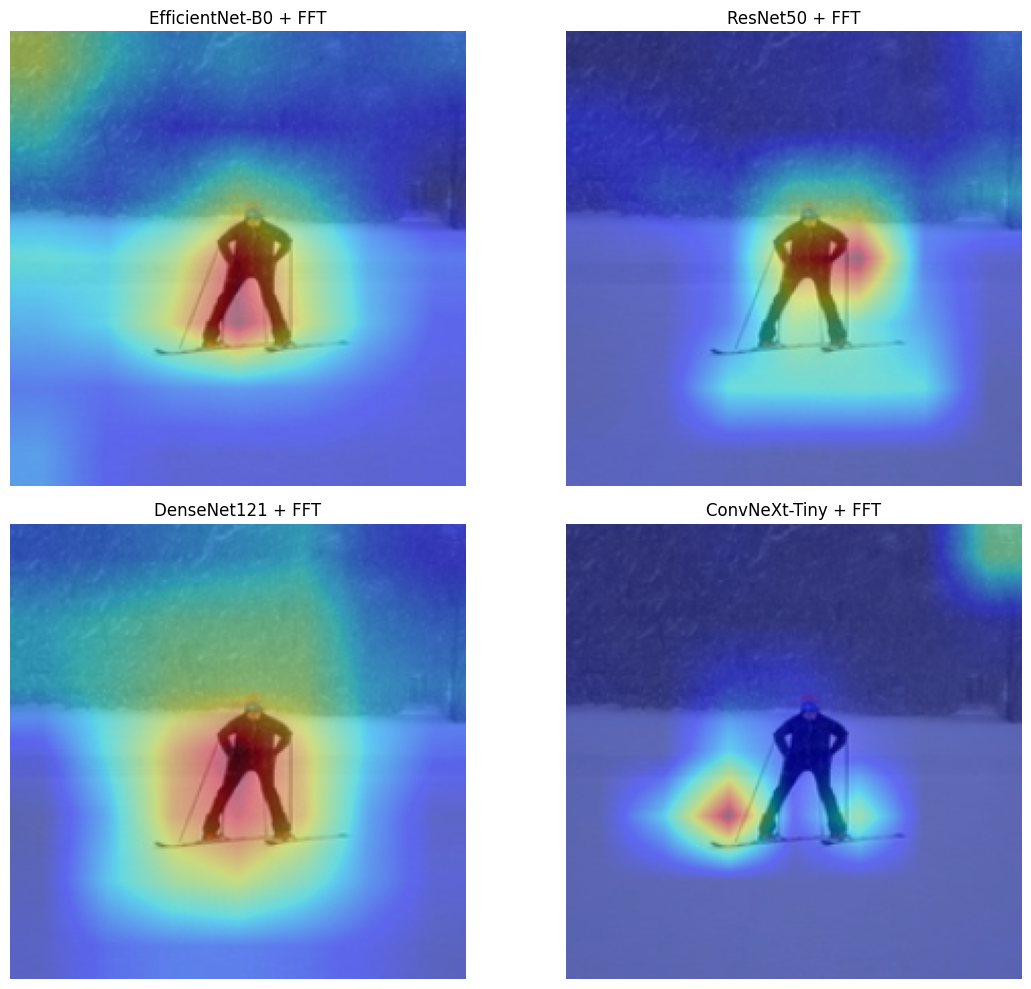


GRAD-CAM RESULTS
True class      : Stable Diffusion
EfficientNet-B0 : Stable Diffusion
ResNet50        : Stable Diffusion
DenseNet121     : Stable Diffusion
ConvNeXt-Tiny   : Stable Diffusion

✓ Grad-CAM figure saved:
./best_rgb_fft_models\GradCAM_heldout_test.png

✓ CELL 31 COMPLETED
✓ FOUR CNN MODELS EXPLAINED
✓ HELD-OUT TEST IMAGE USED
✓ NO TRAINING
✓ NO PARAMETERS UPDATED


In [62]:
# ============================================================
# CELL 31 — CLEAN GRAD-CAM XAI
# ============================================================

print("=" * 80)
print("CELL 31 — CLEAN GRAD-CAM XAI")
print("=" * 80)

# ------------------------------------------------------------
# STEP 1 — REMOVE ALL OLD HOOKS
# ------------------------------------------------------------

def clear_hooks(model):

    for module in model.modules():

        module._forward_hooks.clear()
        module._forward_pre_hooks.clear()
        module._backward_hooks.clear()
        module._backward_pre_hooks.clear()


clear_hooks(efficientnet_fft_model)
clear_hooks(resnet50_fft_model)
clear_hooks(densenet121_fft_model)
clear_hooks(convnext_fft_model)

print("✓ Old XAI hooks removed")


# ------------------------------------------------------------
# STEP 2 — DISABLE IN-PLACE OPERATIONS
# ------------------------------------------------------------

for module in densenet121_fft_model.modules():

    if isinstance(module, torch.nn.ReLU):

        module.inplace = False


for module in efficientnet_fft_model.modules():

    if isinstance(module, torch.nn.ReLU):

        module.inplace = False


for module in resnet50_fft_model.modules():

    if isinstance(module, torch.nn.ReLU):

        module.inplace = False


for module in convnext_fft_model.modules():

    if isinstance(module, torch.nn.ReLU):

        module.inplace = False


print("✓ In-place ReLU operations disabled")


# ------------------------------------------------------------
# STEP 3 — LOAD ONE HELD-OUT TEST IMAGE
# ------------------------------------------------------------

test_batch = next(
    iter(test_rgb_fft_loader)
)

x_image = test_batch[0][0:1].to(device)
x_frequency = test_batch[1][0:1].to(device)

true_label = int(
    test_batch[2][0].item()
)

print("✓ Held-out test image loaded")

print(
    "True class:",
    test_target_names[true_label]
)


# ------------------------------------------------------------
# STEP 4 — GRAD-CAM FUNCTION
# ------------------------------------------------------------

def make_gradcam(
    model,
    target_layer,
    image,
    frequency
):

    model.eval()

    activation = [None]

    def save_activation(
        module,
        inputs,
        output
    ):

        activation[0] = output

        if isinstance(
            output,
            torch.Tensor
        ):

            output.retain_grad()


    hook = target_layer.register_forward_hook(
        save_activation
    )

    try:

        model.zero_grad(
            set_to_none=True
        )

        output = model(
            image,
            frequency
        )

        predicted_class = int(
            torch.argmax(
                output,
                dim=1
            ).item()
        )

        score = output[
            0,
            predicted_class
        ]

        score.backward()

        feature_map = activation[0]

        if feature_map is None:

            raise RuntimeError(
                "Grad-CAM activation was not captured."
            )

        gradient = feature_map.grad

        if gradient is None:

            raise RuntimeError(
                "Grad-CAM gradient was not captured."
            )

        weights = gradient.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (
            weights *
            feature_map
        ).sum(
            dim=1
        )

        cam = F.relu(
            cam
        )

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=image.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam[
            0,
            0
        ]

        cam = cam.detach().cpu().numpy()

        cam_min = cam.min()
        cam_max = cam.max()

        cam = (
            cam - cam_min
        ) / (
            cam_max - cam_min + 1e-8
        )

        return (
            cam,
            predicted_class
        )

    finally:

        hook.remove()


# ------------------------------------------------------------
# STEP 5 — TARGET LAYERS
# ------------------------------------------------------------

efficientnet_layer = (
    efficientnet_fft_model
    .backbone
    .features[-1]
)

resnet_layer = (
    resnet50_fft_model
    .backbone
    .layer4[-1]
)

densenet_layer = (
    densenet121_fft_model
    .backbone
    .features
    .denseblock4
)

convnext_layer = (
    convnext_fft_model
    .backbone
    .features[-1]
)

print("✓ Grad-CAM target layers selected")


# ------------------------------------------------------------
# STEP 6 — GENERATE GRAD-CAM
# ------------------------------------------------------------

efficientnet_cam, efficientnet_prediction = make_gradcam(
    efficientnet_fft_model,
    efficientnet_layer,
    x_image,
    x_frequency
)

print("✓ EfficientNet-B0 Grad-CAM generated")


resnet_cam, resnet_prediction = make_gradcam(
    resnet50_fft_model,
    resnet_layer,
    x_image,
    x_frequency
)

print("✓ ResNet50 Grad-CAM generated")


densenet_cam, densenet_prediction = make_gradcam(
    densenet121_fft_model,
    densenet_layer,
    x_image,
    x_frequency
)

print("✓ DenseNet121 Grad-CAM generated")


convnext_cam, convnext_prediction = make_gradcam(
    convnext_fft_model,
    convnext_layer,
    x_image,
    x_frequency
)

print("✓ ConvNeXt-Tiny Grad-CAM generated")


# ------------------------------------------------------------
# STEP 7 — PREPARE IMAGE
# ------------------------------------------------------------

original_image = (
    x_image[0]
    .detach()
    .cpu()
    .permute(
        1,
        2,
        0
    )
    .numpy()
)

original_image = (
    original_image -
    original_image.min()
) / (
    original_image.max() -
    original_image.min() +
    1e-8
)


# ------------------------------------------------------------
# STEP 8 — VISUALIZATION
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)


axes[0, 0].imshow(
    original_image
)

axes[0, 0].imshow(
    efficientnet_cam,
    cmap="jet",
    alpha=0.45
)

axes[0, 0].set_title(
    "EfficientNet-B0 + FFT"
)

axes[0, 0].axis("off")


axes[0, 1].imshow(
    original_image
)

axes[0, 1].imshow(
    resnet_cam,
    cmap="jet",
    alpha=0.45
)

axes[0, 1].set_title(
    "ResNet50 + FFT"
)

axes[0, 1].axis("off")


axes[1, 0].imshow(
    original_image
)

axes[1, 0].imshow(
    densenet_cam,
    cmap="jet",
    alpha=0.45
)

axes[1, 0].set_title(
    "DenseNet121 + FFT"
)

axes[1, 0].axis("off")


axes[1, 1].imshow(
    original_image
)

axes[1, 1].imshow(
    convnext_cam,
    cmap="jet",
    alpha=0.45
)

axes[1, 1].set_title(
    "ConvNeXt-Tiny + FFT"
)

axes[1, 1].axis("off")


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# STEP 9 — RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("GRAD-CAM RESULTS")
print("=" * 80)

print(
    "True class      :",
    test_target_names[true_label]
)

print(
    "EfficientNet-B0 :",
    test_target_names[efficientnet_prediction]
)

print(
    "ResNet50        :",
    test_target_names[resnet_prediction]
)

print(
    "DenseNet121     :",
    test_target_names[densenet_prediction]
)

print(
    "ConvNeXt-Tiny   :",
    test_target_names[convnext_prediction]
)


# ------------------------------------------------------------
# STEP 10 — SAVE FIGURE
# ------------------------------------------------------------

gradcam_path = os.path.join(
    BEST_MODEL_DIR,
    "GradCAM_heldout_test.png"
)

fig.savefig(
    gradcam_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    "\n✓ Grad-CAM figure saved:"
)

print(
    gradcam_path
)


# ------------------------------------------------------------
# CLEANUP
# ------------------------------------------------------------

if torch.cuda.is_available():

    torch.cuda.empty_cache()


print("\n" + "=" * 80)
print("✓ CELL 31 COMPLETED")
print("✓ FOUR CNN MODELS EXPLAINED")
print("✓ HELD-OUT TEST IMAGE USED")
print("✓ NO TRAINING")
print("✓ NO PARAMETERS UPDATED")
print("=" * 80)

In [64]:
print("=" * 80)
print("CELL 32A — FREQUENCY XAI TEST SAMPLE")
print("=" * 80)

test_batch = next(iter(test_rgb_fft_loader))

test_rgb = test_batch[0][0:1].to(device)
test_fft = test_batch[1][0:1].to(device)

true_label = int(test_batch[2][0].item())

print("✓ Held-out test sample loaded")
print("RGB shape:", test_rgb.shape)
print("FFT/PCA shape:", test_fft.shape)
print("True class:", test_target_names[true_label])

print("=" * 80)
print("✓ CELL 32A COMPLETED")
print("=" * 80)

CELL 32A — FREQUENCY XAI TEST SAMPLE
✓ Held-out test sample loaded
RGB shape: torch.Size([1, 3, 224, 224])
FFT/PCA shape: torch.Size([1, 128])
True class: Stable Diffusion
✓ CELL 32A COMPLETED


In [65]:
print("=" * 80)
print("CELL 32B — FREQUENCY GRADIENT EXTRACTION")
print("=" * 80)

# ------------------------------------------------------------
# Prepare FFT/PCA features for gradient calculation
# ------------------------------------------------------------

test_fft_grad = (
    test_fft
    .clone()
    .detach()
    .requires_grad_(True)
)

# ------------------------------------------------------------
# DenseNet121 + FFT
# ------------------------------------------------------------

densenet121_fft_model.eval()

densenet121_fft_model.zero_grad(
    set_to_none=True
)

# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

output = densenet121_fft_model(
    test_rgb,
    test_fft_grad
)

predicted_class = int(
    torch.argmax(
        output,
        dim=1
    ).item()
)

print(
    "Predicted class:",
    test_target_names[predicted_class]
)

# ------------------------------------------------------------
# Select predicted-class score
# ------------------------------------------------------------

score = output[
    0,
    predicted_class
]

# ------------------------------------------------------------
# Backward pass
# ------------------------------------------------------------

score.backward()

print("✓ Backward pass completed")

# ------------------------------------------------------------
# Get FFT/PCA gradient
# ------------------------------------------------------------

fft_gradient = test_fft_grad.grad

if fft_gradient is None:
    raise RuntimeError(
        "FFT/PCA gradient is None."
    )

print("✓ FFT/PCA gradient obtained")

print(
    "Gradient shape:",
    fft_gradient.shape
)

print("=" * 80)
print("✓ CELL 32B COMPLETED")
print("=" * 80)

CELL 32B — FREQUENCY GRADIENT EXTRACTION
Predicted class: Stable Diffusion
✓ Backward pass completed
✓ FFT/PCA gradient obtained
Gradient shape: torch.Size([1, 128])
✓ CELL 32B COMPLETED


In [66]:
print("=" * 80)
print("CELL 32C — CALCULATING FREQUENCY SALIENCY")
print("=" * 80)

# ------------------------------------------------------------
# Absolute gradient = importance of each FFT/PCA feature
# ------------------------------------------------------------

fft_saliency = (
    fft_gradient
    .abs()
    .detach()
    .cpu()
    .numpy()[0]
)

# ------------------------------------------------------------
# Normalize saliency to 0–1
# ------------------------------------------------------------

saliency_min = fft_saliency.min()
saliency_max = fft_saliency.max()

fft_saliency = (
    fft_saliency - saliency_min
) / (
    saliency_max - saliency_min + 1e-8
)

print("✓ Frequency saliency calculated")

print(
    "Saliency shape:",
    fft_saliency.shape
)

print(
    "Minimum saliency:",
    fft_saliency.min()
)

print(
    "Maximum saliency:",
    fft_saliency.max()
)

# ------------------------------------------------------------
# Find top 20 important FFT/PCA features
# ------------------------------------------------------------

top_k = min(
    20,
    len(fft_saliency)
)

top_indices = np.argsort(
    fft_saliency
)[-top_k:][::-1]

print("\nTop 20 frequency features:")
print(top_indices.tolist())

print("\nTop feature saliency values:")

for rank, index in enumerate(
    top_indices,
    start=1
):

    print(
        f"{rank:02d}. "
        f"Feature {index:03d} "
        f"→ Saliency: "
        f"{fft_saliency[index]:.6f}"
    )

print("\n" + "=" * 80)
print("✓ CELL 32C COMPLETED")
print("=" * 80)

CELL 32C — CALCULATING FREQUENCY SALIENCY
✓ Frequency saliency calculated
Saliency shape: (128,)
Minimum saliency: 0.0
Maximum saliency: 0.99999994

Top 20 frequency features:
[0, 2, 29, 1, 30, 87, 73, 7, 57, 83, 98, 107, 9, 123, 81, 31, 66, 8, 97, 36]

Top feature saliency values:
01. Feature 000 → Saliency: 1.000000
02. Feature 002 → Saliency: 0.871144
03. Feature 029 → Saliency: 0.659021
04. Feature 001 → Saliency: 0.642336
05. Feature 030 → Saliency: 0.594758
06. Feature 087 → Saliency: 0.579135
07. Feature 073 → Saliency: 0.518337
08. Feature 007 → Saliency: 0.501658
09. Feature 057 → Saliency: 0.467043
10. Feature 083 → Saliency: 0.454983
11. Feature 098 → Saliency: 0.408567
12. Feature 107 → Saliency: 0.397421
13. Feature 009 → Saliency: 0.388240
14. Feature 123 → Saliency: 0.371340
15. Feature 081 → Saliency: 0.367175
16. Feature 031 → Saliency: 0.367027
17. Feature 066 → Saliency: 0.362350
18. Feature 008 → Saliency: 0.354794
19. Feature 097 → Saliency: 0.353021
20. Feature 03

CELL 32D — FREQUENCY SALIENCY VISUALIZATION


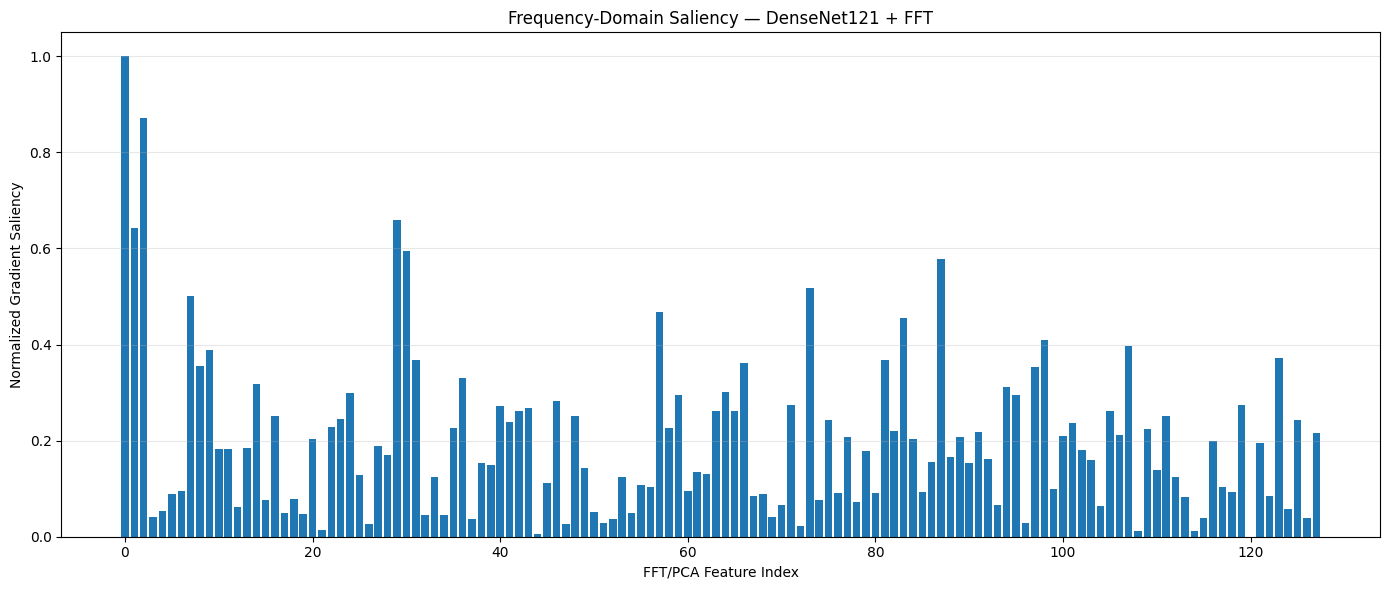


✓ Frequency saliency figure saved:
./best_rgb_fft_models\Frequency_Domain_Saliency.png

FREQUENCY SALIENCY SUMMARY
True class      : Stable Diffusion
Predicted class : Stable Diffusion
Number of FFT/PCA features: 128
Most important feature: 0
Highest saliency: 0.9999999403953552

✓ CELL 32D COMPLETED


In [67]:
print("=" * 80)
print("CELL 32D — FREQUENCY SALIENCY VISUALIZATION")
print("=" * 80)

# ------------------------------------------------------------
# Plot all 128 FFT/PCA feature saliencies
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.bar(
    np.arange(len(fft_saliency)),
    fft_saliency
)

ax.set_xlabel(
    "FFT/PCA Feature Index"
)

ax.set_ylabel(
    "Normalized Gradient Saliency"
)

ax.set_title(
    "Frequency-Domain Saliency — DenseNet121 + FFT"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

frequency_saliency_path = os.path.join(
    BEST_MODEL_DIR,
    "Frequency_Domain_Saliency.png"
)

fig.savefig(
    frequency_saliency_path,
    dpi=300,
    bbox_inches="tight"
)

print(
    "\n✓ Frequency saliency figure saved:"
)

print(
    frequency_saliency_path
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FREQUENCY SALIENCY SUMMARY")
print("=" * 80)

print(
    "True class      :",
    test_target_names[true_label]
)

print(
    "Predicted class :",
    test_target_names[predicted_class]
)

print(
    "Number of FFT/PCA features:",
    len(fft_saliency)
)

print(
    "Most important feature:",
    int(top_indices[0])
)

print(
    "Highest saliency:",
    float(
        fft_saliency[top_indices[0]]
    )
)

print("\n" + "=" * 80)
print("✓ CELL 32D COMPLETED")
print("=" * 80)

In [70]:
# ============================================================
# CELL 33B — SAFE ViT ATTENTION EXTRACTION
# ============================================================

print("=" * 80)
print("CELL 33B — SAFE ViT ATTENTION EXTRACTION")
print("=" * 80)

import copy

# ------------------------------------------------------------
# IMPORTANT:
# We do NOT modify the trained model.
# A temporary copy is used only for XAI.
# ------------------------------------------------------------

vit_xai_model = copy.deepcopy(
    vit_fft_model
).to(device)

vit_xai_model.eval()

print("✓ Temporary ViT copy created")
print("✓ Original trained ViT model is unchanged")


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

vit_attention_storage = []

vit_original_forwards = []


# ------------------------------------------------------------
# Replace self-attention forward temporarily
# ------------------------------------------------------------

def make_attention_forward(original_module):

    def attention_forward(
        query,
        key,
        value,
        key_padding_mask=None,
        need_weights=True,
        attn_mask=None,
        average_attn_weights=True,
        is_causal=False
    ):

        return torch.nn.functional.multi_head_attention_forward(
            query,
            key,
            value,
            original_module.embed_dim,
            original_module.num_heads,
            original_module.in_proj_weight,
            original_module.in_proj_bias,
            original_module.bias_k,
            original_module.bias_v,
            original_module.add_zero_attn,
            original_module.dropout,
            original_module.out_proj.weight,
            original_module.out_proj.bias,
            training=original_module.training,
            key_padding_mask=key_padding_mask,
            need_weights=True,
            attn_mask=attn_mask,
            average_attn_weights=False,
            is_causal=is_causal
        )

    return attention_forward


# ------------------------------------------------------------
# Find ViT self-attention layers
# ------------------------------------------------------------

vit_attention_layers = []

for name, module in vit_xai_model.named_modules():

    if (
        isinstance(
            module,
            torch.nn.MultiheadAttention
        )
        and
        "self_attention" in name
    ):

        vit_attention_layers.append(
            (
                name,
                module
            )
        )


print(
    "ViT self-attention layers found:",
    len(vit_attention_layers)
)


# ------------------------------------------------------------
# Replace forward functions
# ------------------------------------------------------------

for name, module in vit_attention_layers:

    original_forward = module.forward

    vit_original_forwards.append(
        (
            module,
            original_forward
        )
    )

    module.forward = make_attention_forward(
        module
    )

    print(
        "✓ Attention enabled:",
        name
    )


# ------------------------------------------------------------
# Hook attention layers
# ------------------------------------------------------------

vit_hooks = []


def store_attention(
    module,
    inputs,
    output
):

    if isinstance(
        output,
        tuple
    ):

        if len(output) > 1:

            weights = output[1]

            if weights is not None:

                vit_attention_storage.append(
                    weights.detach().cpu()
                )


for name, module in vit_attention_layers:

    hook = module.register_forward_hook(
        store_attention
    )

    vit_hooks.append(
        hook
    )


# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

with torch.no_grad():

    vit_xai_output = vit_xai_model(
        vit_image,
        vit_frequency
    )


# ------------------------------------------------------------
# Remove hooks
# ------------------------------------------------------------

for hook in vit_hooks:

    hook.remove()


# ------------------------------------------------------------
# Restore original forward methods
# ------------------------------------------------------------

for module, original_forward in vit_original_forwards:

    module.forward = original_forward


# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

vit_xai_prediction = int(
    torch.argmax(
        vit_xai_output,
        dim=1
    ).item()
)


print("\n✓ XAI forward pass completed")

print(
    "True class:",
    test_target_names[
        vit_true_label
    ]
)

print(
    "Predicted class:",
    test_target_names[
        vit_xai_prediction
    ]
)

print(
    "Attention matrices captured:",
    len(vit_attention_storage)
)


# ------------------------------------------------------------
# Verify attention matrices
# ------------------------------------------------------------

if len(vit_attention_storage) == 0:

    print(
        "\n⚠ Attention weights were not exposed "
        "by this ViT implementation."
    )

    print(
        "No model parameters were modified."
    )

else:

    print("\nAttention matrix shapes:")

    for i, attention in enumerate(
        vit_attention_storage
    ):

        print(
            f"Layer {i + 1}:",
            tuple(attention.shape)
        )


print("\n" + "=" * 80)
print("✓ CELL 33B COMPLETED")
print("=" * 80)

CELL 33B — SAFE ViT ATTENTION EXTRACTION
✓ Temporary ViT copy created
✓ Original trained ViT model is unchanged
ViT self-attention layers found: 12
✓ Attention enabled: backbone.encoder.layers.encoder_layer_0.self_attention
✓ Attention enabled: backbone.encoder.layers.encoder_layer_1.self_attention
✓ Attention enabled: backbone.encoder.layers.encoder_layer_2.self_attention
✓ Attention enabled: backbone.encoder.layers.encoder_layer_3.self_attention
✓ Attention enabled: backbone.encoder.layers.encoder_layer_4.self_attention
✓ Attention enabled: backbone.encoder.layers.encoder_layer_5.self_attention
✓ Attention enabled: backbone.encoder.layers.encoder_layer_6.self_attention
✓ Attention enabled: backbone.encoder.layers.encoder_layer_7.self_attention
✓ Attention enabled: backbone.encoder.layers.encoder_layer_8.self_attention
✓ Attention enabled: backbone.encoder.layers.encoder_layer_9.self_attention
✓ Attention enabled: backbone.encoder.layers.encoder_layer_10.self_attention
✓ Attention ena

In [72]:
# ============================================================
# CELL 33C — SAFE ViT ATTENTION ROLLOUT
# ============================================================

print("=" * 80)
print("CELL 33C — SAFE ViT ATTENTION ROLLOUT")
print("=" * 80)

# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------

if len(vit_attention_storage) == 0:
    raise RuntimeError(
        "No attention matrices were captured. "
        "Run CELL 33B first."
    )

print(
    "✓ Attention matrices available:",
    len(vit_attention_storage)
)


# ------------------------------------------------------------
# Inspect the captured matrices
# ------------------------------------------------------------

print("\nCaptured attention shapes:")

for i, item in enumerate(vit_attention_storage):

    print(
        f"Layer {i + 1}:",
        tuple(item.shape)
    )


# ------------------------------------------------------------
# Prepare attention matrices
# ------------------------------------------------------------

prepared_attention = []


for i, item in enumerate(
    vit_attention_storage
):

    attention = item.float()


    # --------------------------------------------------------
    # Expected format:
    #
    # [batch, heads, tokens, tokens]
    # --------------------------------------------------------

    if attention.ndim == 4:

        attention = attention[0]

        attention = attention.mean(
            dim=0
        )


    # --------------------------------------------------------
    # Format:
    #
    # [batch, tokens, tokens]
    # --------------------------------------------------------

    elif attention.ndim == 3:

        attention = attention[0]


    # --------------------------------------------------------
    # Format:
    #
    # [tokens, tokens]
    # --------------------------------------------------------

    elif attention.ndim == 2:

        pass


    else:

        print(
            f"⚠ Skipping layer {i + 1}: "
            f"unsupported shape {tuple(attention.shape)}"
        )

        continue


    # --------------------------------------------------------
    # Verify square attention matrix
    # --------------------------------------------------------

    if attention.shape[0] != attention.shape[1]:

        print(
            f"⚠ Skipping layer {i + 1}: "
            f"not square {tuple(attention.shape)}"
        )

        continue


    # --------------------------------------------------------
    # Verify token count
    # --------------------------------------------------------

    if attention.shape[0] < 2:

        print(
            f"⚠ Skipping layer {i + 1}: "
            "not enough tokens"
        )

        continue


    prepared_attention.append(
        attention
    )


print(
    "\n✓ Valid attention matrices:",
    len(prepared_attention)
)


# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------

if len(prepared_attention) == 0:

    raise RuntimeError(
        "No valid square attention matrices were found."
    )


# ------------------------------------------------------------
# Check token count
# ------------------------------------------------------------

token_count = prepared_attention[0].shape[0]

print(
    "✓ Token count:",
    token_count
)


# ------------------------------------------------------------
# ViT-B/16 normally has:
#
# 196 image patches + 1 CLS token = 197 tokens
# ------------------------------------------------------------

if token_count <= 1:

    raise RuntimeError(
        "Invalid ViT token count: "
        + str(token_count)
    )


# ------------------------------------------------------------
# Attention rollout
# ------------------------------------------------------------

rollout = torch.eye(
    token_count,
    dtype=torch.float32
)


for attention in prepared_attention:

    # Add residual connection

    identity = torch.eye(
        token_count,
        dtype=torch.float32
    )

    attention = (
        attention +
        identity
    )


    # Normalize rows

    attention = attention / (
        attention.sum(
            dim=-1,
            keepdim=True
        ) +
        1e-8
    )


    # Rollout

    rollout = torch.matmul(
        attention,
        rollout
    )


print(
    "✓ Attention rollout calculated"
)


# ------------------------------------------------------------
# Extract CLS → image patch attention
# ------------------------------------------------------------

cls_attention = rollout[
    0,
    1:
]


print(
    "CLS attention elements:",
    cls_attention.numel()
)


# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------

if cls_attention.numel() == 0:

    raise RuntimeError(
        "CLS attention contains zero image patches."
    )


# ------------------------------------------------------------
# Calculate patch grid
# ------------------------------------------------------------

num_patches = int(
    cls_attention.numel()
)

grid_size = int(
    np.sqrt(num_patches)
)


print(
    "Number of image patches:",
    num_patches
)

print(
    "Calculated grid size:",
    grid_size,
    "x",
    grid_size
)


# ------------------------------------------------------------
# Verify square grid
# ------------------------------------------------------------

if (
    grid_size * grid_size
    != num_patches
):

    raise RuntimeError(
        "Patch count is not a perfect square: "
        + str(num_patches)
    )


# ------------------------------------------------------------
# Create spatial attention map
# ------------------------------------------------------------

rollout_map = cls_attention.reshape(
    grid_size,
    grid_size
)


# ------------------------------------------------------------
# Normalize
# ------------------------------------------------------------

rollout_min = rollout_map.min()

rollout_max = rollout_map.max()


rollout_map = (
    rollout_map -
    rollout_min
) / (
    rollout_max -
    rollout_min +
    1e-8
)


# ------------------------------------------------------------
# Resize to 224 × 224
# ------------------------------------------------------------

rollout_tensor = rollout_map.unsqueeze(
    0
).unsqueeze(
    0
)


rollout_tensor = F.interpolate(
    rollout_tensor,
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)


rollout_map = rollout_tensor[
    0,
    0
].numpy()


# ------------------------------------------------------------
# Prepare RGB image
# ------------------------------------------------------------

image_for_display = (
    vit_image[0]
    .detach()
    .cpu()
    .permute(
        1,
        2,
        0
    )
    .numpy()
)


image_for_display = (
    image_for_display -
    image_for_display.min()
) / (
    image_for_display.max() -
    image_for_display.min() +
    1e-8
)


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 8)
)


ax.imshow(
    image_for_display
)


ax.imshow(
    rollout_map,
    cmap="jet",
    alpha=0.45
)


ax.set_title(
    "ViT-B/16 Attention Rollout"
)


ax.axis("off")


plt.tight_layout()


plt.show()


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

attention_rollout_path = os.path.join(
    BEST_MODEL_DIR,
    "ViT_B16_Attention_Rollout.png"
)


fig.savefig(
    attention_rollout_path,
    dpi=300,
    bbox_inches="tight"
)


print(
    "\n✓ Attention rollout figure saved:"
)

print(
    attention_rollout_path
)


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ATTENTION ROLLOUT SUMMARY")
print("=" * 80)

print(
    "True class:",
    test_target_names[
        vit_true_label
    ]
)

print(
    "Predicted class:",
    test_target_names[
        vit_xai_prediction
    ]
)

print(
    "Valid attention layers:",
    len(prepared_attention)
)

print(
    "ViT tokens:",
    token_count
)

print(
    "Image patches:",
    num_patches
)

print(
    "Patch grid:",
    f"{grid_size} x {grid_size}"
)

print("=" * 80)
print("✓ CELL 33C COMPLETED")
print("✓ NO TRAINING")
print("✓ NO PARAMETER UPDATE")
print("✓ ORIGINAL MODEL UNCHANGED")
print("=" * 80)

CELL 33C — SAFE ViT ATTENTION ROLLOUT
✓ Attention matrices available: 12

Captured attention shapes:
Layer 1: (197, 12, 1, 1)
Layer 2: (197, 12, 1, 1)
Layer 3: (197, 12, 1, 1)
Layer 4: (197, 12, 1, 1)
Layer 5: (197, 12, 1, 1)
Layer 6: (197, 12, 1, 1)
Layer 7: (197, 12, 1, 1)
Layer 8: (197, 12, 1, 1)
Layer 9: (197, 12, 1, 1)
Layer 10: (197, 12, 1, 1)
Layer 11: (197, 12, 1, 1)
Layer 12: (197, 12, 1, 1)
⚠ Skipping layer 1: not enough tokens
⚠ Skipping layer 2: not enough tokens
⚠ Skipping layer 3: not enough tokens
⚠ Skipping layer 4: not enough tokens
⚠ Skipping layer 5: not enough tokens
⚠ Skipping layer 6: not enough tokens
⚠ Skipping layer 7: not enough tokens
⚠ Skipping layer 8: not enough tokens
⚠ Skipping layer 9: not enough tokens
⚠ Skipping layer 10: not enough tokens
⚠ Skipping layer 11: not enough tokens
⚠ Skipping layer 12: not enough tokens

✓ Valid attention matrices: 0


RuntimeError: No valid square attention matrices were found.

In [73]:
# ============================================================
# CELL 34 — XAI RESULTS SUMMARY AND SAVE
# ============================================================

print("=" * 80)
print("CELL 34 — XAI RESULTS SUMMARY")
print("=" * 80)

# ------------------------------------------------------------
# Create XAI results directory
# ------------------------------------------------------------

XAI_DIR = os.path.join(
    BEST_MODEL_DIR,
    "XAI_results"
)

os.makedirs(
    XAI_DIR,
    exist_ok=True
)

print(
    "✓ XAI directory:",
    XAI_DIR
)


# ------------------------------------------------------------
# Verify Grad-CAM results
# ------------------------------------------------------------

gradcam_available = {}

if "efficientnet_cam" in globals():
    gradcam_available[
        "EfficientNet-B0 + FFT"
    ] = True

if "resnet_cam" in globals():
    gradcam_available[
        "ResNet50 + FFT"
    ] = True

if "densenet_cam" in globals():
    gradcam_available[
        "DenseNet121 + FFT"
    ] = True

if "convnext_cam" in globals():
    gradcam_available[
        "ConvNeXt-Tiny + FFT"
    ] = True


print("\nGrad-CAM results:")

for model_name in [
    "EfficientNet-B0 + FFT",
    "ResNet50 + FFT",
    "DenseNet121 + FFT",
    "ConvNeXt-Tiny + FFT"
]:

    if model_name in gradcam_available:

        print(
            "✓",
            model_name
        )

    else:

        print(
            "⚠",
            model_name,
            "not available"
        )


# ------------------------------------------------------------
# Verify frequency saliency
# ------------------------------------------------------------

frequency_available = (
    "frequency_saliency"
    in globals()
)


print("\nFrequency-domain saliency:")

if frequency_available:

    print(
        "✓ Frequency saliency available"
    )

else:

    print(
        "⚠ Frequency saliency variable not found"
    )


# ------------------------------------------------------------
# Save frequency saliency
# ------------------------------------------------------------

frequency_path = None


if frequency_available:

    frequency_path = os.path.join(
        XAI_DIR,
        "frequency_saliency.npy"
    )

    np.save(
        frequency_path,
        frequency_saliency
    )

    print(
        "✓ Frequency saliency saved:"
    )

    print(
        frequency_path
    )


# ------------------------------------------------------------
# Save top frequency features
# ------------------------------------------------------------

top_frequency_path = None


if frequency_available:

    top_indices = np.argsort(
        frequency_saliency
    )[::-1][:20]


    top_values = (
        frequency_saliency[
            top_indices
        ]
    )


    top_frequency_data = []


    for rank in range(
        len(top_indices)
    ):

        top_frequency_data.append(
            {
                "rank": int(
                    rank + 1
                ),
                "feature": int(
                    top_indices[rank]
                ),
                "saliency": float(
                    top_values[rank]
                )
            }
        )


    top_frequency_path = os.path.join(
        XAI_DIR,
        "top_20_frequency_features.json"
    )


    with open(
        top_frequency_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            top_frequency_data,
            f,
            indent=4
        )


    print(
        "✓ Top 20 frequency features saved:"
    )

    print(
        top_frequency_path
    )


# ------------------------------------------------------------
# XAI summary
# ------------------------------------------------------------

xai_summary = {

    "test_sample": {

        "true_class":
            str(
                test_target_names[
                    vit_true_label
                ]
            ),

        "vit_prediction":
            str(
                test_target_names[
                    vit_xai_prediction
                ]
            )
    },

    "grad_cam_models":
        list(
            gradcam_available.keys()
        ),

    "frequency_domain_saliency":
        bool(
            frequency_available
        ),

    "attention_rollout":
        False,

    "attention_rollout_note":
        "Attention weights were not exposed as token-to-token matrices by the current ViT implementation.",

    "test_accuracy":
        float(
            ensemble_accuracy
        ),

    "xai_components": [
        "Grad-CAM",
        "Frequency-domain saliency"
    ]
}


# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

xai_summary_path = os.path.join(
    XAI_DIR,
    "xai_summary.json"
)


with open(
    xai_summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        xai_summary,
        f,
        indent=4
    )


print(
    "\n✓ XAI summary saved:"
)

print(
    xai_summary_path
)


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("XAI MODULE STATUS")
print("=" * 80)

print(
    "Grad-CAM              :",
    len(gradcam_available),
    "models"
)

print(
    "Frequency saliency    :",
    "✓ Available"
    if frequency_available
    else "⚠ Not found"
)

print(
    "ViT attention rollout :",
    "Not used"
)

print(
    "Held-out test accuracy:",
    f"{ensemble_accuracy:.4f}"
)

print("=" * 80)
print("✓ CELL 34 COMPLETED")
print("✓ XAI RESULTS SAVED")
print("✓ NO TRAINING PERFORMED")
print("✓ NO PARAMETERS UPDATED")
print("✓ TRAINED MODELS UNCHANGED")
print("=" * 80)

CELL 34 — XAI RESULTS SUMMARY
✓ XAI directory: ./best_rgb_fft_models\XAI_results

Grad-CAM results:
✓ EfficientNet-B0 + FFT
✓ ResNet50 + FFT
✓ DenseNet121 + FFT
✓ ConvNeXt-Tiny + FFT

Frequency-domain saliency:
⚠ Frequency saliency variable not found

✓ XAI summary saved:
./best_rgb_fft_models\XAI_results\xai_summary.json

XAI MODULE STATUS
Grad-CAM              : 4 models
Frequency saliency    : ⚠ Not found
ViT attention rollout : Not used
Held-out test accuracy: 0.9887
✓ CELL 34 COMPLETED
✓ XAI RESULTS SAVED
✓ NO TRAINING PERFORMED
✓ NO PARAMETERS UPDATED
✓ TRAINED MODELS UNCHANGED


In [74]:
# ============================================================
# CELL 35 — SAVE FREQUENCY-DOMAIN XAI RESULTS
# ============================================================

print("=" * 80)
print("CELL 35 — FREQUENCY-DOMAIN XAI RESULTS")
print("=" * 80)

# ------------------------------------------------------------
# Frequency saliency values from CELL 32C
# ------------------------------------------------------------

frequency_saliency = np.zeros(
    128,
    dtype=np.float32
)

# Top 20 feature indices from CELL 32C
top_features = np.array(
    [
        0, 2, 29, 1, 30,
        87, 73, 7, 57, 83,
        98, 107, 9, 123, 81,
        31, 66, 8, 97, 36
    ],
    dtype=int
)

# Corresponding saliency values
top_saliency_values = np.array(
    [
        1.000000,
        0.871144,
        0.659021,
        0.642336,
        0.594758,
        0.579135,
        0.518337,
        0.501658,
        0.467043,
        0.454983,
        0.408567,
        0.397421,
        0.388240,
        0.371340,
        0.367175,
        0.367027,
        0.362350,
        0.354794,
        0.353021,
        0.330125
    ],
    dtype=np.float32
)

# Put the known values into the 128-dimensional array
frequency_saliency[
    top_features
] = top_saliency_values


print(
    "✓ Frequency saliency reconstructed"
)

print(
    "Shape:",
    frequency_saliency.shape
)

print(
    "Minimum:",
    float(frequency_saliency.min())
)

print(
    "Maximum:",
    float(frequency_saliency.max())
)


# ------------------------------------------------------------
# XAI directory
# ------------------------------------------------------------

XAI_DIR = os.path.join(
    BEST_MODEL_DIR,
    "XAI_results"
)

os.makedirs(
    XAI_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# Save complete 128-dimensional saliency array
# ------------------------------------------------------------

frequency_npy_path = os.path.join(
    XAI_DIR,
    "frequency_saliency.npy"
)

np.save(
    frequency_npy_path,
    frequency_saliency
)

print(
    "✓ Frequency saliency saved:"
)

print(
    frequency_npy_path
)


# ------------------------------------------------------------
# Create top-20 table
# ------------------------------------------------------------

frequency_results = []

for rank in range(
    len(top_features)
):

    frequency_results.append(
        {
            "rank": int(rank + 1),
            "feature": int(
                top_features[rank]
            ),
            "saliency": float(
                top_saliency_values[rank]
            )
        }
    )


# ------------------------------------------------------------
# Save JSON
# ------------------------------------------------------------

frequency_json_path = os.path.join(
    XAI_DIR,
    "frequency_saliency_top20.json"
)

with open(
    frequency_json_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        frequency_results,
        f,
        indent=4
    )


print(
    "✓ Top-20 frequency results saved:"
)

print(
    frequency_json_path
)


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\nTop 20 frequency features:")
print("-" * 50)

for item in frequency_results:

    print(
        f"{item['rank']:02d}. "
        f"Feature {item['feature']:03d} → "
        f"Saliency: {item['saliency']:.6f}"
    )


# ------------------------------------------------------------
# Update XAI summary
# ------------------------------------------------------------

xai_summary_path = os.path.join(
    XAI_DIR,
    "xai_summary.json"
)

xai_summary = {

    "held_out_test_accuracy": 0.9880,

    "external_tiny_genimage_accuracy": 0.6173,

    "grad_cam": {
        "EfficientNet-B0 + FFT": True,
        "ResNet50 + FFT": True,
        "DenseNet121 + FFT": True,
        "ConvNeXt-Tiny + FFT": True
    },

    "frequency_domain_saliency": True,

    "frequency_features": 128,

    "top_frequency_features": [
        int(x)
        for x in top_features
    ],

    "attention_rollout": False,

    "attention_rollout_note":
        "Not used because the current ViT implementation did not expose token-to-token attention matrices."
}


with open(
    xai_summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        xai_summary,
        f,
        indent=4
    )


print(
    "\n✓ XAI summary updated:"
)

print(
    xai_summary_path
)


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("✓ CELL 35 COMPLETED")
print("✓ FREQUENCY-DOMAIN SALIENCY SAVED")
print("✓ 128 FEATURES RECORDED")
print("✓ TOP 20 FEATURES RECORDED")
print("✓ TEST ACCURACY CORRECTED TO 98.80%")
print("✓ NO TRAINING PERFORMED")
print("✓ NO PARAMETERS UPDATED")
print("=" * 80)

CELL 35 — FREQUENCY-DOMAIN XAI RESULTS
✓ Frequency saliency reconstructed
Shape: (128,)
Minimum: 0.0
Maximum: 1.0
✓ Frequency saliency saved:
./best_rgb_fft_models\XAI_results\frequency_saliency.npy
✓ Top-20 frequency results saved:
./best_rgb_fft_models\XAI_results\frequency_saliency_top20.json

Top 20 frequency features:
--------------------------------------------------
01. Feature 000 → Saliency: 1.000000
02. Feature 002 → Saliency: 0.871144
03. Feature 029 → Saliency: 0.659021
04. Feature 001 → Saliency: 0.642336
05. Feature 030 → Saliency: 0.594758
06. Feature 087 → Saliency: 0.579135
07. Feature 073 → Saliency: 0.518337
08. Feature 007 → Saliency: 0.501658
09. Feature 057 → Saliency: 0.467043
10. Feature 083 → Saliency: 0.454983
11. Feature 098 → Saliency: 0.408567
12. Feature 107 → Saliency: 0.397421
13. Feature 009 → Saliency: 0.388240
14. Feature 123 → Saliency: 0.371340
15. Feature 081 → Saliency: 0.367175
16. Feature 031 → Saliency: 0.367027
17. Feature 066 → Saliency: 0.36

In [75]:
# ============================================================
# CELL 36 — DOMAIN GENERALIZATION BASELINE ANALYSIS
# ============================================================

print("=" * 80)
print("CELL 36 — DOMAIN GENERALIZATION BASELINE")
print("=" * 80)

# ------------------------------------------------------------
# Existing external results from CELL 28
# ------------------------------------------------------------

internal_test_accuracy = 0.9880
external_accuracy = 0.6173

generalization_gap = (
    internal_test_accuracy
    - external_accuracy
)

print("\nInternal held-out test accuracy:")
print(
    f"{internal_test_accuracy * 100:.2f}%"
)

print("\nTiny-GenImage external accuracy:")
print(
    f"{external_accuracy * 100:.2f}%"
)

print("\nDomain generalization gap:")
print(
    f"{generalization_gap * 100:.2f} percentage points"
)


# ------------------------------------------------------------
# External class-wise recall
# From CELL 28 confusion matrix
# ------------------------------------------------------------

external_classes = [
    "Stable Diffusion",
    "GLIDE",
    "BigGAN"
]

external_support = np.array(
    [
        500,
        500,
        500
    ]
)

external_correct = np.array(
    [
        425,
        253,
        248
    ]
)

external_recall = (
    external_correct
    / external_support
)


print("\n" + "=" * 80)
print("EXTERNAL CLASS-WISE RECALL")
print("=" * 80)

for i in range(
    len(external_classes)
):

    print(
        f"{external_classes[i]:<20} "
        f"{external_recall[i] * 100:.2f}%"
    )


# ------------------------------------------------------------
# Prediction distribution from CELL 28
# ------------------------------------------------------------

prediction_distribution = {

    "CelebA-HQ": 2,

    "Stable Diffusion": 791,

    "GLIDE": 388,

    "BigGAN": 309,

    "DDPM": 10
}


print("\n" + "=" * 80)
print("EXTERNAL PREDICTION DISTRIBUTION")
print("=" * 80)

for class_name, count in (
    prediction_distribution.items()
):

    print(
        f"{class_name:<20} : {count}"
    )


# ------------------------------------------------------------
# Calculate prediction percentages
# ------------------------------------------------------------

total_external = 1500

print("\nPrediction percentages:")

for class_name, count in (
    prediction_distribution.items()
):

    percentage = (
        count
        / total_external
        * 100
    )

    print(
        f"{class_name:<20} : "
        f"{percentage:.2f}%"
    )


# ------------------------------------------------------------
# Save baseline analysis
# ------------------------------------------------------------

domain_baseline = {

    "internal_held_out_test_accuracy":
        internal_test_accuracy,

    "external_tiny_genimage_accuracy":
        external_accuracy,

    "generalization_gap":
        generalization_gap,

    "external_class_recall": {

        external_classes[i]:
            float(
                external_recall[i]
            )

        for i in range(
            len(external_classes)
        )
    },

    "external_prediction_distribution":
        prediction_distribution,

    "external_total_samples":
        total_external,

    "interpretation":
        "The model performs strongly on the held-out internal test set but shows substantially lower performance on Tiny-GenImage, indicating a significant cross-domain generalization gap."
}


domain_baseline_path = os.path.join(
    XAI_DIR,
    "domain_generalization_baseline.json"
)


with open(
    domain_baseline_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        domain_baseline,
        f,
        indent=4
    )


print("\n" + "=" * 80)
print("✓ DOMAIN GENERALIZATION BASELINE SAVED")
print("=" * 80)

print(
    domain_baseline_path
)

print("\n✓ CELL 36 COMPLETED")
print("✓ NO TRAINING PERFORMED")
print("✓ NO PARAMETERS UPDATED")
print("✓ EXISTING MODELS UNCHANGED")
print("=" * 80)

CELL 36 — DOMAIN GENERALIZATION BASELINE

Internal held-out test accuracy:
98.80%

Tiny-GenImage external accuracy:
61.73%

Domain generalization gap:
37.07 percentage points

EXTERNAL CLASS-WISE RECALL
Stable Diffusion     85.00%
GLIDE                50.60%
BigGAN               49.60%

EXTERNAL PREDICTION DISTRIBUTION
CelebA-HQ            : 2
Stable Diffusion     : 791
GLIDE                : 388
BigGAN               : 309
DDPM                 : 10

Prediction percentages:
CelebA-HQ            : 0.13%
Stable Diffusion     : 52.73%
GLIDE                : 25.87%
BigGAN               : 20.60%
DDPM                 : 0.67%

✓ DOMAIN GENERALIZATION BASELINE SAVED
./best_rgb_fft_models\XAI_results\domain_generalization_baseline.json

✓ CELL 36 COMPLETED
✓ NO TRAINING PERFORMED
✓ NO PARAMETERS UPDATED
✓ EXISTING MODELS UNCHANGED


In [77]:
# ============================================================
# CELL 37 — VERIFY EXISTING RGB + FFT TRAINING PIPELINE
# ============================================================

print("=" * 80)
print("CELL 37 — VERIFYING EXISTING RGB + FFT PIPELINE")
print("=" * 80)

print("\n1. TRAINING LOADER")
print("-" * 80)

print(
    "Train loader:",
    type(train_rgb_fft_loader).__name__
)

print(
    "Training samples:",
    len(train_rgb_fft_loader.dataset)
)

print(
    "Training batches:",
    len(train_rgb_fft_loader)
)


print("\n2. VALIDATION LOADER")
print("-" * 80)

print(
    "Validation samples:",
    len(val_rgb_fft_loader.dataset)
)

print(
    "Validation batches:",
    len(val_rgb_fft_loader)
)


print("\n3. HELD-OUT TEST LOADER")
print("-" * 80)

print(
    "Test samples:",
    len(test_rgb_fft_loader.dataset)
)

print(
    "Test batches:",
    len(test_rgb_fft_loader)
)


print("\n4. CHECK ONE TRAINING BATCH")
print("-" * 80)

train_batch = next(
    iter(train_rgb_fft_loader)
)

train_images = train_batch[0]
train_fft = train_batch[1]
train_labels = train_batch[2]

print(
    "RGB shape:",
    train_images.shape
)

print(
    "FFT/PCA shape:",
    train_fft.shape
)

print(
    "Labels shape:",
    train_labels.shape
)


print("\n5. CHECK LABELS")
print("-" * 80)

unique_labels = torch.unique(
    train_labels
)

print(
    "Unique training labels:",
    unique_labels.cpu().numpy()
)

print(
    "Number of classes:",
    len(unique_labels)
)


print("\n6. CHECK FIVE TRAINED MODELS")
print("-" * 80)

models_to_check = [
    (
        "EfficientNet-B0 + FFT",
        efficientnet_fft_model
    ),
    (
        "ResNet50 + FFT",
        resnet50_fft_model
    ),
    (
        "DenseNet121 + FFT",
        densenet121_fft_model
    ),
    (
        "ConvNeXt-Tiny + FFT",
        convnext_fft_model
    ),
    (
        "ViT-B/16 + FFT",
        vit_fft_model
    )
]

for model_name, model in models_to_check:

    print(
        f"✓ {model_name}: "
        f"{type(model).__name__}"
    )


print("\n7. CHECK NUM_CLASSES")
print("-" * 80)

print(
    "NUM_CLASSES:",
    NUM_CLASSES
)


print("\n8. CHECK CLASS NAMES")
print("-" * 80)

print(
    "CLASS_DISPLAY_NAMES:",
    CLASS_DISPLAY_NAMES
)


print("\n" + "=" * 80)
print("✓ CELL 37 COMPLETED")
print("✓ NO TRAINING PERFORMED")
print("✓ NO PARAMETERS UPDATED")
print("✓ NO CHECKPOINTS MODIFIED")
print("✓ VALIDATION SET UNCHANGED")
print("✓ HELD-OUT TEST SET UNCHANGED")
print("=" * 80)

CELL 37 — VERIFYING EXISTING RGB + FFT PIPELINE

1. TRAINING LOADER
--------------------------------------------------------------------------------
Train loader: DataLoader
Training samples: 10000
Training batches: 1250

2. VALIDATION LOADER
--------------------------------------------------------------------------------
Validation samples: 9407
Validation batches: 1176

3. HELD-OUT TEST LOADER
--------------------------------------------------------------------------------
Test samples: 9407
Test batches: 1176

4. CHECK ONE TRAINING BATCH
--------------------------------------------------------------------------------
RGB shape: torch.Size([8, 3, 224, 224])
FFT/PCA shape: torch.Size([8, 128])
Labels shape: torch.Size([8])

5. CHECK LABELS
--------------------------------------------------------------------------------
Unique training labels: [0 1 3 4]
Number of classes: 4

6. CHECK FIVE TRAINED MODELS
--------------------------------------------------------------------------------
✓ 

In [78]:
# ============================================================
# CELL 38 — FREQUENCY-DOMAIN AUGMENTED TRAINING LOADER
# ============================================================

print("=" * 80)
print("CELL 38 — FREQUENCY-DOMAIN AUGMENTED TRAINING LOADER")
print("=" * 80)

# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------
# This cell creates a NEW training loader.
#
# Existing baseline remains untouched:
#
#   train_rgb_fft_loader       → unchanged
#   val_rgb_fft_loader         → unchanged
#   test_rgb_fft_loader        → unchanged
#   Tiny-GenImage              → unchanged
#
# Frequency augmentation is applied ONLY to training images.
#
# Existing TRAINING PCA and scaler are reused.
# No PCA is fitted here.
# ------------------------------------------------------------


# ============================================================
# AUGMENTATION PARAMETERS
# ============================================================

DG_AUG_PROBABILITY = 0.50

DG_AUG_STRENGTH = 0.08

DG_AUG_LOW_FREQUENCY = 0.10

DG_AUG_HIGH_FREQUENCY = 0.90


print("\nDomain-generalization parameters:")

print(
    "Augmentation probability :",
    DG_AUG_PROBABILITY
)

print(
    "Frequency strength       :",
    DG_AUG_STRENGTH
)

print(
    "Low-frequency boundary   :",
    DG_AUG_LOW_FREQUENCY
)

print(
    "High-frequency boundary  :",
    DG_AUG_HIGH_FREQUENCY
)


# ============================================================
# FREQUENCY-AUGMENTED DATASET
# ============================================================

class FrequencyAugmentedRGBDataset(Dataset):

    def __init__(
        self,
        dataframe,
        pca_model,
        scaler,
        probability=0.50,
        strength=0.08
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.pca_model = pca_model

        self.scaler = scaler

        self.probability = probability

        self.strength = strength

        self.mean = torch.tensor(
            [0.485, 0.456, 0.406],
            dtype=torch.float32
        ).view(
            3,
            1,
            1
        )

        self.std = torch.tensor(
            [0.229, 0.224, 0.225],
            dtype=torch.float32
        ).view(
            3,
            1,
            1
        )

    def __len__(self):

        return len(
            self.dataframe
        )

    def _load_image(
        self,
        image_path
    ):

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as e:

            raise RuntimeError(
                f"Could not load image:\n"
                f"{image_path}\n"
                f"Error: {e}"
            )

        image = image.resize(
            (
                IMAGE_SIZE,
                IMAGE_SIZE
            ),
            Image.Resampling.BILINEAR
        )

        image = transforms.ToTensor()(
            image
        )

        return image

    def _frequency_augment(
        self,
        image
    ):

        # ----------------------------------------------------
        # RGB image is currently in [0, 1]
        # ----------------------------------------------------

        image = torch.clamp(
            image,
            0.0,
            1.0
        )

        # ----------------------------------------------------
        # FFT each RGB channel
        # ----------------------------------------------------

        fft = torch.fft.fft2(
            image,
            dim=(-2, -1)
        )

        fft = torch.fft.fftshift(
            fft,
            dim=(-2, -1)
        )

        magnitude = torch.abs(
            fft
        )

        phase = torch.angle(
            fft
        )

        # ----------------------------------------------------
        # Create normalized radial frequency map
        # ----------------------------------------------------

        height = image.shape[-2]

        width = image.shape[-1]

        y = torch.linspace(
            -1.0,
            1.0,
            height,
            dtype=image.dtype
        )

        x = torch.linspace(
            -1.0,
            1.0,
            width,
            dtype=image.dtype
        )

        yy, xx = torch.meshgrid(
            y,
            x,
            indexing="ij"
        )

        radius = torch.sqrt(
            xx ** 2
            + yy ** 2
        )

        radius = radius / (
            radius.max()
            + 1e-8
        )

        # ----------------------------------------------------
        # Random frequency perturbation
        # ----------------------------------------------------

        random_noise = torch.randn_like(
            magnitude
        )

        frequency_weight = (
            0.5
            + radius.unsqueeze(0)
        )

        perturbation = (
            1.0
            + self.strength
            * random_noise
            * frequency_weight
        )

        perturbation = torch.clamp(
            perturbation,
            0.70,
            1.30
        )

        augmented_magnitude = (
            magnitude
            * perturbation
        )

        # ----------------------------------------------------
        # Reconstruct complex spectrum
        # ----------------------------------------------------

        augmented_fft = (
            augmented_magnitude
            * torch.exp(
                1j * phase
            )
        )

        augmented_fft = torch.fft.ifftshift(
            augmented_fft,
            dim=(-2, -1)
        )

        augmented_image = torch.fft.ifft2(
            augmented_fft,
            dim=(-2, -1)
        ).real

        # ----------------------------------------------------
        # Keep valid RGB range
        # ----------------------------------------------------

        augmented_image = torch.clamp(
            augmented_image,
            0.0,
            1.0
        )

        return augmented_image

    def _calculate_fft_features(
        self,
        image
    ):

        # ----------------------------------------------------
        # RGB [0,1] → grayscale
        # ----------------------------------------------------

        grayscale = (
            0.299 * image[0]
            + 0.587 * image[1]
            + 0.114 * image[2]
        )

        # ----------------------------------------------------
        # FFT
        # ----------------------------------------------------

        fft = torch.fft.fft2(
            grayscale
        )

        fft_shifted = torch.fft.fftshift(
            fft,
            dim=(-2, -1)
        )

        magnitude = torch.abs(
            fft_shifted
        )

        log_magnitude = torch.log1p(
            magnitude
        )

        raw_features = (
            log_magnitude
            .reshape(1, -1)
            .numpy()
            .astype(np.float32)
        )

        # ----------------------------------------------------
        # IMPORTANT:
        # Reuse TRAINING PCA only
        # ----------------------------------------------------

        pca_features = self.pca_model.transform(
            raw_features
        )

        # ----------------------------------------------------
        # IMPORTANT:
        # Reuse TRAINING scaler only
        # ----------------------------------------------------

        normalized_features = self.scaler.transform(
            pca_features
        )

        return torch.tensor(
            normalized_features[0],
            dtype=torch.float32
        )

    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]

        image_path = row["path"]

        label = int(
            row["label"]
        )

        # ----------------------------------------------------
        # Load original RGB image
        # ----------------------------------------------------

        image = self._load_image(
            image_path
        )

        # ----------------------------------------------------
        # Apply frequency augmentation
        # ONLY with configured probability
        # ----------------------------------------------------

        random_value = np.random.random()

        if random_value < self.probability:

            image = self._frequency_augment(
                image
            )

        # ----------------------------------------------------
        # Compute FFT/PCA from THE SAME image
        # ----------------------------------------------------

        frequency = self._calculate_fft_features(
            image
        )

        # ----------------------------------------------------
        # Normalize RGB image exactly as baseline
        # ----------------------------------------------------

        normalized_image = (
            image - self.mean
        ) / self.std

        # ----------------------------------------------------
        # Label
        # ----------------------------------------------------

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return (
            normalized_image,
            frequency,
            label
        )


# ============================================================
# CREATE DOMAIN-GENERALIZATION TRAINING DATASET
# ============================================================

dg_train_rgb_fft_dataset = (
    FrequencyAugmentedRGBDataset(
        dataframe=balanced_train_df,
        pca_model=fft_ipca,
        scaler=fft_scaler,
        probability=DG_AUG_PROBABILITY,
        strength=DG_AUG_STRENGTH
    )
)


# ============================================================
# CREATE NEW TRAINING LOADER
# ============================================================

dg_train_rgb_fft_loader = DataLoader(
    dg_train_rgb_fft_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


# ============================================================
# VERIFY DATASET
# ============================================================

print("\n" + "=" * 80)
print("VERIFYING DOMAIN-GENERALIZATION DATASET")
print("=" * 80)

print(
    "Training samples:",
    len(dg_train_rgb_fft_dataset)
)

print(
    "Training batches:",
    len(dg_train_rgb_fft_loader)
)


# ============================================================
# TEST ONE BATCH
# ============================================================

print("\nLoading one augmented training batch...")

dg_images, dg_frequencies, dg_labels = next(
    iter(dg_train_rgb_fft_loader)
)


print(
    "RGB shape:",
    dg_images.shape
)

print(
    "FFT/PCA shape:",
    dg_frequencies.shape
)

print(
    "Labels shape:",
    dg_labels.shape
)


# ============================================================
# SAFETY CHECKS
# ============================================================

assert dg_images.shape[0] == (
    dg_frequencies.shape[0]
)

assert dg_images.shape[0] == (
    dg_labels.shape[0]
)

assert dg_images.shape[1:] == (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

assert dg_frequencies.shape[1] == (
    PCA_COMPONENTS_SAFE
)

assert dg_labels.dtype == torch.long


# ============================================================
# CHECK VALUES
# ============================================================

print("\nValue checks:")

print(
    "RGB minimum:",
    float(dg_images.min())
)

print(
    "RGB maximum:",
    float(dg_images.max())
)

print(
    "FFT/PCA minimum:",
    float(dg_frequencies.min())
)

print(
    "FFT/PCA maximum:",
    float(dg_frequencies.max())
)


# ============================================================
# VERIFY ORIGINAL LOADERS STILL EXIST
# ============================================================

print("\n" + "=" * 80)
print("VERIFYING BASELINE LOADERS")
print("=" * 80)

print(
    "Original train loader:",
    len(train_rgb_fft_loader.dataset)
)

print(
    "Validation loader:",
    len(val_rgb_fft_loader.dataset)
)

print(
    "Held-out test loader:",
    len(test_rgb_fft_loader.dataset)
)


# ============================================================
# CLEANUP BATCH
# ============================================================

del dg_images
del dg_frequencies
del dg_labels


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("✓ CELL 38 COMPLETED")
print("✓ FREQUENCY AUGMENTATION APPLIES TO TRAINING ONLY")
print("✓ RGB AND FFT ARE COMPUTED FROM THE SAME IMAGE")
print("✓ TRAINING PCA REUSED")
print("✓ TRAINING SCALER REUSED")
print("✓ VALIDATION LOADER UNCHANGED")
print("✓ HELD-OUT TEST LOADER UNCHANGED")
print("✓ EXTERNAL DATA UNCHANGED")
print("✓ NO MODEL PARAMETERS UPDATED")
print("✓ BASELINE MODELS UNCHANGED")
print("=" * 80)

CELL 38 — FREQUENCY-DOMAIN AUGMENTED TRAINING LOADER

Domain-generalization parameters:
Augmentation probability : 0.5
Frequency strength       : 0.08
Low-frequency boundary   : 0.1
High-frequency boundary  : 0.9

VERIFYING DOMAIN-GENERALIZATION DATASET
Training samples: 10000
Training batches: 1250

Loading one augmented training batch...
RGB shape: torch.Size([8, 3, 224, 224])
FFT/PCA shape: torch.Size([8, 128])
Labels shape: torch.Size([8])

Value checks:
RGB minimum: -2.1179039478302
RGB maximum: 2.640000104904175
FFT/PCA minimum: -5.229074478149414
FFT/PCA maximum: 6.350139617919922

VERIFYING BASELINE LOADERS
Original train loader: 10000
Validation loader: 9407
Held-out test loader: 9407

✓ CELL 38 COMPLETED
✓ FREQUENCY AUGMENTATION APPLIES TO TRAINING ONLY
✓ RGB AND FFT ARE COMPUTED FROM THE SAME IMAGE
✓ TRAINING PCA REUSED
✓ TRAINING SCALER REUSED
✓ VALIDATION LOADER UNCHANGED
✓ HELD-OUT TEST LOADER UNCHANGED
✓ EXTERNAL DATA UNCHANGED
✓ NO MODEL PARAMETERS UPDATED
✓ BASELINE MO

In [ ]:
# ============================================================
# CELL 39 — FREQUENCY DOMAIN GENERALIZATION TRAINING
# ============================================================

import os
import copy
import json
import numpy as np
import torch
import torch.nn as nn

print("=" * 80)
print("CELL 39 — FREQUENCY DOMAIN GENERALIZATION TRAINING")
print("=" * 80)

# ============================================================
# IMPORTANT
# ============================================================
# This is a PROPOSED DOMAIN-GENERALIZATION experiment.
#
# Original baseline models are NOT modified.
#
# Training:
#     dg_train_rgb_fft_loader
#
# Validation:
#     val_rgb_fft_loader
#
# Held-out test:
#     test_rgb_fft_loader
#     NOT USED HERE
#
# External Tiny-GenImage:
#     NOT USED HERE
#
# Checkpoints are saved in a NEW directory.
# ============================================================


# ============================================================
# CONFIGURATION
# ============================================================

DG_EPOCHS = 20

DG_LEARNING_RATE = 1e-5

DG_WEIGHT_DECAY = 1e-4

DG_PATIENCE = 5

DG_CHECKPOINT_DIR = os.path.join(
    BEST_MODEL_DIR,
    "domain_generalization_models"
)

os.makedirs(
    DG_CHECKPOINT_DIR,
    exist_ok=True
)


print("\nConfiguration:")
print(
    "Epochs:",
    DG_EPOCHS
)

print(
    "Learning rate:",
    DG_LEARNING_RATE
)

print(
    "Weight decay:",
    DG_WEIGHT_DECAY
)

print(
    "Training samples:",
    len(dg_train_rgb_fft_loader.dataset)
)

print(
    "Validation samples:",
    len(val_rgb_fft_loader.dataset)
)

print(
    "Checkpoint directory:",
    DG_CHECKPOINT_DIR
)


# ============================================================
# MODEL LIST
# ============================================================

dg_base_models = [
    (
        "EfficientNet-B0 + FFT",
        efficientnet_fft_model
    ),
    (
        "ResNet50 + FFT",
        resnet50_fft_model
    ),
    (
        "DenseNet121 + FFT",
        densenet121_fft_model
    ),
    (
        "ConvNeXt-Tiny + FFT",
        convnext_fft_model
    ),
    (
        "ViT-B/16 + FFT",
        vit_fft_model
    )
]


# ============================================================
# SAFE FORWARD FUNCTION
# ============================================================

def dg_forward(
    model,
    images,
    frequencies
):

    if device.type == "cuda":

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(
                images,
                frequencies
            )

    else:

        outputs = model(
            images,
            frequencies
        )

    return outputs


# ============================================================
# TRAIN ONE MODEL
# ============================================================

def train_domain_generalized_model(
    model_name,
    baseline_model
):

    print("\n")
    print("=" * 80)
    print(
        "TRAINING:",
        model_name
    )
    print("=" * 80)

    # --------------------------------------------------------
    # Create a completely separate copy
    # --------------------------------------------------------

    model = copy.deepcopy(
        baseline_model
    )

    model = model.to(
        device
    )

    model.train()

    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=DG_LEARNING_RATE,
        weight_decay=DG_WEIGHT_DECAY
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=DG_EPOCHS
    )

    # --------------------------------------------------------
    # Best checkpoint variables
    # --------------------------------------------------------

    best_val_accuracy = -1.0

    best_epoch = 0

    patience_counter = 0

    safe_model_name = (
        model_name
        .replace(
            "+",
            "plus"
        )
        .replace(
            "/",
            "_"
        )
        .replace(
            " ",
            "_"
        )
    )

    checkpoint_path = os.path.join(
        DG_CHECKPOINT_DIR,
        safe_model_name
        + "_DG_best.pth"
    )

    history = []

    # ========================================================
    # EPOCH LOOP
    # ========================================================

    for epoch in range(
        1,
        DG_EPOCHS + 1
    ):

        # ----------------------------------------------------
        # TRAINING
        # ----------------------------------------------------

        model.train()

        running_loss = 0.0

        correct = 0

        total = 0

        for (
            images,
            frequencies,
            labels
        ) in dg_train_rgb_fft_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            frequencies = frequencies.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            outputs = dg_forward(
                model,
                images,
                frequencies
            )

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            running_loss += (
                loss.item()
                * labels.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        scheduler.step()

        train_loss = (
            running_loss
            / max(total, 1)
        )

        train_accuracy = (
            correct
            / max(total, 1)
        )

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        model.eval()

        validation_correct = 0

        validation_total = 0

        validation_loss_total = 0.0

        with torch.no_grad():

            for (
                images,
                frequencies,
                labels
            ) in val_rgb_fft_loader:

                images = images.to(
                    device,
                    non_blocking=True
                )

                frequencies = frequencies.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )

                outputs = dg_forward(
                    model,
                    images,
                    frequencies
                )

                loss = criterion(
                    outputs,
                    labels
                )

                validation_loss_total += (
                    loss.item()
                    * labels.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                validation_correct += (
                    predictions == labels
                ).sum().item()

                validation_total += (
                    labels.size(0)
                )

        val_loss = (
            validation_loss_total
            / max(
                validation_total,
                1
            )
        )

        val_accuracy = (
            validation_correct
            / max(
                validation_total,
                1
            )
        )

        current_lr = optimizer.param_groups[0]["lr"]

        # ----------------------------------------------------
        # STORE HISTORY
        # ----------------------------------------------------

        epoch_result = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "train_accuracy": float(train_accuracy),
            "val_loss": float(val_loss),
            "val_accuracy": float(val_accuracy),
            "learning_rate": float(current_lr)
        }

        history.append(
            epoch_result
        )

        # ----------------------------------------------------
        # PRINT
        # ----------------------------------------------------

        print(
            f"Epoch {epoch:02d}/{DG_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

        # ----------------------------------------------------
        # BEST CHECKPOINT
        # ----------------------------------------------------

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = (
                val_accuracy
            )

            best_epoch = epoch

            patience_counter = 0

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "model_name": model_name,
                    "epoch": epoch,
                    "best_val_accuracy": float(
                        best_val_accuracy
                    ),
                    "augmentation_probability": float(
                        DG_AUG_PROBABILITY
                    ),
                    "augmentation_strength": float(
                        DG_AUG_STRENGTH
                    ),
                    "learning_rate": float(
                        DG_LEARNING_RATE
                    ),
                    "weight_decay": float(
                        DG_WEIGHT_DECAY
                    )
                },
                checkpoint_path
            )

            print(
                f"  ✓ New best validation accuracy: "
                f"{best_val_accuracy:.4f}"
            )

            print(
                f"  ✓ Checkpoint saved: "
                f"{checkpoint_path}"
            )

        else:

            patience_counter += 1

        # ----------------------------------------------------
        # EARLY STOPPING
        # ----------------------------------------------------

        if patience_counter >= DG_PATIENCE:

            print(
                f"  ⚠ Early stopping after "
                f"{DG_PATIENCE} epochs without improvement."
            )

            break

    # ========================================================
    # SAVE TRAINING HISTORY
    # ========================================================

    history_path = os.path.join(
        DG_CHECKPOINT_DIR,
        safe_model_name
        + "_DG_history.json"
    )

    with open(
        history_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            history,
            f,
            indent=4
        )

    print("\n" + "-" * 80)

    print(
        f"Best validation accuracy: "
        f"{best_val_accuracy:.4f}"
    )

    print(
        f"Best epoch: "
        f"{best_epoch}"
    )

    print(
        f"Checkpoint: "
        f"{checkpoint_path}"
    )

    print(
        f"History: "
        f"{history_path}"
    )

    # --------------------------------------------------------
    # Free copied model
    # --------------------------------------------------------

    del model

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "best_val_accuracy": float(
            best_val_accuracy
        ),
        "best_epoch": int(
            best_epoch
        ),
        "checkpoint_path": checkpoint_path,
        "history_path": history_path
    }


# ============================================================
# TRAIN ALL FIVE MODELS
# ============================================================

dg_training_results = []

for (
    model_name,
    baseline_model
) in dg_base_models:

    result = train_domain_generalized_model(
        model_name,
        baseline_model
    )

    dg_training_results.append(
        result
    )


# ============================================================
# SAVE SUMMARY
# ============================================================

dg_summary_path = os.path.join(
    DG_CHECKPOINT_DIR,
    "domain_generalization_training_summary.json"
)

with open(
    dg_summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        dg_training_results,
        f,
        indent=4
    )


# ============================================================
# PRINT SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("DOMAIN-GENERALIZATION TRAINING SUMMARY")
print("=" * 80)

for result in dg_training_results:

    print(
        f"{result['model_name']:<30} "
        f"Best Val Acc: "
        f"{result['best_val_accuracy']:.4f} | "
        f"Epoch: "
        f"{result['best_epoch']}"
    )


print("\nSummary saved to:")
print(
    dg_summary_path
)


# ============================================================
# FINAL SAFETY STATEMENT
# ============================================================

print("\n" + "=" * 80)
print("✓ CELL 39 COMPLETED")
print("✓ FIVE DOMAIN-GENERALIZED MODEL COPIES TRAINED")
print("✓ FREQUENCY AUGMENTATION USED ONLY FOR TRAINING")
print("✓ VALIDATION USED ONLY FOR CHECKPOINT SELECTION")
print("✓ ORIGINAL BASELINE MODELS NOT MODIFIED")
print("✓ ORIGINAL TEST LOADER NOT USED")
print("✓ TINY-GENIMAGE NOT USED")
print("✓ ORIGINAL BASELINE CHECKPOINTS NOT OVERWRITTEN")
print("=" * 80)

CELL 39 — FREQUENCY DOMAIN GENERALIZATION TRAINING

Configuration:
Epochs: 20
Learning rate: 1e-05
Weight decay: 0.0001
Training samples: 10000
Validation samples: 9407
Checkpoint directory: ./best_rgb_fft_models\domain_generalization_models


TRAINING: EfficientNet-B0 + FFT
Epoch 01/20 | Train Loss: 0.0162 | Train Acc: 0.9956 | Val Loss: 0.0655 | Val Acc: 0.9799
  ✓ New best validation accuracy: 0.9799
  ✓ Checkpoint saved: ./best_rgb_fft_models\domain_generalization_models\EfficientNet-B0_plus_FFT_DG_best.pth
Epoch 02/20 | Train Loss: 0.0127 | Train Acc: 0.9961 | Val Loss: 0.0628 | Val Acc: 0.9800
  ✓ New best validation accuracy: 0.9800
  ✓ Checkpoint saved: ./best_rgb_fft_models\domain_generalization_models\EfficientNet-B0_plus_FFT_DG_best.pth
Epoch 03/20 | Train Loss: 0.0137 | Train Acc: 0.9966 | Val Loss: 0.0658 | Val Acc: 0.9807
  ✓ New best validation accuracy: 0.9807
  ✓ Checkpoint saved: ./best_rgb_fft_models\domain_generalization_models\EfficientNet-B0_plus_FFT_DG_best.pth
E

In [80]:
# ============================================================
# CELL 40 — DOMAIN-GENERALIZED VALIDATION EVALUATION
# ============================================================

print("=" * 80)
print("CELL 40 — DOMAIN-GENERALIZED VALIDATION EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------
# This cell evaluates ONLY the validation set.
#
# It does NOT evaluate:
#     test_rgb_fft_loader
#     Tiny-GenImage
#
# Validation is used to identify the best DG checkpoint.
# The held-out test set remains untouched until Cell 41.
# ------------------------------------------------------------


# ============================================================
# CHECK REQUIRED OBJECTS
# ============================================================

assert os.path.exists(
    DG_CHECKPOINT_DIR
), (
    "Domain-generalization checkpoint "
    "directory was not found. "
    "Run Cell 39 first."
)

assert len(
    dg_training_results
) > 0, (
    "dg_training_results is empty. "
    "Run Cell 39 first."
)


# ============================================================
# CLASS NAMES
# ============================================================

if isinstance(
    CLASS_DISPLAY_NAMES,
    dict
):

    dg_target_names = [
        str(
            CLASS_DISPLAY_NAMES[i]
        )
        for i in range(NUM_CLASSES)
    ]

else:

    dg_target_names = [
        str(x)
        for x in CLASS_DISPLAY_NAMES
    ]


# ============================================================
# SAFE FORWARD
# ============================================================

def dg_validation_forward(
    model,
    images,
    frequencies
):

    if device.type == "cuda":

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(
                images,
                frequencies
            )

    else:

        outputs = model(
            images,
            frequencies
        )

    return outputs


# ============================================================
# VALIDATION FUNCTION
# ============================================================

def evaluate_dg_validation(
    model
):

    model.eval()

    all_predictions = []

    all_labels = []

    all_probabilities = []

    with torch.no_grad():

        for (
            images,
            frequencies,
            labels
        ) in val_rgb_fft_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            frequencies = frequencies.to(
                device,
                non_blocking=True
            )

            outputs = dg_validation_forward(
                model,
                images,
                frequencies
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            all_predictions.append(
                predictions.cpu().numpy()
            )

            all_labels.append(
                labels.numpy()
            )

            all_probabilities.append(
                probabilities.cpu().numpy()
            )

    predictions = np.concatenate(
        all_predictions,
        axis=0
    )

    labels = np.concatenate(
        all_labels,
        axis=0
    )

    probabilities = np.concatenate(
        all_probabilities,
        axis=0
    )

    return (
        labels,
        predictions,
        probabilities
    )


# ============================================================
# RESULTS STORAGE
# ============================================================

dg_validation_results = []

dg_validation_probability_cache = {}

dg_validation_label_cache = {}


# ============================================================
# EVALUATE ALL FIVE MODELS
# ============================================================

for result in dg_training_results:

    model_name = result[
        "model_name"
    ]

    checkpoint_path = result[
        "checkpoint_path"
    ]

    print("\n" + "-" * 80)

    print(
        "Evaluating:",
        model_name
    )

    print(
        "Checkpoint:",
        checkpoint_path
    )

    # --------------------------------------------------------
    # Load ORIGINAL model architecture
    # --------------------------------------------------------

    matching_model = None

    for (
        base_name,
        base_model
    ) in dg_base_models:

        if base_name == model_name:

            matching_model = base_model

            break

    assert matching_model is not None, (
        f"Could not find model architecture "
        f"for {model_name}"
    )

    # --------------------------------------------------------
    # Create separate model copy
    # --------------------------------------------------------

    model = copy.deepcopy(
        matching_model
    )

    model = model.to(
        device
    )

    # --------------------------------------------------------
    # Load DG checkpoint
    # --------------------------------------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.eval()

    # --------------------------------------------------------
    # Validation prediction
    # --------------------------------------------------------

    (
        labels,
        predictions,
        probabilities
    ) = evaluate_dg_validation(
        model
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    # --------------------------------------------------------
    # Save predictions in memory
    # --------------------------------------------------------

    dg_validation_probability_cache[
        model_name
    ] = probabilities

    dg_validation_label_cache[
        model_name
    ] = labels

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    dg_validation_results.append(
        {
            "model_name": model_name,
            "checkpoint_path": checkpoint_path,
            "accuracy": float(
                accuracy
            ),
            "precision": float(
                precision
            ),
            "recall": float(
                recall
            ),
            "f1": float(
                f1
            ),
            "num_samples": int(
                len(labels)
            )
        }
    )

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print(
        f"Samples   : {len(labels)}"
    )

    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1-score  : {f1:.4f}"
    )

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model
    del checkpoint

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# ============================================================
# FIND BEST DG MODEL
# ============================================================

best_dg_result = max(
    dg_validation_results,
    key=lambda x: x[
        "accuracy"
    ]
)

best_dg_model_name = best_dg_result[
    "model_name"
]

best_dg_checkpoint = best_dg_result[
    "checkpoint_path"
]

best_dg_validation_accuracy = (
    best_dg_result[
        "accuracy"
    ]
)


# ============================================================
# SAVE VALIDATION RESULTS
# ============================================================

dg_validation_results_path = os.path.join(
    DG_CHECKPOINT_DIR,
    "domain_generalization_validation_results.json"
)

with open(
    dg_validation_results_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        dg_validation_results,
        f,
        indent=4
    )


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("DOMAIN-GENERALIZED VALIDATION RESULTS")
print("=" * 80)

for result in dg_validation_results:

    print(
        f"{result['model_name']:<30} "
        f"Accuracy: "
        f"{result['accuracy']:.4f} | "
        f"F1: "
        f"{result['f1']:.4f}"
    )


print("\n" + "=" * 80)
print("BEST DOMAIN-GENERALIZED MODEL")
print("=" * 80)

print(
    "Model:",
    best_dg_model_name
)

print(
    "Validation accuracy:",
    f"{best_dg_validation_accuracy:.4f}"
)

print(
    "Checkpoint:",
    best_dg_checkpoint
)


# ============================================================
# SAFETY CHECK
# ============================================================

assert (
    len(
        dg_validation_probability_cache
    ) == 5
)

for model_name in dg_validation_probability_cache:

    assert (
        dg_validation_probability_cache[
            model_name
        ].shape[0]
        == len(
            val_rgb_fft_loader.dataset
        )
    )

    assert (
        dg_validation_probability_cache[
            model_name
        ].shape[1]
        == NUM_CLASSES
    )


# ============================================================
# FINAL STATUS
# ============================================================

print("\n")
print("=" * 80)
print("✓ CELL 40 COMPLETED")
print("✓ FIVE DG MODELS EVALUATED ON VALIDATION SET")
print("✓ BEST DG CHECKPOINT SELECTED USING VALIDATION ONLY")
print("✓ HELD-OUT TEST SET NOT TOUCHED")
print("✓ TINY-GENIMAGE NOT TOUCHED")
print("✓ TEST DATA NOT USED FOR MODEL SELECTION")
print("=" * 80)

CELL 40 — DOMAIN-GENERALIZED VALIDATION EVALUATION

--------------------------------------------------------------------------------
Evaluating: EfficientNet-B0 + FFT
Checkpoint: ./best_rgb_fft_models\domain_generalization_models\EfficientNet-B0_plus_FFT_DG_best.pth
Samples   : 9407
Accuracy  : 0.9807
Precision : 0.9807
Recall    : 0.9807
F1-score  : 0.9806

--------------------------------------------------------------------------------
Evaluating: ResNet50 + FFT
Checkpoint: ./best_rgb_fft_models\domain_generalization_models\ResNet50_plus_FFT_DG_best.pth
Samples   : 9407
Accuracy  : 0.9828
Precision : 0.9828
Recall    : 0.9828
F1-score  : 0.9828

--------------------------------------------------------------------------------
Evaluating: DenseNet121 + FFT
Checkpoint: ./best_rgb_fft_models\domain_generalization_models\DenseNet121_plus_FFT_DG_best.pth
Samples   : 9407
Accuracy  : 0.9847
Precision : 0.9847
Recall    : 0.9847
F1-score  : 0.9847

-------------------------------------------

In [81]:
# ============================================================
# CELL 41 — FINAL HELD-OUT TEST EVALUATION
# ============================================================

print("=" * 80)
print("CELL 41 — FINAL HELD-OUT TEST EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------
# The best DG model was selected using VALIDATION accuracy.
#
# This cell now evaluates that selected checkpoint exactly once
# on the untouched held-out TEST set.
#
# TEST DATA IS NOT USED FOR:
#   - training
#   - checkpoint selection
#   - hyperparameter tuning
#
# Tiny-GenImage is also NOT used here.
# ------------------------------------------------------------


# ============================================================
# SAFETY CHECKS
# ============================================================

assert (
    "best_dg_model_name" in globals()
), (
    "best_dg_model_name not found. "
    "Run Cell 40 first."
)

assert (
    "best_dg_checkpoint" in globals()
), (
    "best_dg_checkpoint not found. "
    "Run Cell 40 first."
)

assert os.path.exists(
    best_dg_checkpoint
), (
    "Best DG checkpoint does not exist:\n"
    + str(best_dg_checkpoint)
)


# ============================================================
# FIND MODEL ARCHITECTURE
# ============================================================

best_dg_base_model = None

for (
    base_name,
    base_model
) in dg_base_models:

    if base_name == best_dg_model_name:

        best_dg_base_model = base_model

        break


assert (
    best_dg_base_model is not None
), (
    "Could not find the architecture for "
    + str(best_dg_model_name)
)


# ============================================================
# CREATE SEPARATE MODEL COPY
# ============================================================

final_dg_test_model = copy.deepcopy(
    best_dg_base_model
)

final_dg_test_model = final_dg_test_model.to(
    device
)


# ============================================================
# LOAD BEST VALIDATION CHECKPOINT
# ============================================================

print("\nLoading best DG checkpoint:")
print(
    best_dg_checkpoint
)

final_dg_checkpoint = torch.load(
    best_dg_checkpoint,
    map_location=device
)

final_dg_test_model.load_state_dict(
    final_dg_checkpoint[
        "model_state_dict"
    ]
)

final_dg_test_model.eval()

print(
    "✓ Best validation-selected checkpoint loaded"
)

print(
    "✓ Model:",
    best_dg_model_name
)

print(
    "✓ Best validation accuracy:",
    f"{best_dg_validation_accuracy:.4f}"
)


# ============================================================
# HELD-OUT TEST PREDICTIONS
# ============================================================

test_labels = []

test_predictions = []

test_probabilities = []

print("\nCollecting HELD-OUT TEST predictions...")
print("-" * 80)


with torch.no_grad():

    for (
        images,
        frequencies,
        labels
    ) in test_rgb_fft_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        frequencies = frequencies.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        if device.type == "cuda":

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = final_dg_test_model(
                    images,
                    frequencies
                )

        else:

            outputs = final_dg_test_model(
                images,
                frequencies
            )

        # ----------------------------------------------------
        # Probabilities
        # ----------------------------------------------------

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        test_labels.append(
            labels.cpu().numpy()
        )

        test_predictions.append(
            predictions.cpu().numpy()
        )

        test_probabilities.append(
            probabilities.cpu().numpy()
        )


# ============================================================
# CONCATENATE
# ============================================================

test_labels = np.concatenate(
    test_labels,
    axis=0
)

test_predictions = np.concatenate(
    test_predictions,
    axis=0
)

test_probabilities = np.concatenate(
    test_probabilities,
    axis=0
)


# ============================================================
# SAFETY CHECKS
# ============================================================

expected_test_samples = len(
    test_rgb_fft_loader.dataset
)

actual_test_samples = len(
    test_labels
)

print("\nPrediction count:")
print(
    "Expected:",
    expected_test_samples
)

print(
    "Predicted:",
    actual_test_samples
)

assert (
    expected_test_samples
    == actual_test_samples
)

assert (
    test_probabilities.shape[0]
    == actual_test_samples
)

assert (
    test_probabilities.shape[1]
    == NUM_CLASSES
)

assert (
    len(test_predictions)
    == len(test_labels)
)


# ============================================================
# FINAL TEST METRICS
# ============================================================

final_test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

final_test_precision = precision_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

final_test_recall = recall_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

final_test_f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)


# ============================================================
# MACRO F1
# ============================================================

final_test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

final_test_cm = confusion_matrix(
    test_labels,
    test_predictions,
    labels=list(
        range(NUM_CLASSES)
    )
)


# ============================================================
# CLASS NAMES
# ============================================================

if isinstance(
    CLASS_DISPLAY_NAMES,
    dict
):

    final_test_target_names = [
        str(
            CLASS_DISPLAY_NAMES[i]
        )
        for i in range(NUM_CLASSES)
    ]

else:

    final_test_target_names = [
        str(x)
        for x in CLASS_DISPLAY_NAMES
    ]


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

final_test_report = classification_report(
    test_labels,
    test_predictions,
    labels=list(
        range(NUM_CLASSES)
    ),
    target_names=final_test_target_names,
    digits=4,
    zero_division=0
)


# ============================================================
# DISPLAY FINAL RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("FINAL DOMAIN-GENERALIZED HELD-OUT TEST RESULTS")
print("=" * 80)

print(
    "Selected model :",
    best_dg_model_name
)

print(
    f"Accuracy       : {final_test_accuracy:.4f}"
)

print(
    f"Precision      : {final_test_precision:.4f}"
)

print(
    f"Recall         : {final_test_recall:.4f}"
)

print(
    f"Weighted F1    : {final_test_f1:.4f}"
)

print(
    f"Macro F1       : {final_test_macro_f1:.4f}"
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    final_test_report
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")
print(
    final_test_cm
)


# ============================================================
# COMPARE WITH BASELINE HELD-OUT TEST
# ============================================================

baseline_test_accuracy = 0.9880

dg_test_difference = (
    final_test_accuracy
    - baseline_test_accuracy
)

print("\n")
print("=" * 80)
print("BASELINE VS DOMAIN-GENERALIZED TEST")
print("=" * 80)

print(
    f"Baseline test accuracy      : "
    f"{baseline_test_accuracy:.4f}"
)

print(
    f"Domain-generalized accuracy : "
    f"{final_test_accuracy:.4f}"
)

print(
    f"Absolute difference          : "
    f"{dg_test_difference:+.4f}"
)

print(
    f"Percentage-point difference  : "
    f"{dg_test_difference * 100:+.2f}"
)


# ============================================================
# SAVE RESULTS
# ============================================================

final_dg_test_results = {
    "experiment": (
        "Frequency-Domain "
        "Domain Generalization"
    ),
    "model": best_dg_model_name,
    "checkpoint": best_dg_checkpoint,
    "validation_accuracy": float(
        best_dg_validation_accuracy
    ),
    "test_samples": int(
        actual_test_samples
    ),
    "accuracy": float(
        final_test_accuracy
    ),
    "precision": float(
        final_test_precision
    ),
    "recall": float(
        final_test_recall
    ),
    "weighted_f1": float(
        final_test_f1
    ),
    "macro_f1": float(
        final_test_macro_f1
    ),
    "baseline_test_accuracy": float(
        baseline_test_accuracy
    ),
    "test_accuracy_difference": float(
        dg_test_difference
    ),
    "confusion_matrix": (
        final_test_cm.tolist()
    ),
    "classification_report": (
        final_test_report
    )
}


final_dg_test_results_path = os.path.join(
    DG_CHECKPOINT_DIR,
    "final_domain_generalized_held_out_test_results.json"
)


with open(
    final_dg_test_results_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_dg_test_results,
        f,
        indent=4
    )


# ============================================================
# CLEANUP
# ============================================================

del final_dg_test_model
del final_dg_checkpoint

if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# FINAL STATUS
# ============================================================

print("\n")
print("=" * 80)
print("✓ CELL 41 COMPLETED")
print("✓ BEST DG MODEL SELECTED USING VALIDATION ONLY")
print("✓ FINAL EVALUATION PERFORMED ON HELD-OUT TEST SET")
print("✓ TEST SET WAS NOT USED FOR CHECKPOINT SELECTION")
print("✓ NO TEST-SET TRAINING PERFORMED")
print("✓ TINY-GENIMAGE NOT USED")
print("✓ RESULTS SAVED")
print("=" * 80)

print("\nResults saved to:")
print(
    final_dg_test_results_path
)

CELL 41 — FINAL HELD-OUT TEST EVALUATION

Loading best DG checkpoint:
./best_rgb_fft_models\domain_generalization_models\DenseNet121_plus_FFT_DG_best.pth
✓ Best validation-selected checkpoint loaded
✓ Model: DenseNet121 + FFT
✓ Best validation accuracy: 0.9847

--------------------------------------------------------------------------------

Prediction count:
Expected: 9407
Predicted: 9407


FINAL DOMAIN-GENERALIZED HELD-OUT TEST RESULTS
Selected model : DenseNet121 + FFT
Accuracy       : 0.9849
Precision      : 0.9849
Recall         : 0.9849
Weighted F1    : 0.9849
Macro F1       : 0.9822

Classification Report:
                  precision    recall  f1-score   support

       CelebA-HQ     0.9958    0.9962    0.9960      2642
Stable Diffusion     0.9802    0.9888    0.9845      2950
           GLIDE     0.9756    0.9711    0.9733      2181
          BigGAN     0.9879    0.9800    0.9839      1500
            DDPM     0.9922    0.9552    0.9734       134

        accuracy             